In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load results
df = pd.read_csv('results/fourway_1x1_penetration0.5_turn/train_results.csv')

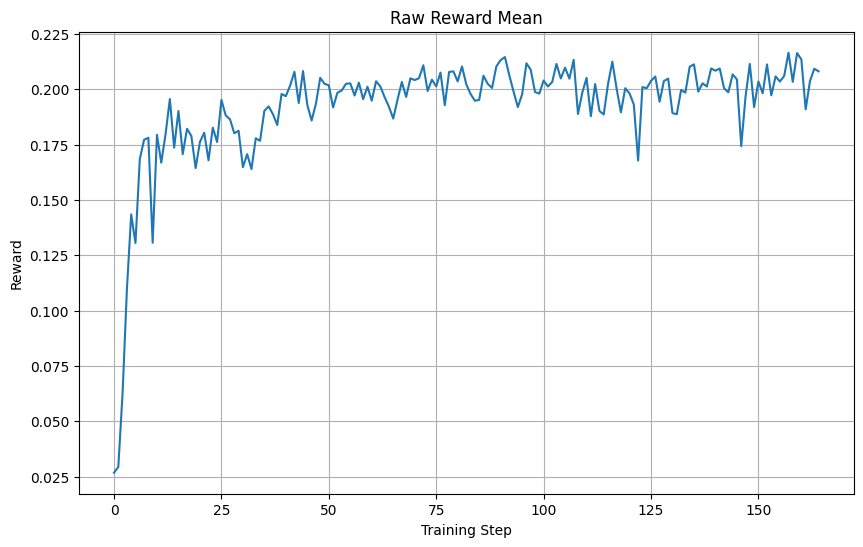

In [2]:
# Raw Reward
plt.figure(figsize=(10, 6))
plt.plot(df['step'], df['raw_reward_mean'])
plt.title('Raw Reward Mean')
plt.xlabel('Training Step')
plt.ylabel('Reward')
plt.grid(True)
plt.show()

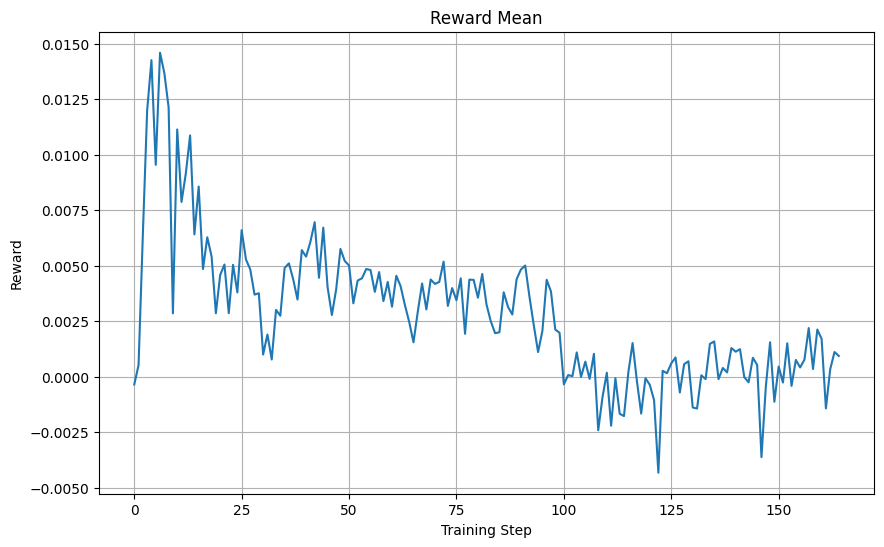

In [3]:
# Reward
plt.figure(figsize=(10, 6))
plt.plot(df['step'], df['reward_mean'])
plt.title('Reward Mean')
plt.xlabel('Training Step')
plt.ylabel('Reward')
plt.grid(True)
plt.show()

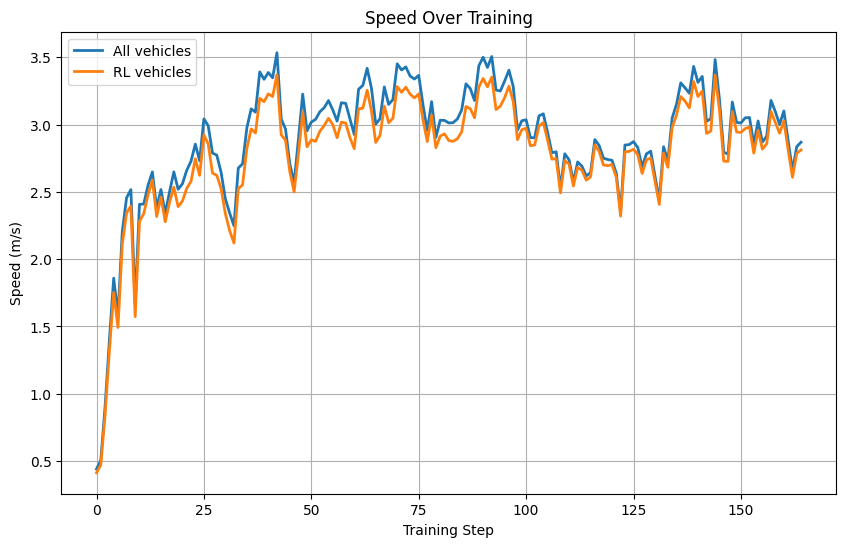

In [4]:
# Speed
plt.figure(figsize=(10, 6))
plt.plot(df['step'], df['speed'], label='All vehicles', linewidth=2)
plt.plot(df['step'], df['speed_rl'], label='RL vehicles', linewidth=2)
plt.title('Speed Over Training')
plt.xlabel('Training Step')
plt.ylabel('Speed (m/s)')
plt.legend()
plt.grid(True)
plt.show()

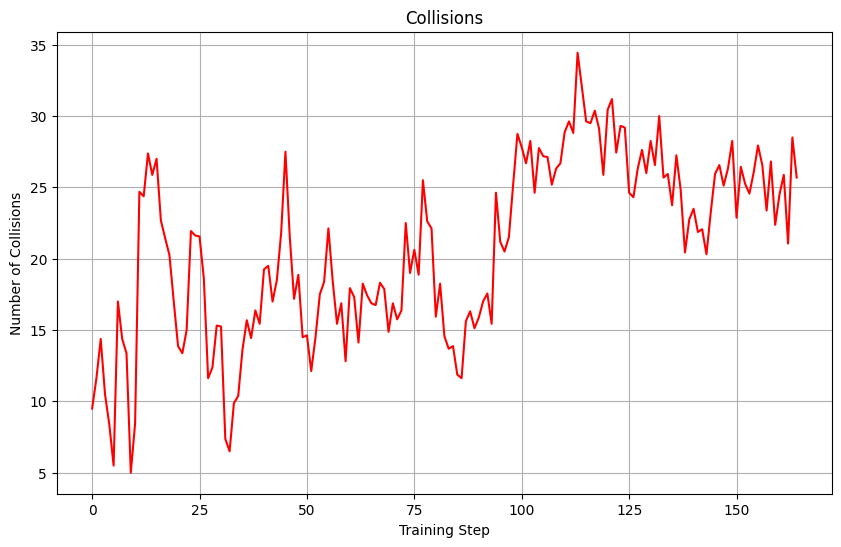

In [5]:
# Collisions
plt.figure(figsize=(10, 6))
plt.plot(df['step'], df['collisions'], color='red')
plt.title('Collisions')
plt.xlabel('Training Step')
plt.ylabel('Number of Collisions')
plt.grid(True)
plt.show()

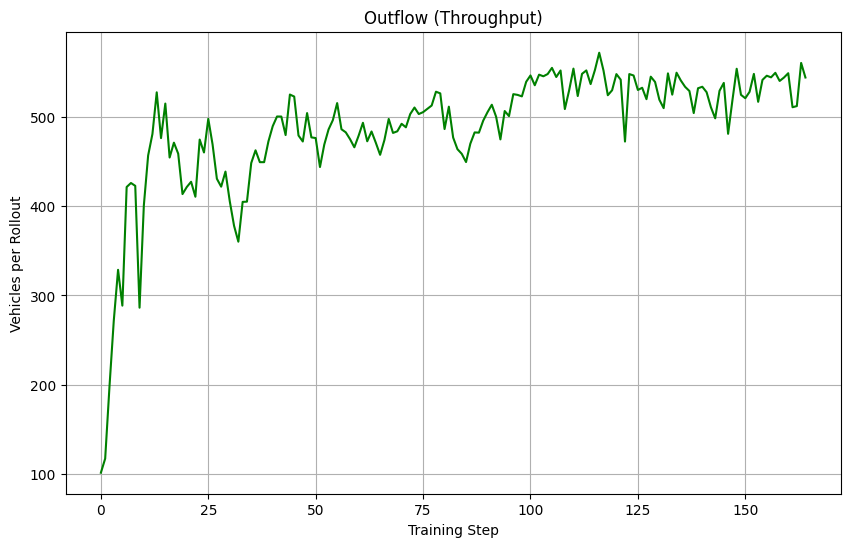

In [6]:
# Throughput
plt.figure(figsize=(10, 6))
plt.plot(df['step'], df['outflow'], color='green')
plt.title('Outflow (Throughput)')
plt.xlabel('Training Step')
plt.ylabel('Vehicles per Rollout')
plt.grid(True)
plt.show()

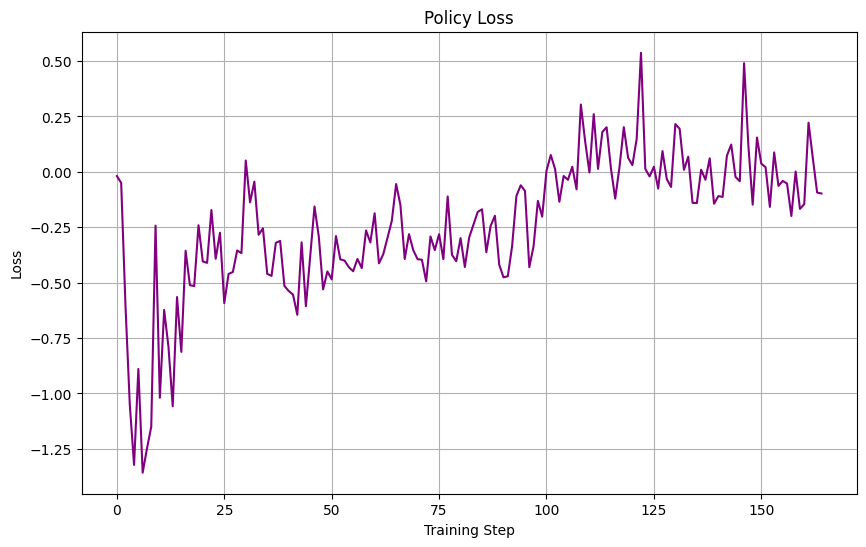

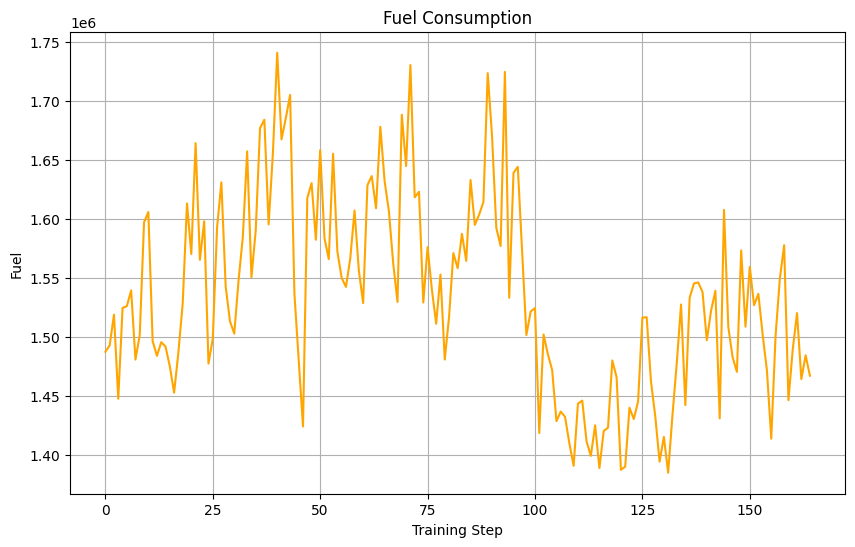

In [8]:
# Fuel Consumption
plt.figure(figsize=(10, 6))
plt.plot(df['step'], df['fuel'], color='orange')
plt.title('Fuel Consumption')
plt.xlabel('Training Step')
plt.ylabel('Fuel')
plt.grid(True)
plt.show()

# Data from training with ADAM opt, alg = PO

### Key change
- Change optimization function from RMSProp to Adam with new parameters

In [9]:
# Load results
df = pd.read_csv('results/fourway_1x1_penetration0.5_turn_adam/train_results.csv')

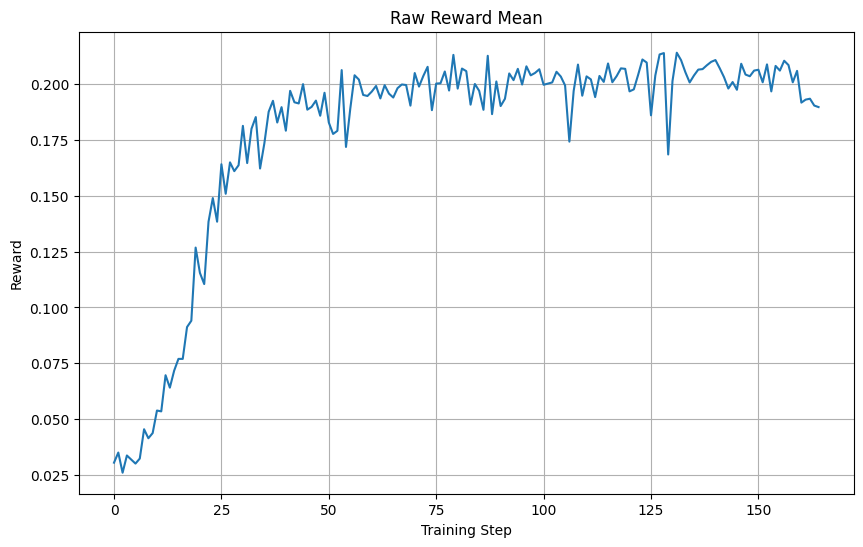

In [10]:
# Raw Reward
plt.figure(figsize=(10, 6))
plt.plot(df['step'], df['raw_reward_mean'])
plt.title('Raw Reward Mean')
plt.xlabel('Training Step')
plt.ylabel('Reward')
plt.grid(True)
plt.show()

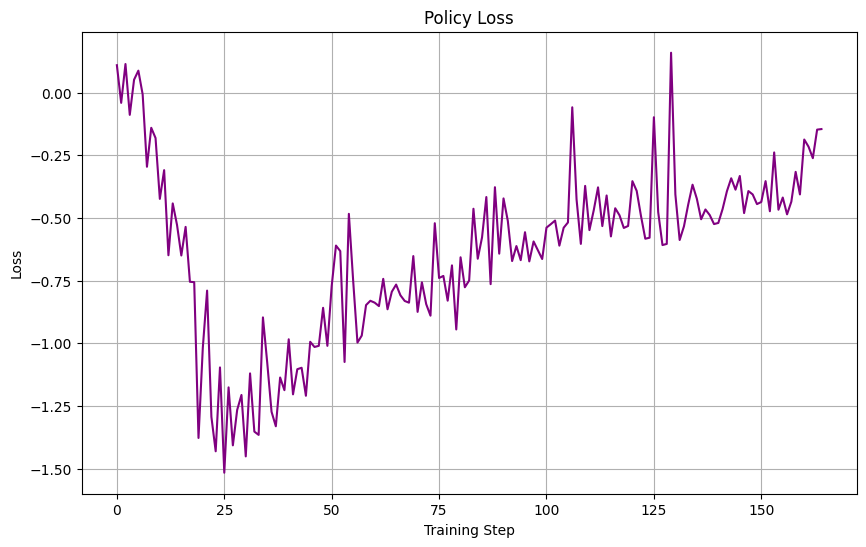

In [11]:
# Policy Loss
plt.figure(figsize=(10, 6))
plt.plot(df['step'], df['policy_loss'], color='purple')
plt.title('Policy Loss')
plt.xlabel('Training Step')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

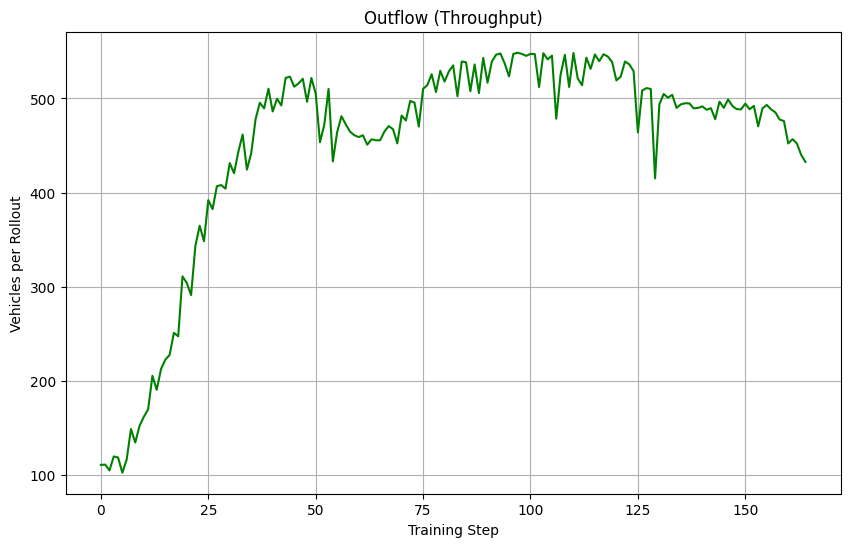

In [12]:
# Throughput
plt.figure(figsize=(10, 6))
plt.plot(df['step'], df['outflow'], color='green')
plt.title('Outflow (Throughput)')
plt.xlabel('Training Step')
plt.ylabel('Vehicles per Rollout')
plt.grid(True)
plt.show()

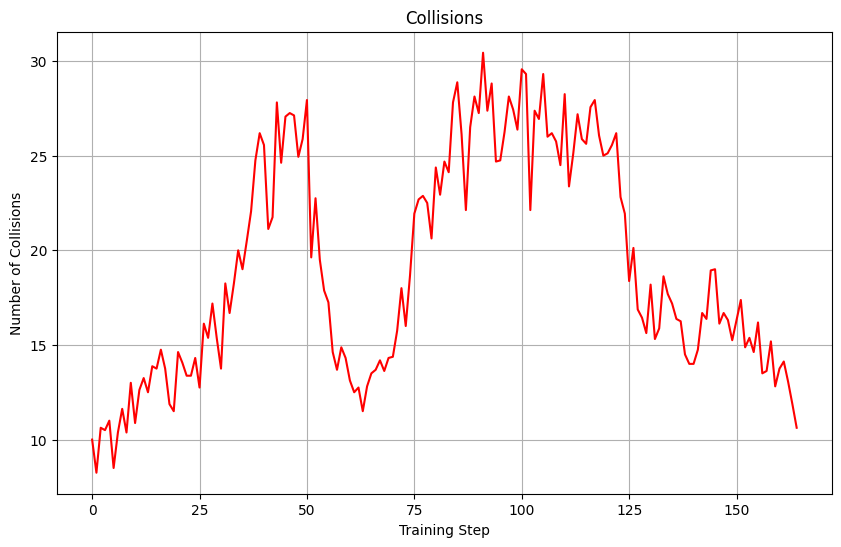

In [13]:
# Collisions
plt.figure(figsize=(10, 6))
plt.plot(df['step'], df['collisions'], color='red')
plt.title('Collisions')
plt.xlabel('Training Step')
plt.ylabel('Number of Collisions')
plt.grid(True)
plt.show()

# Training with ADAM Opt, alg = PPO
### Key change
- Added value network for training value
- Enhance reward calculation in GridEnv to support individual rewards for RL vehicles and maintain global reward structure
- Refactor RunningStats to use Welford's algorithm for improved batch statistics; update device settings to 'cuda' for compatibility
- Update rollout prediction to use value estimation and enhance training initialization logging
- Fix reward calculation in NormEnv to use mean for return estimation


### Traning parameter:
- av_frac: 0.5 
- directions: 4way
- n_cols: 1
- n_rollouts_per_step: 16
- n_rows: 1
- n_workers: 1
- opt: Adam
- alg: PPO
- g_nds: 20
- chain_lr: True
- use_ray: False
- load_step: 100
- worker_kwargs:
  - flow_rate_h: 700
  - flow_rate_v: 700

In [14]:
# Load results
df = pd.read_csv('results/fourway_1x1_penetration0.5_turn_adam_ppo/train_results.csv')

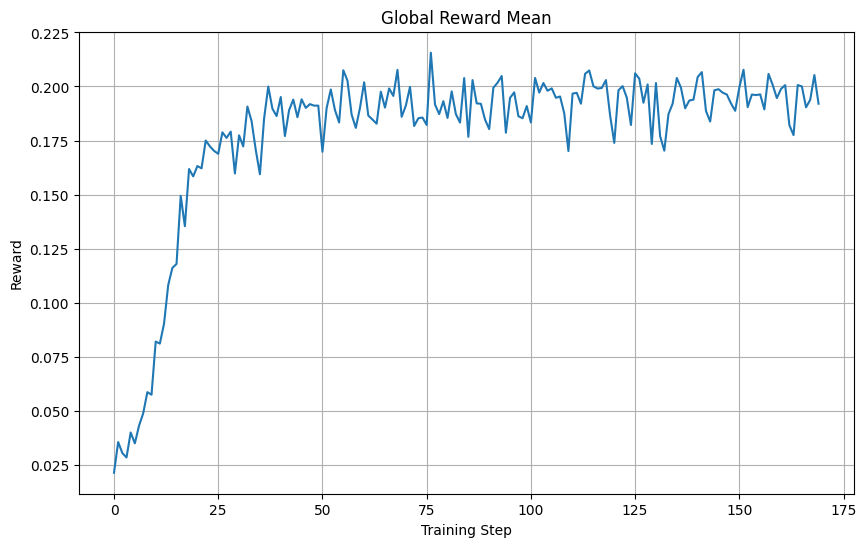

In [15]:
# Global Reward Mean
plt.figure(figsize=(10, 6))
plt.plot(df['step'], df['global_reward_mean'])
plt.title('Global Reward Mean')
plt.xlabel('Training Step')
plt.ylabel('Reward')
plt.grid(True)
plt.show()

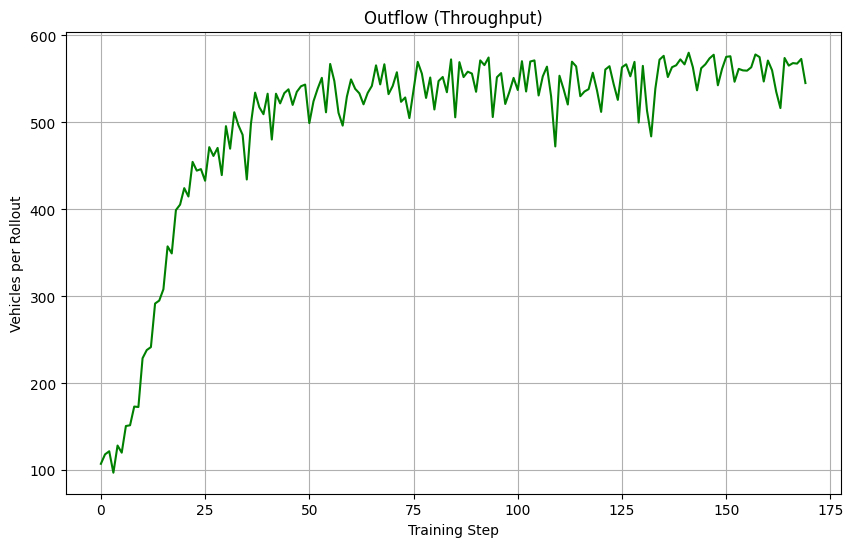

In [16]:
# Throughput
plt.figure(figsize=(10, 6))
plt.plot(df['step'], df['outflow'], color='green')
plt.title('Outflow (Throughput)')
plt.xlabel('Training Step')
plt.ylabel('Vehicles per Rollout')
plt.grid(True)
plt.show()

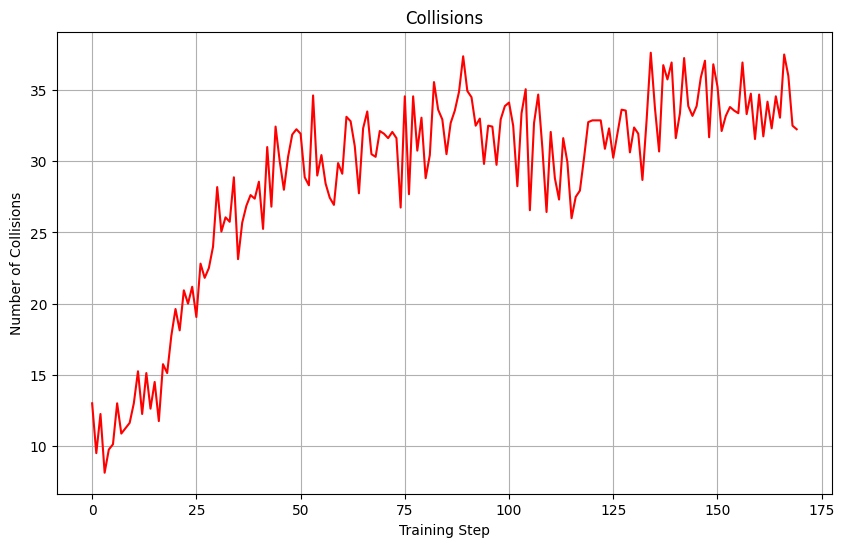

In [17]:
# Collisions
plt.figure(figsize=(10, 6))
plt.plot(df['step'], df['collisions'], color='red')
plt.title('Collisions')
plt.xlabel('Training Step')
plt.ylabel('Number of Collisions')
plt.grid(True)
plt.show()

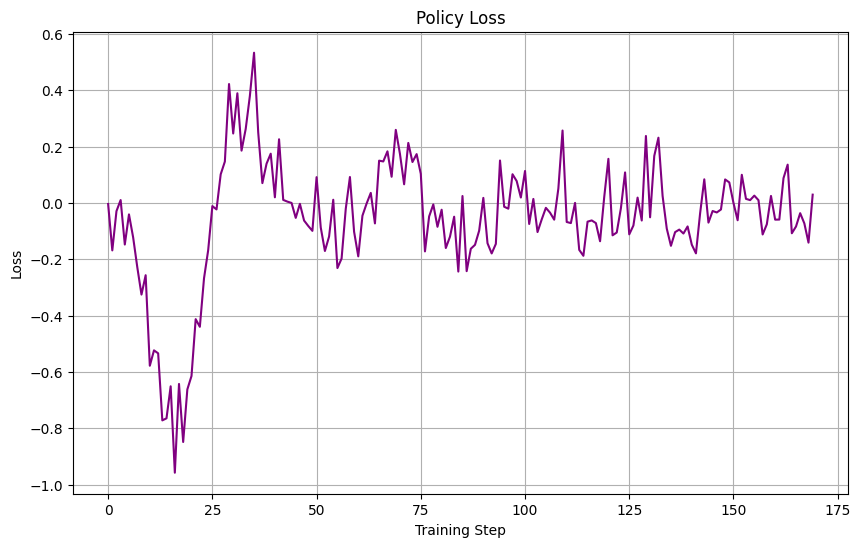

In [18]:
# Policy Loss
plt.figure(figsize=(10, 6))
plt.plot(df['step'], df['policy_loss'], color='purple')
plt.title('Policy Loss')
plt.xlabel('Training Step')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

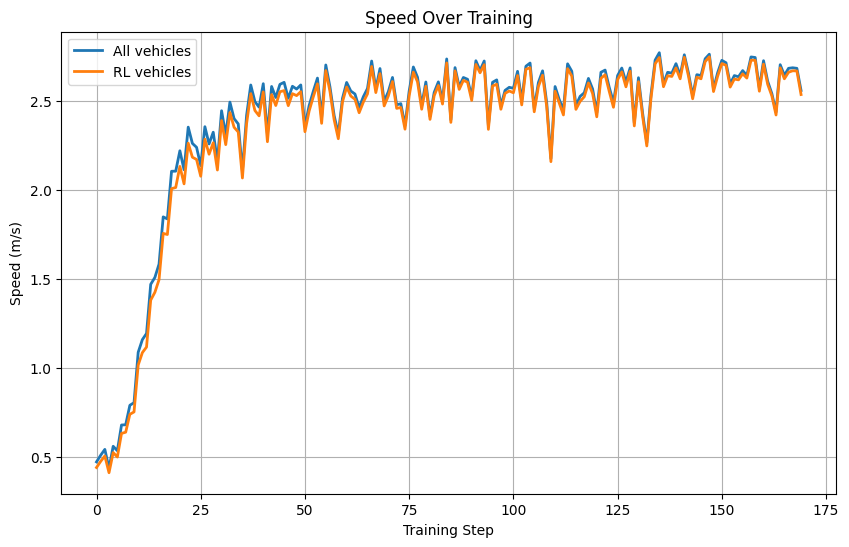

In [19]:
# Speed
plt.figure(figsize=(10, 6))
plt.plot(df['step'], df['speed'], label='All vehicles', linewidth=2)
plt.plot(df['step'], df['speed_rl'], label='RL vehicles', linewidth=2)
plt.title('Speed Over Training')
plt.xlabel('Training Step')
plt.ylabel('Speed (m/s)')
plt.legend()
plt.grid(True)
plt.show()

## Training with ADAM Opt, alg = PPO, tuning (26.11)
# Key change
- change FFN from tanh to leaky ReLu activation function
- disable adv_norm because it's causing small policy loss
- set vcoef = 0.5 (less training for value network)
- increase collsion coef = 10 

# Traning parameter:
- av_frac: 0.5 # 50% autonomous vehicles
- directions: 4way 
- n_cols: 1 # 1x1 grid
- n_rows: 1
- n_rollouts_per_step: 16 # Number of rollouts per training step
- n_workers: 1
- opt: Adam # Optimizer
- alg: PPO # Proximal Policy Optimization
- n_gds: 20 # 
- load_step: 0 # Start training from scratch 
- chain_lr: True # Enable left and right turn 
- use_ray: False # Disable Ray 
- worker_kwargs:
  - flow_rate_h: 700
  - flow_rate_v: 700
- pclip: 0.2 # Standard PPO clipping
- adv_norm: False # Disable advantage normalization
- entcoef: 0.01 # Maintain some exploration
- lr: 0.001 # Increase learning rate
- vcoef: 0.5 # Value function coefficient
- collision_coef: 10.0 # Collision penalty coefficient

In [20]:
# Load results
df = pd.read_csv('results/fourway_1x1_penetration0.5_turn_adam_ppo_26.11/train_results.csv')

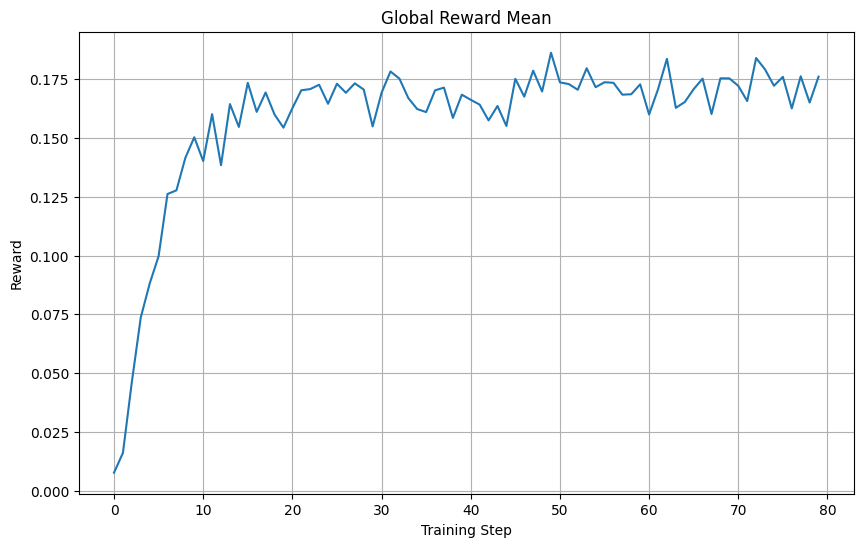

In [21]:
# Global Reward Mean
plt.figure(figsize=(10, 6))
plt.plot(df['step'], df['global_reward_mean'])
plt.title('Global Reward Mean')
plt.xlabel('Training Step')
plt.ylabel('Reward')
plt.grid(True)
plt.show()

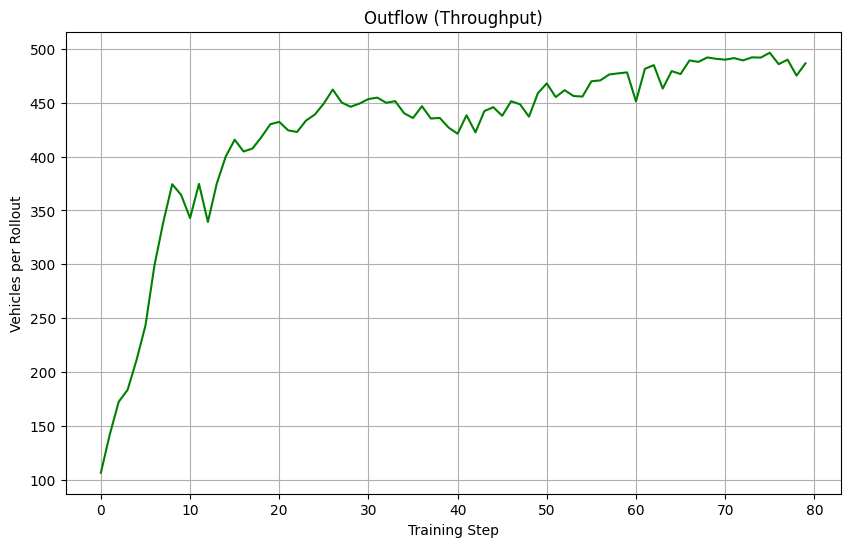

In [22]:
# Throughput
plt.figure(figsize=(10, 6))
plt.plot(df['step'], df['outflow'], color='green')
plt.title('Outflow (Throughput)')
plt.xlabel('Training Step')
plt.ylabel('Vehicles per Rollout')
plt.grid(True)
plt.show()

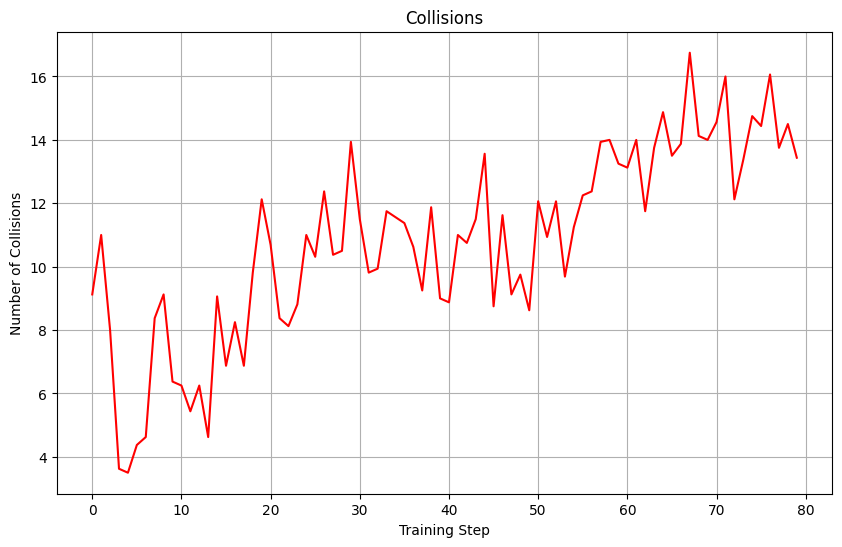

In [23]:
# Collisions
plt.figure(figsize=(10, 6))
plt.plot(df['step'], df['collisions'], color='red')
plt.title('Collisions')
plt.xlabel('Training Step')
plt.ylabel('Number of Collisions')
plt.grid(True)
plt.show()

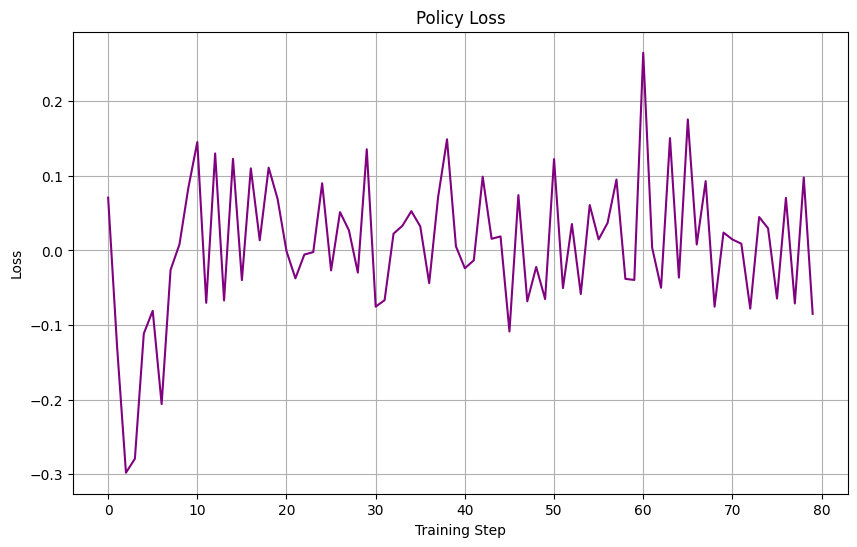

In [24]:
# Policy Loss
plt.figure(figsize=(10, 6))
plt.plot(df['step'], df['policy_loss'], color='purple')
plt.title('Policy Loss')
plt.xlabel('Training Step')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

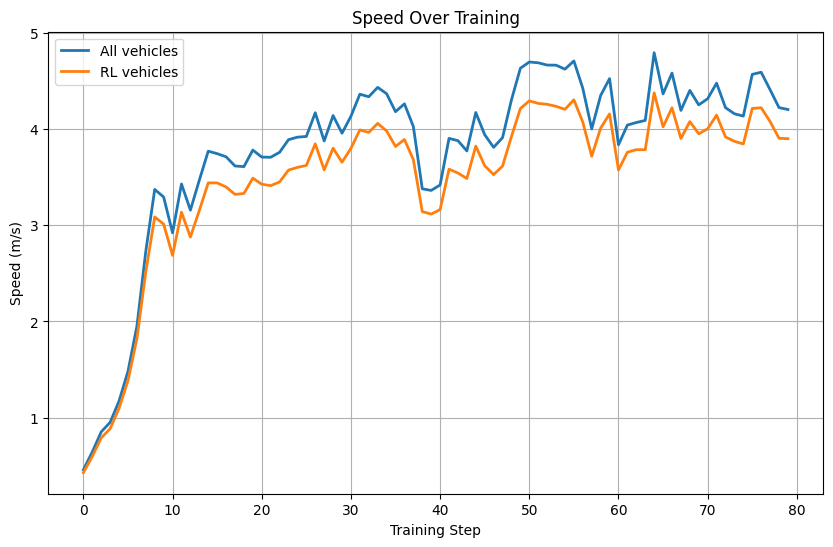

In [25]:
# Speed
plt.figure(figsize=(10, 6))
plt.plot(df['step'], df['speed'], label='All vehicles', linewidth=2)
plt.plot(df['step'], df['speed_rl'], label='RL vehicles', linewidth=2)
plt.title('Speed Over Training')
plt.xlabel('Training Step')
plt.ylabel('Speed (m/s)')
plt.legend()
plt.grid(True)
plt.show()

## Training with ADAM Opt, alg = PPO, tuning (27.11)
# Key change
- Number of rollouts per training step 16 -> 24
- Change network architecture from (64, 64) to (128, 128)
- add Poisson distribution flow

# Traning parameter:
- av_frac: 0.5 # 50% autonomous vehicles
- directions: 4way 
- n_cols: 1 # 1x1 grid
- n_rows: 1
- n_rollouts_per_step: 24 # Number of rollouts per training step
- n_workers: 1
- opt: Adam # Optimizer
- alg: PPO # Proximal Policy Optimization
- n_gds: 20 # 
- load_step: 0 # Start training from scratch 
- chain_lr: True # Enable left and right turn 
- use_ray: False # Disable Ray 
- worker_kwargs:
  - flow_rate_h: 700
  - flow_rate_v: 700
- pclip: 0.2 # Standard PPO clipping
- adv_norm: False # Disable advantage normalization
- entcoef: 0.01 # Maintain some exploration
- lr: 0.001 # Increase learning rate
- vcoef: 0.5 # Value function coefficient
- collision_coef: 10.0 # Collision penalty coefficient
- layers: 
  - 128
  - leaky_relu
  - 128
  - leaky_relu
- use_poisson: True # Enable Poisson flow

In [28]:
# Load results
df = pd.read_csv('results/fourway_1x1_penetration0.5_turn_adam_ppo_27.11/train_results.csv')

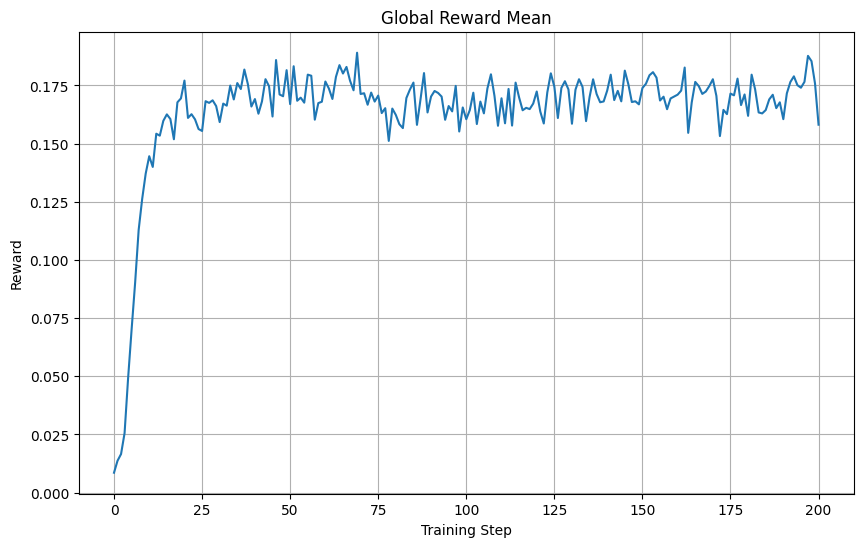

In [25]:
# Global Reward Mean
plt.figure(figsize=(10, 6))
plt.plot(df['step'], df['global_reward_mean'])
plt.title('Global Reward Mean')
plt.xlabel('Training Step')
plt.ylabel('Reward')
plt.grid(True)
plt.show()

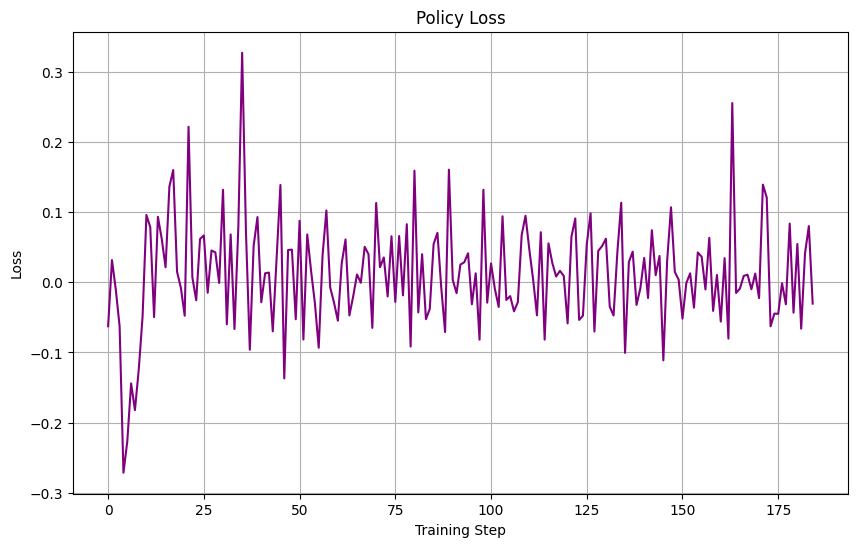

In [20]:
# Policy Loss
plt.figure(figsize=(10, 6))
plt.plot(df['step'], df['policy_loss'], color='purple')
plt.title('Policy Loss')
plt.xlabel('Training Step')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

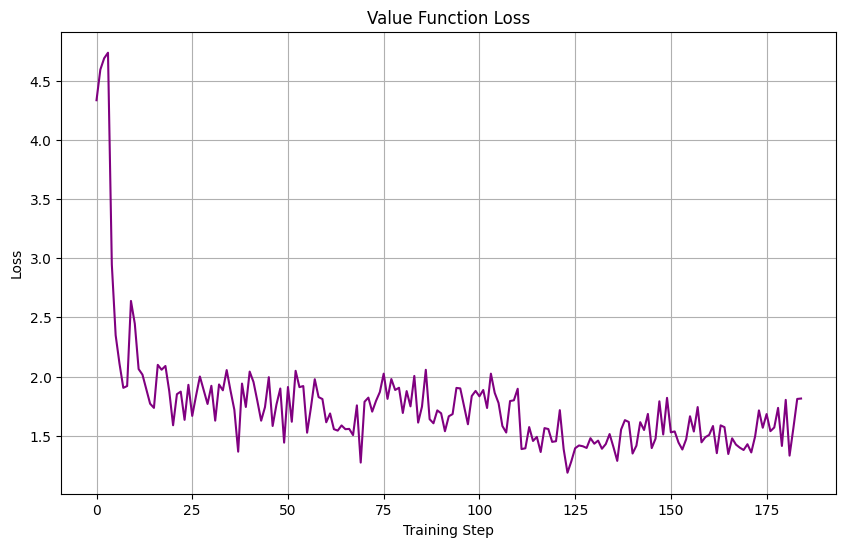

In [21]:
# Value Function Loss
plt.figure(figsize=(10, 6))
plt.plot(df['step'], df['value_loss'], color='purple')
plt.title('Value Function Loss')
plt.xlabel('Training Step')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

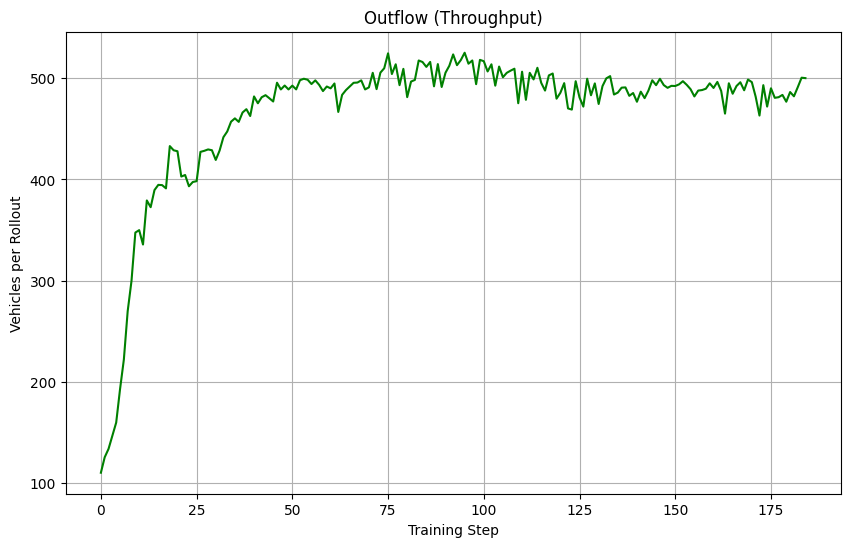

In [22]:
# Throughput
plt.figure(figsize=(10, 6))
plt.plot(df['step'], df['outflow'], color='green')
plt.title('Outflow (Throughput)')
plt.xlabel('Training Step')
plt.ylabel('Vehicles per Rollout')
plt.grid(True)
plt.show()

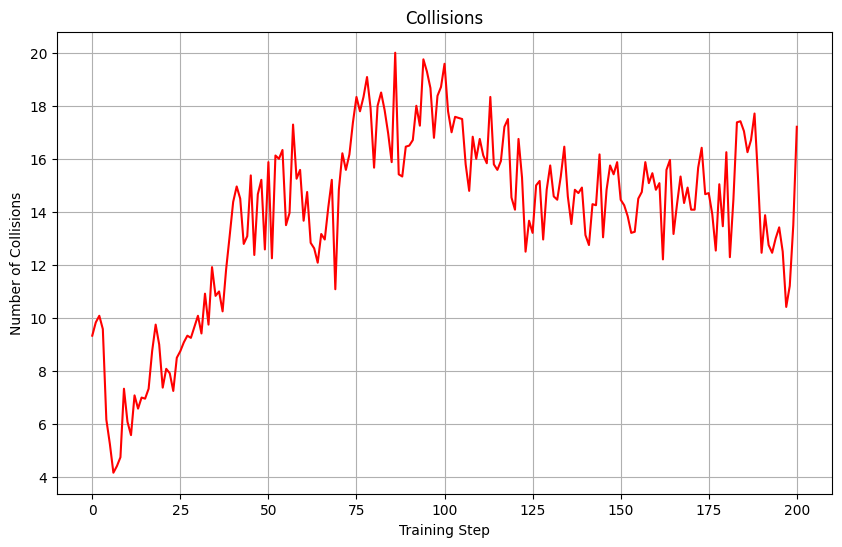

In [27]:
# Collisions
plt.figure(figsize=(10, 6))
plt.plot(df['step'], df['collisions'], color='red')
plt.title('Collisions')
plt.xlabel('Training Step')
plt.ylabel('Number of Collisions')
plt.grid(True)
plt.show()

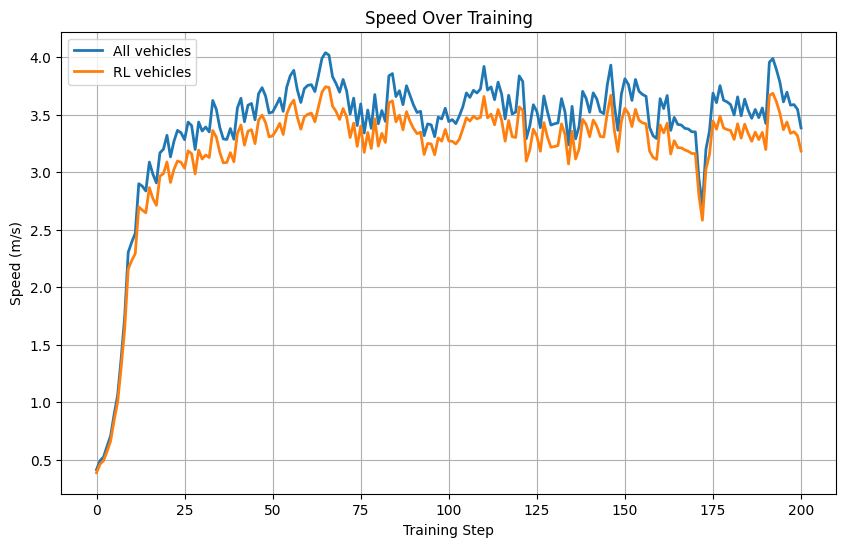

In [26]:
# Speed
plt.figure(figsize=(10, 6))
plt.plot(df['step'], df['speed'], label='All vehicles', linewidth=2)
plt.plot(df['step'], df['speed_rl'], label='RL vehicles', linewidth=2)
plt.title('Speed Over Training')
plt.xlabel('Training Step')
plt.ylabel('Speed (m/s)')
plt.legend()
plt.grid(True)
plt.show()

## Training with ADAM Opt, alg = PPO, tuning (01.12)
# Key change
- Change reward from only count when vehicle succesfully exit the junction/ collision.
- Remove global reward from individual reward

# Traning parameter:
- av_frac: 0.5 # 50% autonomous vehicles
- directions: 4way 
- n_cols: 1 # 1x1 grid
- n_rows: 1
- n_rollouts_per_step: 24 # Number of rollouts per training step
- n_workers: 1
- opt: Adam # Optimizer
- alg: PPO # Proximal Policy Optimization
- n_gds: 20 # 
- load_step: 0 # Start training from scratch 
- chain_lr: True # Enable left and right turn 
- use_ray: False # Disable Ray 
- worker_kwargs:
  - flow_rate_h: 700
  - flow_rate_v: 700
- pclip: 0.2 # Standard PPO clipping
- adv_norm: False # Disable advantage normalization
- entcoef: 0.01 # Maintain some exploration
- lr: 0.001 # Increase learning rate
- vcoef: 0.5 # Value function coefficient
- collision_coef: 10.0 # Collision penalty coefficient
- layers: 
  - 128
  - leaky_relu
  - 128
  - leaky_relu
- use_poisson: True # Enable Poisson flow

In [10]:
# Load results
df = pd.read_csv('results/fourway_1x1_penetration0.5_turn_adam_ppo_01.12/train_results.csv')

KeyError: 'global_reward_mean'

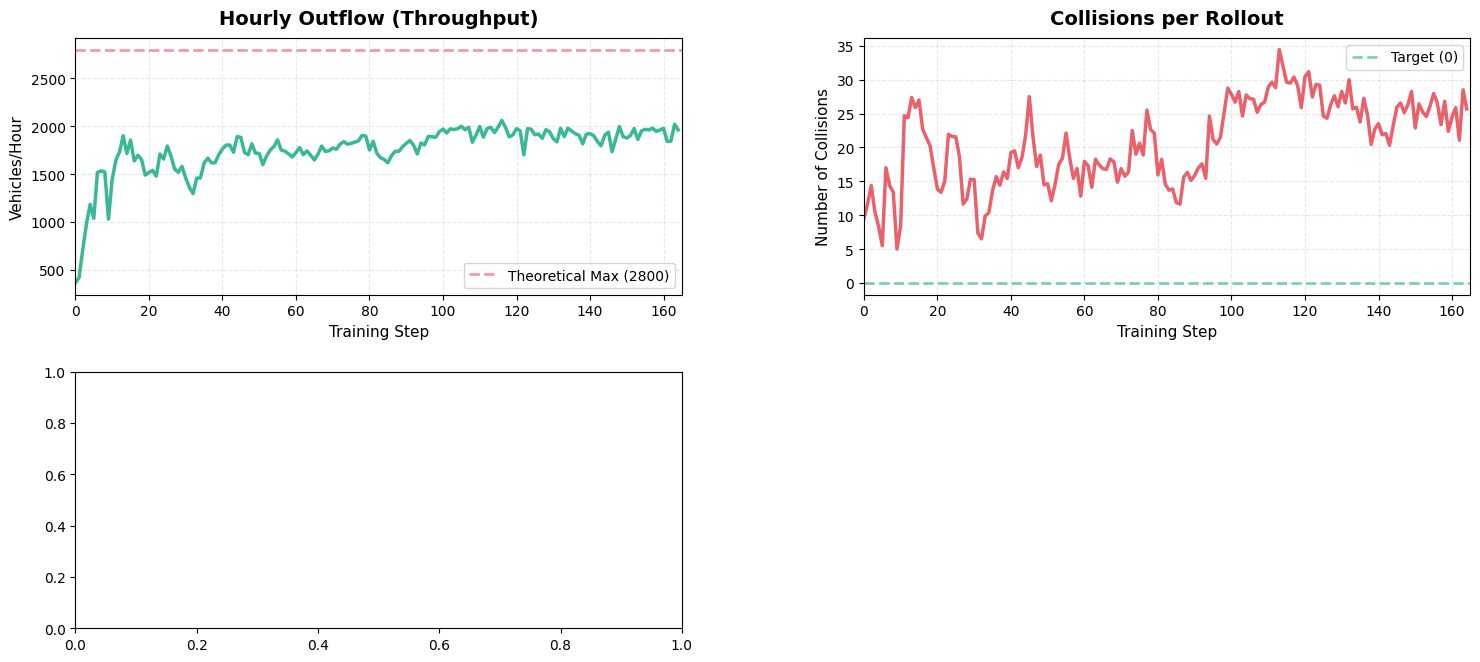

In [2]:
# Calculate hourly outflow
def calculate_hourly_outflow(df, horizon=2000, sim_step=0.5):
    """Convert outflow per rollout to vehicles per hour"""
    simulation_time_seconds = horizon * sim_step
    simulation_time_hours = simulation_time_seconds / 3600
    df['outflow_hourly'] = df['outflow'] / simulation_time_hours
    return df

df = calculate_hourly_outflow(df.copy())

# Create comprehensive subplot figure
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# Define color scheme
colors = {
    'primary': '#2E86AB',
    'danger': '#E63946',
    'success': '#06A77D',
    'warning': '#F77F00',
    'info': '#9B59B6',
    'secondary': '#6C757D'
}

# --- Subplot 1: Hourly Outflow ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(df['step'], df['outflow_hourly'], linewidth=2.5, color=colors['success'], alpha=0.8)
ax1.axhline(y=2800, color=colors['danger'], linestyle='--', linewidth=2, alpha=0.5, label='Theoretical Max (2800)')
# ax1.fill_between(df['step'], 0, df['outflow_hourly'], alpha=0.2, color=colors['success'])
ax1.set_title('Hourly Outflow (Throughput)', fontsize=14, fontweight='bold', pad=10)
ax1.set_xlabel('Training Step', fontsize=11)
ax1.set_ylabel('Vehicles/Hour', fontsize=11)
ax1.legend(loc='lower right', fontsize=10)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_xlim(df['step'].min(), df['step'].max())

# Add annotation for final value
final_outflow = df['outflow_hourly'].iloc[-1]
ax1.annotate(f'Final: {final_outflow:.1f}', 
            xy=(df['step'].iloc[-1], final_outflow),
            xytext=(10, 10), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            fontsize=10, fontweight='bold')

# --- Subplot 2: Collisions ---
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(df['step'], df['collisions'], linewidth=2.5, color=colors['danger'], alpha=0.8)
# ax2.fill_between(df['step'], 0, df['collisions'], alpha=0.2, color=colors['danger'])
ax2.axhline(y=0, color=colors['success'], linestyle='--', linewidth=2, alpha=0.5, label='Target (0)')
ax2.set_title('Collisions per Rollout', fontsize=14, fontweight='bold', pad=10)
ax2.set_xlabel('Training Step', fontsize=11)
ax2.set_ylabel('Number of Collisions', fontsize=11)
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_xlim(df['step'].min(), df['step'].max())

# Add annotation for final value
final_collisions = df['collisions'].iloc[-1]
ax2.annotate(f'Final: {final_collisions:.2f}', 
            xy=(df['step'].iloc[-1], final_collisions),
            xytext=(10, -10), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            fontsize=10, fontweight='bold')

# --- Subplot 3: Global Reward Mean ---
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(df['step'], df['global_reward_mean'], linewidth=2.5, color=colors['primary'], alpha=0.8)
# ax3.fill_between(df['step'], df['global_reward_mean'].min(), df['global_reward_mean'], 
#                  alpha=0.2, color=colors['primary'])
ax3.set_title('Global Reward Mean', fontsize=14, fontweight='bold', pad=10)
ax3.set_xlabel('Training Step', fontsize=11)
ax3.set_ylabel('Reward', fontsize=11)
ax3.grid(True, alpha=0.3, linestyle='--')
ax3.set_xlim(df['step'].min(), df['step'].max())

# Add smoothed trend line
from scipy.ndimage import uniform_filter1d
window_size = max(5, len(df) // 20)
smoothed = uniform_filter1d(df['global_reward_mean'], size=window_size)
ax3.plot(df['step'], smoothed, linewidth=2, color='darkblue', linestyle='--', 
         alpha=0.7, label='Smoothed Trend')
ax3.legend(loc='lower right', fontsize=10)

# --- Subplot 4: Policy Loss ---
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(df['step'], df['policy_loss'], linewidth=2.5, color=colors['info'], alpha=0.8)
# ax4.fill_between(df['step'], 0, df['policy_loss'], alpha=0.2, color=colors['info'])
ax4.set_title('Policy Loss', fontsize=14, fontweight='bold', pad=10)
ax4.set_xlabel('Training Step', fontsize=11)
ax4.set_ylabel('Loss', fontsize=11)
ax4.grid(True, alpha=0.3, linestyle='--')
ax4.set_xlim(df['step'].min(), df['step'].max())

# Add smoothed trend line
smoothed_policy = uniform_filter1d(df['policy_loss'], size=window_size)
ax4.plot(df['step'], smoothed_policy, linewidth=2, color='purple', linestyle='--', 
         alpha=0.7, label='Smoothed Trend')
ax4.legend(loc='upper right', fontsize=10)

# --- Subplot 5: Value Function Loss ---
ax5 = fig.add_subplot(gs[2, 0])
ax5.plot(df['step'], df['value_loss'], linewidth=2.5, color=colors['warning'], alpha=0.8)
# ax5.fill_between(df['step'], 0, df['value_loss'], alpha=0.2, color=colors['warning'])
ax5.set_title('Value Function Loss', fontsize=14, fontweight='bold', pad=10)
ax5.set_xlabel('Training Step', fontsize=11)
ax5.set_ylabel('Loss', fontsize=11)
ax5.grid(True, alpha=0.3, linestyle='--')
ax5.set_xlim(df['step'].min(), df['step'].max())

# Add smoothed trend line
smoothed_value = uniform_filter1d(df['value_loss'], size=window_size)
ax5.plot(df['step'], smoothed_value, linewidth=2, color='darkorange', linestyle='--', 
         alpha=0.7, label='Smoothed Trend')
ax5.legend(loc='upper right', fontsize=10)

# --- Subplot 6: Speed Over Training ---
ax6 = fig.add_subplot(gs[2, 1])
ax6.plot(df['step'], df['speed'], label='All Vehicles', linewidth=2.5, 
         color=colors['secondary'], alpha=0.8)
ax6.plot(df['step'], df['speed_rl'], label='RL Vehicles', linewidth=2.5, 
         color=colors['primary'], alpha=0.8)
# ax6.fill_between(df['step'], df['speed'], alpha=0.1, color=colors['secondary'])
# ax6.fill_between(df['step'], df['speed_rl'], alpha=0.1, color=colors['primary'])
ax6.set_title('Speed Over Training', fontsize=14, fontweight='bold', pad=10)
ax6.set_xlabel('Training Step', fontsize=11)
ax6.set_ylabel('Speed (m/s)', fontsize=11)
ax6.legend(loc='lower right', fontsize=10)
ax6.grid(True, alpha=0.3, linestyle='--')
ax6.set_xlim(df['step'].min(), df['step'].max())

# Add annotation for final speeds
final_speed_all = df['speed'].iloc[-1]
final_speed_rl = df['speed_rl'].iloc[-1]
ax6.annotate(f'All: {final_speed_all:.2f} m/s\nRL: {final_speed_rl:.2f} m/s', 
            xy=(df['step'].iloc[-1], final_speed_rl),
            xytext=(-80, 20), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            fontsize=9, fontweight='bold')

# Add main title
fig.suptitle('Training Progress - PPO (01.12) - Individual Reward Model\n' + 
             'Architecture: 128x128 LeakyReLU | Poisson Flow | Collision Coef: 10.0',
             fontsize=16, fontweight='bold', y=0.995)

plt.tight_layout()
plt.show()

# --- Print Summary Statistics ---
print("\n" + "="*80)
print("TRAINING SUMMARY - PPO (01.12)")
print("="*80)
print(f"Total Training Steps: {df['step'].max()}")
print(f"\nFinal Metrics (Last 10 Steps Average):")
print("-" * 80)

last_10 = df.tail(10)

metrics = {
    'Hourly Outflow': (last_10['outflow_hourly'].mean(), 'veh/hr'),
    'Collisions': (last_10['collisions'].mean(), 'per rollout'),
    'Global Reward': (last_10['global_reward_mean'].mean(), ''),
    'Policy Loss': (last_10['policy_loss'].mean(), ''),
    'Value Loss': (last_10['value_loss'].mean(), ''),
    'Speed (All)': (last_10['speed'].mean(), 'm/s'),
    'Speed (RL)': (last_10['speed_rl'].mean(), 'm/s'),
}

for metric, (value, unit) in metrics.items():
    print(f"{metric:20s}: {value:8.3f} {unit}")

print("\nPerformance Indicators:")
print("-" * 80)
efficiency = (last_10['outflow_hourly'].mean() / 1400) * 100
print(f"Throughput Efficiency: {efficiency:.1f}% of theoretical max")
print(f"Safety Score: {'EXCELLENT' if last_10['collisions'].mean() < 0.5 else 'NEEDS IMPROVEMENT'} ({last_10['collisions'].mean():.2f} collisions)")
print(f"Learning Stability: {'STABLE' if last_10['policy_loss'].std() < 0.01 else 'UNSTABLE'} (policy loss std: {last_10['policy_loss'].std():.4f})")
print("="*80)

## Training with ADAM Opt, alg = PPO, tuning (04.12)
# Key change
- Add turn features to the observation space
- Total of 33 features

# Traning parameter:
- av_frac: 0.5 # 50% autonomous vehicles
- directions: 4way 
- n_cols: 1 # 1x1 grid
- n_rows: 1
- n_rollouts_per_step: 24 # Number of rollouts per training step
- n_workers: 1
- opt: Adam # Optimizer
- alg: PPO # Proximal Policy Optimization
- n_gds: 20 # 
- load_step: 0 # Start training from scratch 
- chain_lr: True # Enable left and right turn 
- use_ray: False # Disable Ray 
- worker_kwargs:
  - flow_rate_h: 700
  - flow_rate_v: 700
- pclip: 0.2 # Standard PPO clipping
- adv_norm: False # Disable advantage normalization
- entcoef: 0.01 # Maintain some exploration
- lr: 0.001 # Increase learning rate
- vcoef: 0.5 # Value function coefficient
- collision_coef: 10.0 # Collision penalty coefficient
- layers: 
  - 128
  - leaky_relu
  - 128
  - leaky_relu
- use_poisson: True # Enable Poisson flow

/tmp/ipykernel_1052/2272119033.py:148: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


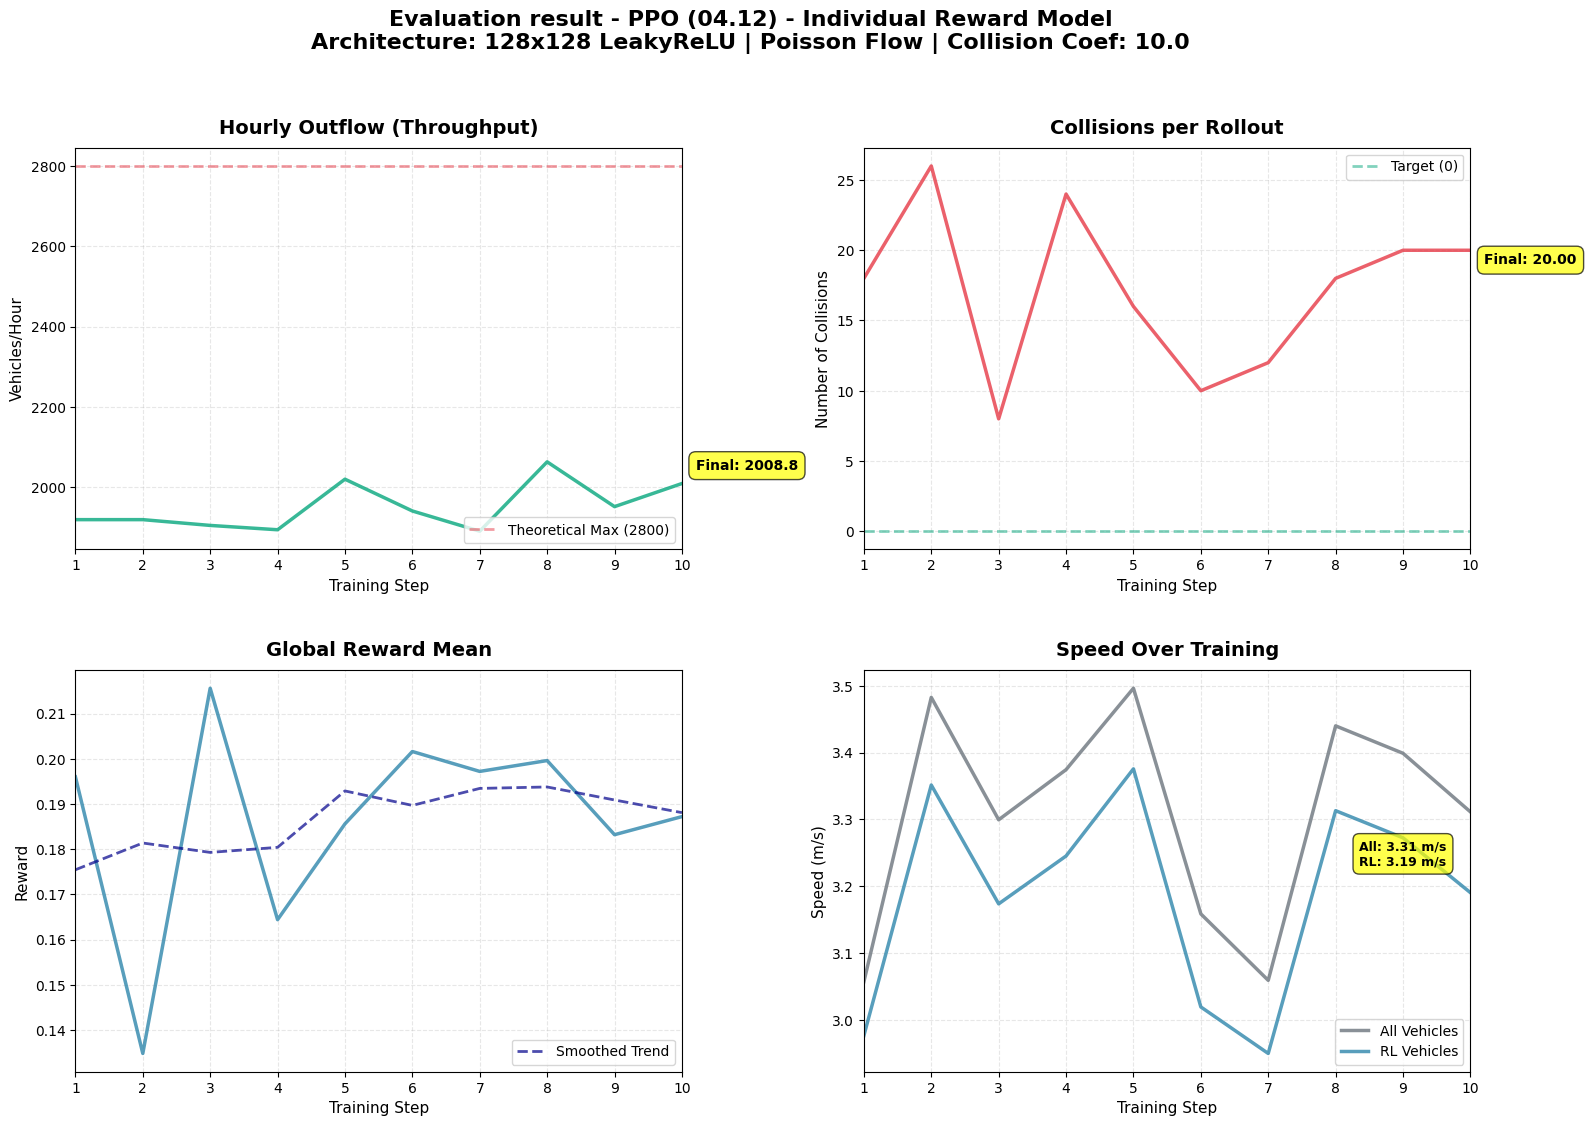


TRAINING SUMMARY - PPO (01.12)
Total Training Steps: 10

Final Metrics (Last 10 Steps Average):
--------------------------------------------------------------------------------
Hourly Outflow      : 1950.840 veh/hr
Collisions          :   17.200 per rollout
Global Reward       :    0.187 
Speed (All)         :    3.308 m/s
Speed (RL)          :    3.187 m/s

Performance Indicators:
--------------------------------------------------------------------------------
Throughput Efficiency: 139.3% of theoretical max
Safety Score: NEEDS IMPROVEMENT (17.20 collisions)


In [17]:
# Load results
df = pd.read_csv('results/fourway_1x1_penetration0.5_turn_adam_ppo_04.12/eval_results/e165_1x1_skip500_flow700x700.csv')

# Calculate hourly outflow
def calculate_hourly_outflow(df, horizon=2000, sim_step=0.5):
    """Convert outflow per rollout to vehicles per hour"""
    simulation_time_seconds = horizon * sim_step
    simulation_time_hours = simulation_time_seconds / 3600
    df['outflow_hourly'] = df['outflow'] / simulation_time_hours
    return df

df = calculate_hourly_outflow(df.copy())

# Create comprehensive subplot figure
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

# Define color scheme
colors = {
    'primary': '#2E86AB',
    'danger': '#E63946',
    'success': '#06A77D',
    'warning': '#F77F00',
    'info': '#9B59B6',
    'secondary': '#6C757D'
}

# --- Subplot 1: Hourly Outflow ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(df['step'], df['outflow_hourly'], linewidth=2.5, color=colors['success'], alpha=0.8)
ax1.axhline(y=2800, color=colors['danger'], linestyle='--', linewidth=2, alpha=0.5, label='Theoretical Max (2800)')
# ax1.fill_between(df['step'], 0, df['outflow_hourly'], alpha=0.2, color=colors['success'])
ax1.set_title('Hourly Outflow (Throughput)', fontsize=14, fontweight='bold', pad=10)
ax1.set_xlabel('Training Step', fontsize=11)
ax1.set_ylabel('Vehicles/Hour', fontsize=11)
ax1.legend(loc='lower right', fontsize=10)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_xlim(df['step'].min(), df['step'].max())

# Add annotation for final value
final_outflow = df['outflow_hourly'].iloc[-1]
ax1.annotate(f'Final: {final_outflow:.1f}', 
            xy=(df['step'].iloc[-1], final_outflow),
            xytext=(10, 10), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            fontsize=10, fontweight='bold')

# --- Subplot 2: Collisions ---
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(df['step'], df['collisions'], linewidth=2.5, color=colors['danger'], alpha=0.8)
# ax2.fill_between(df['step'], 0, df['collisions'], alpha=0.2, color=colors['danger'])
ax2.axhline(y=0, color=colors['success'], linestyle='--', linewidth=2, alpha=0.5, label='Target (0)')
ax2.set_title('Collisions per Rollout', fontsize=14, fontweight='bold', pad=10)
ax2.set_xlabel('Training Step', fontsize=11)
ax2.set_ylabel('Number of Collisions', fontsize=11)
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_xlim(df['step'].min(), df['step'].max())

# Add annotation for final value
final_collisions = df['collisions'].iloc[-1]
ax2.annotate(f'Final: {final_collisions:.2f}', 
            xy=(df['step'].iloc[-1], final_collisions),
            xytext=(10, -10), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            fontsize=10, fontweight='bold')

# --- Subplot 3: Global Reward Mean ---
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(df['step'], df['global_reward_mean'], linewidth=2.5, color=colors['primary'], alpha=0.8)
# ax3.fill_between(df['step'], df['global_reward_mean'].min(), df['global_reward_mean'], 
#                  alpha=0.2, color=colors['primary'])
ax3.set_title('Global Reward Mean', fontsize=14, fontweight='bold', pad=10)
ax3.set_xlabel('Training Step', fontsize=11)
ax3.set_ylabel('Reward', fontsize=11)
ax3.grid(True, alpha=0.3, linestyle='--')
ax3.set_xlim(df['step'].min(), df['step'].max())

# Add smoothed trend line
from scipy.ndimage import uniform_filter1d
window_size = max(5, len(df) // 20)
smoothed = uniform_filter1d(df['global_reward_mean'], size=window_size)
ax3.plot(df['step'], smoothed, linewidth=2, color='darkblue', linestyle='--', 
         alpha=0.7, label='Smoothed Trend')
ax3.legend(loc='lower right', fontsize=10)

# --- Subplot 4: Policy Loss ---
# ax4 = fig.add_subplot(gs[1, 1])
# ax4.plot(df['step'], df['policy_loss'], linewidth=2.5, color=colors['info'], alpha=0.8)
# # ax4.fill_between(df['step'], 0, df['policy_loss'], alpha=0.2, color=colors['info'])
# ax4.set_title('Policy Loss', fontsize=14, fontweight='bold', pad=10)
# ax4.set_xlabel('Training Step', fontsize=11)
# ax4.set_ylabel('Loss', fontsize=11)
# ax4.grid(True, alpha=0.3, linestyle='--')
# ax4.set_xlim(df['step'].min(), df['step'].max())

# Add smoothed trend line
# smoothed_policy = uniform_filter1d(df['policy_loss'], size=window_size)
# ax4.plot(df['step'], smoothed_policy, linewidth=2, color='purple', linestyle='--', 
#          alpha=0.7, label='Smoothed Trend')
# ax4.legend(loc='upper right', fontsize=10)

# --- Subplot 5: Value Function Loss ---
# ax5 = fig.add_subplot(gs[2, 0])
# ax5.plot(df['step'], df['value_loss'], linewidth=2.5, color=colors['warning'], alpha=0.8)
# # ax5.fill_between(df['step'], 0, df['value_loss'], alpha=0.2, color=colors['warning'])
# ax5.set_title('Value Function Loss', fontsize=14, fontweight='bold', pad=10)
# ax5.set_xlabel('Training Step', fontsize=11)
# ax5.set_ylabel('Loss', fontsize=11)
# ax5.grid(True, alpha=0.3, linestyle='--')
# ax5.set_xlim(df['step'].min(), df['step'].max())

# Add smoothed trend line
# smoothed_value = uniform_filter1d(df['value_loss'], size=window_size)
# ax5.plot(df['step'], smoothed_value, linewidth=2, color='darkorange', linestyle='--', 
#          alpha=0.7, label='Smoothed Trend')
# ax5.legend(loc='upper right', fontsize=10)

# --- Subplot 6: Speed Over Training ---
ax6 = fig.add_subplot(gs[1, 1])
ax6.plot(df['step'], df['speed'], label='All Vehicles', linewidth=2.5, 
         color=colors['secondary'], alpha=0.8)
ax6.plot(df['step'], df['speed_rl'], label='RL Vehicles', linewidth=2.5, 
         color=colors['primary'], alpha=0.8)
# ax6.fill_between(df['step'], df['speed'], alpha=0.1, color=colors['secondary'])
# ax6.fill_between(df['step'], df['speed_rl'], alpha=0.1, color=colors['primary'])
ax6.set_title('Speed Over Training', fontsize=14, fontweight='bold', pad=10)
ax6.set_xlabel('Training Step', fontsize=11)
ax6.set_ylabel('Speed (m/s)', fontsize=11)
ax6.legend(loc='lower right', fontsize=10)
ax6.grid(True, alpha=0.3, linestyle='--')
ax6.set_xlim(df['step'].min(), df['step'].max())

# Add annotation for final speeds
final_speed_all = df['speed'].iloc[-1]
final_speed_rl = df['speed_rl'].iloc[-1]
ax6.annotate(f'All: {final_speed_all:.2f} m/s\nRL: {final_speed_rl:.2f} m/s', 
            xy=(df['step'].iloc[-1], final_speed_rl),
            xytext=(-80, 20), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            fontsize=9, fontweight='bold')

# Add main title
fig.suptitle('Evaluation result - PPO (04.12) - Individual Reward Model\n' + 
             'Architecture: 128x128 LeakyReLU | Poisson Flow | Collision Coef: 10.0',
             fontsize=16, fontweight='bold', y=0.995)

plt.tight_layout()
plt.show()

# --- Print Summary Statistics ---
print("\n" + "="*80)
print("TRAINING SUMMARY - PPO (01.12)")
print("="*80)
print(f"Total Training Steps: {df['step'].max()}")
print(f"\nFinal Metrics (Last 10 Steps Average):")
print("-" * 80)

last_10 = df.tail(10)

metrics = {
    'Hourly Outflow': (last_10['outflow_hourly'].mean(), 'veh/hr'),
    'Collisions': (last_10['collisions'].mean(), 'per rollout'),
    'Global Reward': (last_10['global_reward_mean'].mean(), ''),
    # 'Policy Loss': (last_10['policy_loss'].mean(), ''),
    # 'Value Loss': (last_10['value_loss'].mean(), ''),
    'Speed (All)': (last_10['speed'].mean(), 'm/s'),
    'Speed (RL)': (last_10['speed_rl'].mean(), 'm/s'),
}

for metric, (value, unit) in metrics.items():
    print(f"{metric:20s}: {value:8.3f} {unit}")

print("\nPerformance Indicators:")
print("-" * 80)
efficiency = (last_10['outflow_hourly'].mean() / 1400) * 100
print(f"Throughput Efficiency: {efficiency:.1f}% of theoretical max")
print(f"Safety Score: {'EXCELLENT' if last_10['collisions'].mean() < 0.5 else 'NEEDS IMPROVEMENT'} ({last_10['collisions'].mean():.2f} collisions)")
# print(f"Learning Stability: {'STABLE' if last_10['policy_loss'].std() < 0.01 else 'UNSTABLE'} (policy loss std: {last_10['policy_loss'].std():.4f})")
print("="*80)

# 05.12

/tmp/ipykernel_1647/7915638.py:149: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


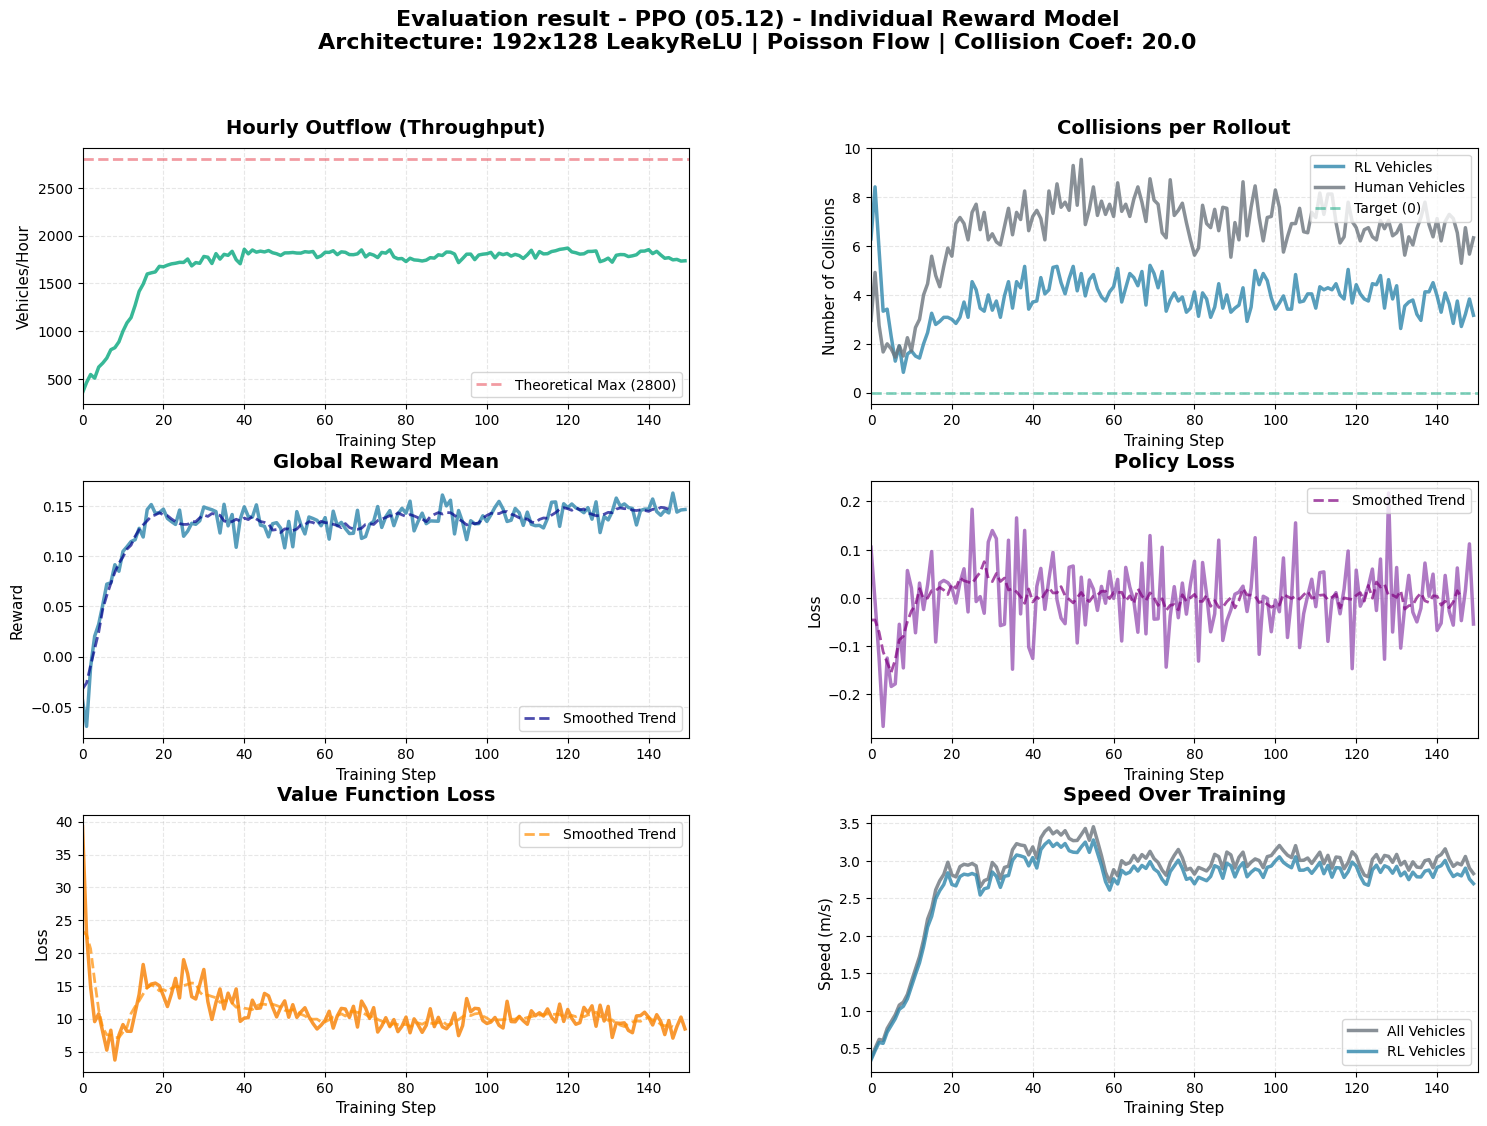


TRAINING SUMMARY - PPO (01.12)
Total Training Steps: 150

Final Metrics (Last 10 Steps Average):
--------------------------------------------------------------------------------
Hourly Outflow      : 1772.067 veh/hr
Collisions          :    9.856 per rollout
Global Reward       :    0.148 
Policy Loss         :   -0.000 
Value Loss          :    9.005 
Speed (All)         :    2.990 m/s
Speed (RL)          :    2.845 m/s

Performance Indicators:
--------------------------------------------------------------------------------
Throughput Efficiency: 63.3% of theoretical max
Safety Score: NEEDS IMPROVEMENT (9.86 collisions)
Learning Stability: UNSTABLE (policy loss std: 0.0619)


In [13]:
# Load results
df = pd.read_csv('results/fourway_1x1_penetration0.5_turn_adam_ppo_05.12/train_results.csv')

# Calculate hourly outflow
def calculate_hourly_outflow(df, horizon=2000, sim_step=0.5):
    """Convert outflow per rollout to vehicles per hour"""
    simulation_time_seconds = horizon * sim_step
    simulation_time_hours = simulation_time_seconds / 3600
    df['outflow_hourly'] = df['outflow'] / simulation_time_hours
    return df

df = calculate_hourly_outflow(df.copy())

# Create comprehensive subplot figure
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# Define color scheme
colors = {
    'primary': '#2E86AB',
    'danger': '#E63946',
    'success': '#06A77D',
    'warning': '#F77F00',
    'info': '#9B59B6',
    'secondary': '#6C757D'
}

# --- Subplot 1: Hourly Outflow ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(df['step'], df['outflow_hourly'], linewidth=2.5, color=colors['success'], alpha=0.8)
ax1.axhline(y=2800, color=colors['danger'], linestyle='--', linewidth=2, alpha=0.5, label='Theoretical Max (2800)')
# ax1.fill_between(df['step'], 0, df['outflow_hourly'], alpha=0.2, color=colors['success'])
ax1.set_title('Hourly Outflow (Throughput)', fontsize=14, fontweight='bold', pad=10)
ax1.set_xlabel('Training Step', fontsize=11)
ax1.set_ylabel('Vehicles/Hour', fontsize=11)
ax1.legend(loc='lower right', fontsize=10)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_xlim(df['step'].min(), df['step'].max())

# Add annotation for final value
final_outflow = df['outflow_hourly'].iloc[-1]
ax1.annotate(f'Final: {final_outflow:.1f}', 
            xy=(df['step'].iloc[-1], final_outflow),
            xytext=(10, 10), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            fontsize=10, fontweight='bold')

# --- Subplot 2: Collisions ---
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(df['step'], df['collisions']-df['collisions_human'], label ='RL Vehicles', linewidth=2.5, color=colors['primary'], alpha=0.8)
ax2.plot(df['step'], df['collisions_human'], label ='Human Vehicles', linewidth=2.5, color=colors['secondary'], alpha=0.8)
# ax2.fill_between(df['step'], 0, df['collisions'], alpha=0.2, color=colors['danger'])
ax2.axhline(y=0, color=colors['success'], linestyle='--', linewidth=2, alpha=0.5, label='Target (0)')
ax2.set_title('Collisions per Rollout', fontsize=14, fontweight='bold', pad=10)
ax2.set_xlabel('Training Step', fontsize=11)
ax2.set_ylabel('Number of Collisions', fontsize=11)
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_xlim(df['step'].min(), df['step'].max())

# Add annotation for final value
final_collisions = df['collisions'].iloc[-1]
ax2.annotate(f'Final: {final_collisions:.2f}', 
            xy=(df['step'].iloc[-1], final_collisions),
            xytext=(10, -10), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            fontsize=10, fontweight='bold')

# --- Subplot 3: Global Reward Mean ---
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(df['step'], df['global_reward_mean'], linewidth=2.5, color=colors['primary'], alpha=0.8)
# ax3.fill_between(df['step'], df['global_reward_mean'].min(), df['global_reward_mean'], 
#                  alpha=0.2, color=colors['primary'])
ax3.set_title('Global Reward Mean', fontsize=14, fontweight='bold', pad=10)
ax3.set_xlabel('Training Step', fontsize=11)
ax3.set_ylabel('Reward', fontsize=11)
ax3.grid(True, alpha=0.3, linestyle='--')
ax3.set_xlim(df['step'].min(), df['step'].max())

# Add smoothed trend line
from scipy.ndimage import uniform_filter1d
window_size = max(5, len(df) // 20)
smoothed = uniform_filter1d(df['global_reward_mean'], size=window_size)
ax3.plot(df['step'], smoothed, linewidth=2, color='darkblue', linestyle='--', 
         alpha=0.7, label='Smoothed Trend')
ax3.legend(loc='lower right', fontsize=10)

# --- Subplot 4: Policy Loss ---
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(df['step'], df['policy_loss'], linewidth=2.5, color=colors['info'], alpha=0.8)
# ax4.fill_between(df['step'], 0, df['policy_loss'], alpha=0.2, color=colors['info'])
ax4.set_title('Policy Loss', fontsize=14, fontweight='bold', pad=10)
ax4.set_xlabel('Training Step', fontsize=11)
ax4.set_ylabel('Loss', fontsize=11)
ax4.grid(True, alpha=0.3, linestyle='--')
ax4.set_xlim(df['step'].min(), df['step'].max())

# Add smoothed trend line
smoothed_policy = uniform_filter1d(df['policy_loss'], size=window_size)
ax4.plot(df['step'], smoothed_policy, linewidth=2, color='purple', linestyle='--', 
         alpha=0.7, label='Smoothed Trend')
ax4.legend(loc='upper right', fontsize=10)

# --- Subplot 5: Value Function Loss ---
ax5 = fig.add_subplot(gs[2, 0])
ax5.plot(df['step'], df['value_loss'], linewidth=2.5, color=colors['warning'], alpha=0.8)
# ax5.fill_between(df['step'], 0, df['value_loss'], alpha=0.2, color=colors['warning'])
ax5.set_title('Value Function Loss', fontsize=14, fontweight='bold', pad=10)
ax5.set_xlabel('Training Step', fontsize=11)
ax5.set_ylabel('Loss', fontsize=11)
ax5.grid(True, alpha=0.3, linestyle='--')
ax5.set_xlim(df['step'].min(), df['step'].max())

# Add smoothed trend line
smoothed_value = uniform_filter1d(df['value_loss'], size=window_size)
ax5.plot(df['step'], smoothed_value, linewidth=2, color='darkorange', linestyle='--', 
         alpha=0.7, label='Smoothed Trend')
ax5.legend(loc='upper right', fontsize=10)

# --- Subplot 6: Speed Over Training ---
ax6 = fig.add_subplot(gs[2, 1])
ax6.plot(df['step'], df['speed'], label='All Vehicles', linewidth=2.5, 
         color=colors['secondary'], alpha=0.8)
ax6.plot(df['step'], df['speed_rl'], label='RL Vehicles', linewidth=2.5, 
         color=colors['primary'], alpha=0.8)
# ax6.fill_between(df['step'], df['speed'], alpha=0.1, color=colors['secondary'])
# ax6.fill_between(df['step'], df['speed_rl'], alpha=0.1, color=colors['primary'])
ax6.set_title('Speed Over Training', fontsize=14, fontweight='bold', pad=10)
ax6.set_xlabel('Training Step', fontsize=11)
ax6.set_ylabel('Speed (m/s)', fontsize=11)
ax6.legend(loc='lower right', fontsize=10)
ax6.grid(True, alpha=0.3, linestyle='--')
ax6.set_xlim(df['step'].min(), df['step'].max())

# Add annotation for final speeds
final_speed_all = df['speed'].iloc[-1]
final_speed_rl = df['speed_rl'].iloc[-1]
ax6.annotate(f'All: {final_speed_all:.2f} m/s\nRL: {final_speed_rl:.2f} m/s', 
            xy=(df['step'].iloc[-1], final_speed_rl),
            xytext=(-80, 20), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            fontsize=9, fontweight='bold')

# Add main title
fig.suptitle('Evaluation result - PPO (05.12) - Individual Reward Model\n' + 
             'Architecture: 192x128 LeakyReLU | Poisson Flow | Collision Coef: 20.0',
             fontsize=16, fontweight='bold', y=0.995)

plt.tight_layout()
plt.show()

# --- Print Summary Statistics ---
print("\n" + "="*80)
print("TRAINING SUMMARY - PPO (01.12)")
print("="*80)
print(f"Total Training Steps: {df['step'].max()}")
print(f"\nFinal Metrics (Last 10 Steps Average):")
print("-" * 80)

last_10 = df.tail(10)

metrics = {
    'Hourly Outflow': (last_10['outflow_hourly'].mean(), 'veh/hr'),
    'Collisions': (last_10['collisions'].mean(), 'per rollout'),
    'Global Reward': (last_10['global_reward_mean'].mean(), ''),
    'Policy Loss': (last_10['policy_loss'].mean(), ''),
    'Value Loss': (last_10['value_loss'].mean(), ''),
    'Speed (All)': (last_10['speed'].mean(), 'm/s'),
    'Speed (RL)': (last_10['speed_rl'].mean(), 'm/s'),
}

for metric, (value, unit) in metrics.items():
    print(f"{metric:20s}: {value:8.3f} {unit}")

print("\nPerformance Indicators:")
print("-" * 80)
efficiency = (last_10['outflow_hourly'].mean() / 2800) * 100
print(f"Throughput Efficiency: {efficiency:.1f}% of theoretical max")
print(f"Safety Score: {'EXCELLENT' if last_10['collisions'].mean() < 0.5 else 'NEEDS IMPROVEMENT'} ({last_10['collisions'].mean():.2f} collisions)")
print(f"Learning Stability: {'STABLE' if last_10['policy_loss'].std() < 0.01 else 'UNSTABLE'} (policy loss std: {last_10['policy_loss'].std():.4f})")
print("="*80)

# 06.12

/tmp/ipykernel_1068/2578819067.py:148: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


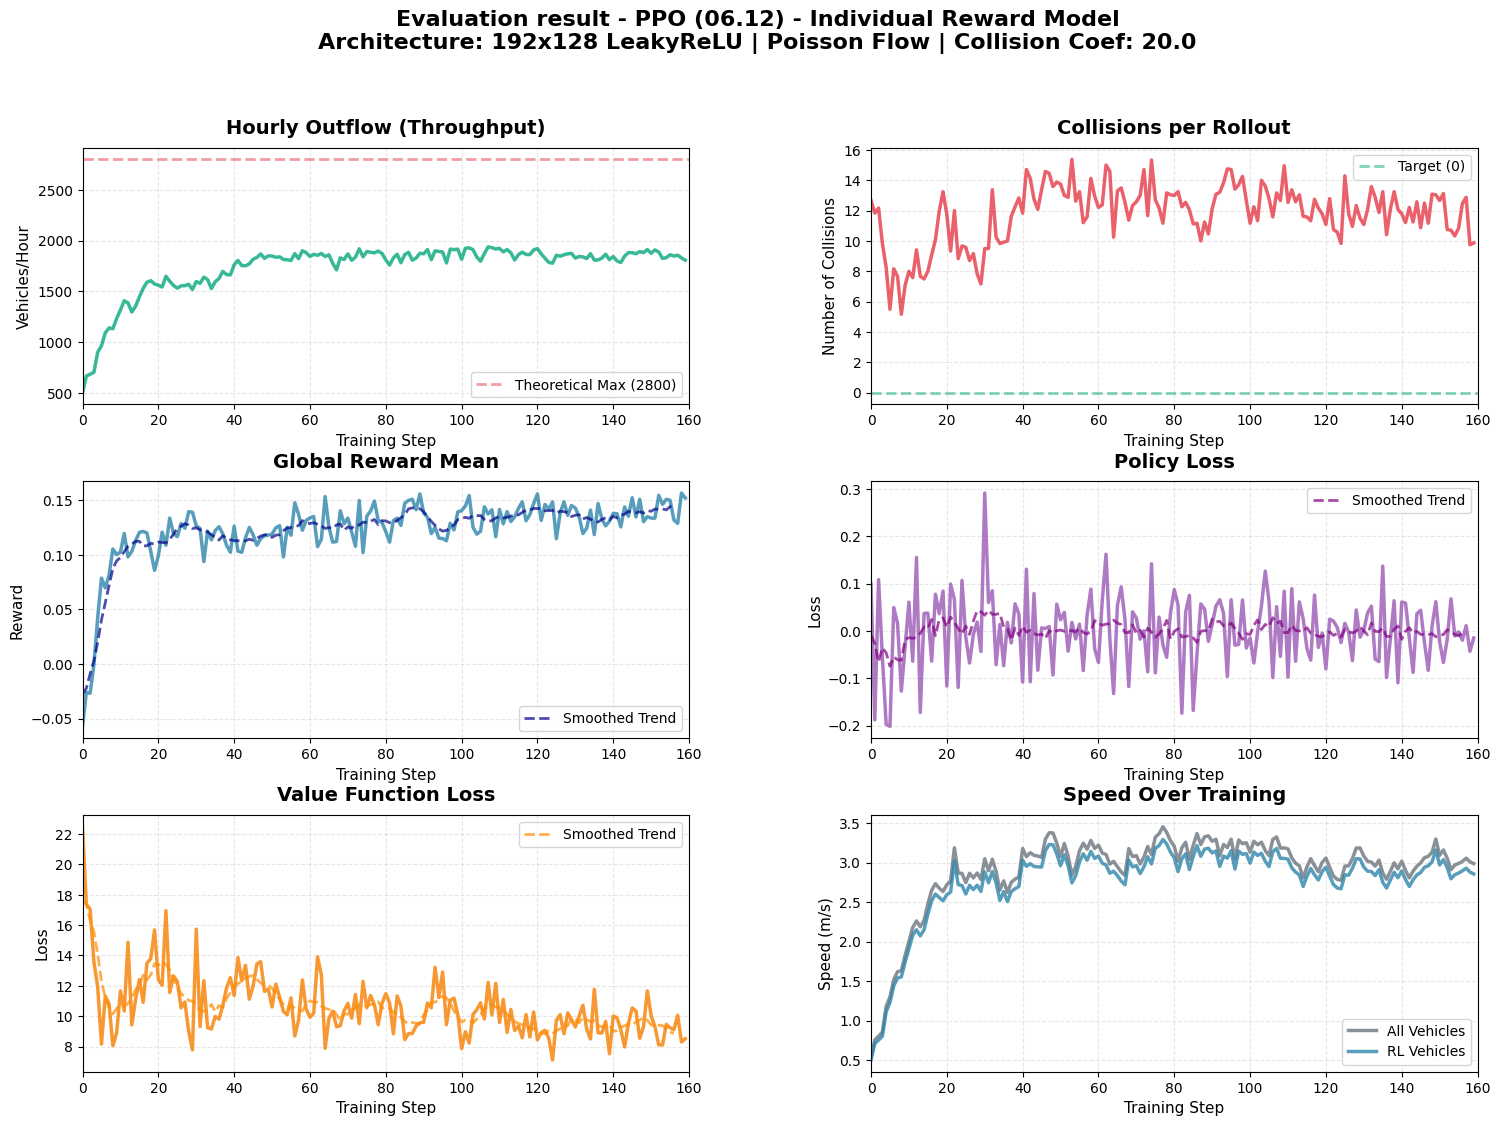


TRAINING SUMMARY - PPO (01.12)
Total Training Steps: 160

Final Metrics (Last 10 Steps Average):
--------------------------------------------------------------------------------
Hourly Outflow      : 1849.932 veh/hr
Collisions          :   11.190 per rollout
Global Reward       :    0.145 
Policy Loss         :   -0.011 
Value Loss          :    8.915 
Speed (All)         :    3.018 m/s
Speed (RL)          :    2.895 m/s

Performance Indicators:
--------------------------------------------------------------------------------
Throughput Efficiency: 66.1% of theoretical max
Safety Score: NEEDS IMPROVEMENT (11.19 collisions)
Learning Stability: UNSTABLE (policy loss std: 0.0371)


In [20]:
# Load results
df = pd.read_csv('results/fourway_1x1_penetration0.5_turn_adam_ppo_06.12/train_results.csv')

# Calculate hourly outflow
def calculate_hourly_outflow(df, horizon=2000, sim_step=0.5):
    """Convert outflow per rollout to vehicles per hour"""
    simulation_time_seconds = horizon * sim_step
    simulation_time_hours = simulation_time_seconds / 3600
    df['outflow_hourly'] = df['outflow'] / simulation_time_hours
    return df

df = calculate_hourly_outflow(df.copy())

# Create comprehensive subplot figure
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# Define color scheme
colors = {
    'primary': '#2E86AB',
    'danger': '#E63946',
    'success': '#06A77D',
    'warning': '#F77F00',
    'info': '#9B59B6',
    'secondary': '#6C757D'
}

# --- Subplot 1: Hourly Outflow ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(df['step'], df['outflow_hourly'], linewidth=2.5, color=colors['success'], alpha=0.8)
ax1.axhline(y=2800, color=colors['danger'], linestyle='--', linewidth=2, alpha=0.5, label='Theoretical Max (2800)')
# ax1.fill_between(df['step'], 0, df['outflow_hourly'], alpha=0.2, color=colors['success'])
ax1.set_title('Hourly Outflow (Throughput)', fontsize=14, fontweight='bold', pad=10)
ax1.set_xlabel('Training Step', fontsize=11)
ax1.set_ylabel('Vehicles/Hour', fontsize=11)
ax1.legend(loc='lower right', fontsize=10)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_xlim(df['step'].min(), df['step'].max())

# Add annotation for final value
final_outflow = df['outflow_hourly'].iloc[-1]
ax1.annotate(f'Final: {final_outflow:.1f}', 
            xy=(df['step'].iloc[-1], final_outflow),
            xytext=(10, 10), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            fontsize=10, fontweight='bold')

# --- Subplot 2: Collisions ---
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(df['step'], df['collisions'], linewidth=2.5, color=colors['danger'], alpha=0.8)
# ax2.fill_between(df['step'], 0, df['collisions'], alpha=0.2, color=colors['danger'])
ax2.axhline(y=0, color=colors['success'], linestyle='--', linewidth=2, alpha=0.5, label='Target (0)')
ax2.set_title('Collisions per Rollout', fontsize=14, fontweight='bold', pad=10)
ax2.set_xlabel('Training Step', fontsize=11)
ax2.set_ylabel('Number of Collisions', fontsize=11)
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_xlim(df['step'].min(), df['step'].max())

# Add annotation for final value
final_collisions = df['collisions'].iloc[-1]
ax2.annotate(f'Final: {final_collisions:.2f}', 
            xy=(df['step'].iloc[-1], final_collisions),
            xytext=(10, -10), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            fontsize=10, fontweight='bold')

# --- Subplot 3: Global Reward Mean ---
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(df['step'], df['global_reward_mean'], linewidth=2.5, color=colors['primary'], alpha=0.8)
# ax3.fill_between(df['step'], df['global_reward_mean'].min(), df['global_reward_mean'], 
#                  alpha=0.2, color=colors['primary'])
ax3.set_title('Global Reward Mean', fontsize=14, fontweight='bold', pad=10)
ax3.set_xlabel('Training Step', fontsize=11)
ax3.set_ylabel('Reward', fontsize=11)
ax3.grid(True, alpha=0.3, linestyle='--')
ax3.set_xlim(df['step'].min(), df['step'].max())

# Add smoothed trend line
from scipy.ndimage import uniform_filter1d
window_size = max(5, len(df) // 20)
smoothed = uniform_filter1d(df['global_reward_mean'], size=window_size)
ax3.plot(df['step'], smoothed, linewidth=2, color='darkblue', linestyle='--', 
         alpha=0.7, label='Smoothed Trend')
ax3.legend(loc='lower right', fontsize=10)

# --- Subplot 4: Policy Loss ---
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(df['step'], df['policy_loss'], linewidth=2.5, color=colors['info'], alpha=0.8)
# ax4.fill_between(df['step'], 0, df['policy_loss'], alpha=0.2, color=colors['info'])
ax4.set_title('Policy Loss', fontsize=14, fontweight='bold', pad=10)
ax4.set_xlabel('Training Step', fontsize=11)
ax4.set_ylabel('Loss', fontsize=11)
ax4.grid(True, alpha=0.3, linestyle='--')
ax4.set_xlim(df['step'].min(), df['step'].max())

# Add smoothed trend line
smoothed_policy = uniform_filter1d(df['policy_loss'], size=window_size)
ax4.plot(df['step'], smoothed_policy, linewidth=2, color='purple', linestyle='--', 
         alpha=0.7, label='Smoothed Trend')
ax4.legend(loc='upper right', fontsize=10)

# --- Subplot 5: Value Function Loss ---
ax5 = fig.add_subplot(gs[2, 0])
ax5.plot(df['step'], df['value_loss'], linewidth=2.5, color=colors['warning'], alpha=0.8)
# ax5.fill_between(df['step'], 0, df['value_loss'], alpha=0.2, color=colors['warning'])
ax5.set_title('Value Function Loss', fontsize=14, fontweight='bold', pad=10)
ax5.set_xlabel('Training Step', fontsize=11)
ax5.set_ylabel('Loss', fontsize=11)
ax5.grid(True, alpha=0.3, linestyle='--')
ax5.set_xlim(df['step'].min(), df['step'].max())

# Add smoothed trend line
smoothed_value = uniform_filter1d(df['value_loss'], size=window_size)
ax5.plot(df['step'], smoothed_value, linewidth=2, color='darkorange', linestyle='--', 
         alpha=0.7, label='Smoothed Trend')
ax5.legend(loc='upper right', fontsize=10)

# --- Subplot 6: Speed Over Training ---
ax6 = fig.add_subplot(gs[2, 1])
ax6.plot(df['step'], df['speed'], label='All Vehicles', linewidth=2.5, 
         color=colors['secondary'], alpha=0.8)
ax6.plot(df['step'], df['speed_rl'], label='RL Vehicles', linewidth=2.5, 
         color=colors['primary'], alpha=0.8)
# ax6.fill_between(df['step'], df['speed'], alpha=0.1, color=colors['secondary'])
# ax6.fill_between(df['step'], df['speed_rl'], alpha=0.1, color=colors['primary'])
ax6.set_title('Speed Over Training', fontsize=14, fontweight='bold', pad=10)
ax6.set_xlabel('Training Step', fontsize=11)
ax6.set_ylabel('Speed (m/s)', fontsize=11)
ax6.legend(loc='lower right', fontsize=10)
ax6.grid(True, alpha=0.3, linestyle='--')
ax6.set_xlim(df['step'].min(), df['step'].max())

# Add annotation for final speeds
final_speed_all = df['speed'].iloc[-1]
final_speed_rl = df['speed_rl'].iloc[-1]
ax6.annotate(f'All: {final_speed_all:.2f} m/s\nRL: {final_speed_rl:.2f} m/s', 
            xy=(df['step'].iloc[-1], final_speed_rl),
            xytext=(-80, 20), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            fontsize=9, fontweight='bold')

# Add main title
fig.suptitle('Evaluation result - PPO (06.12) - Individual Reward Model\n' + 
             'Architecture: 192x128 LeakyReLU | Poisson Flow | Collision Coef: 20.0',
             fontsize=16, fontweight='bold', y=0.995)

plt.tight_layout()
plt.show()

# --- Print Summary Statistics ---
print("\n" + "="*80)
print("TRAINING SUMMARY - PPO (01.12)")
print("="*80)
print(f"Total Training Steps: {df['step'].max()}")
print(f"\nFinal Metrics (Last 10 Steps Average):")
print("-" * 80)

last_10 = df.tail(10)

metrics = {
    'Hourly Outflow': (last_10['outflow_hourly'].mean(), 'veh/hr'),
    'Collisions': (last_10['collisions'].mean(), 'per rollout'),
    'Global Reward': (last_10['global_reward_mean'].mean(), ''),
    'Policy Loss': (last_10['policy_loss'].mean(), ''),
    'Value Loss': (last_10['value_loss'].mean(), ''),
    'Speed (All)': (last_10['speed'].mean(), 'm/s'),
    'Speed (RL)': (last_10['speed_rl'].mean(), 'm/s'),
}

for metric, (value, unit) in metrics.items():
    print(f"{metric:20s}: {value:8.3f} {unit}")

print("\nPerformance Indicators:")
print("-" * 80)
efficiency = (last_10['outflow_hourly'].mean() / 2800) * 100
print(f"Throughput Efficiency: {efficiency:.1f}% of theoretical max")
print(f"Safety Score: {'EXCELLENT' if last_10['collisions'].mean() < 0.5 else 'NEEDS IMPROVEMENT'} ({last_10['collisions'].mean():.2f} collisions)")
print(f"Learning Stability: {'STABLE' if last_10['policy_loss'].std() < 0.01 else 'UNSTABLE'} (policy loss std: {last_10['policy_loss'].std():.4f})")
print("="*80)

# 08.12
Change collision penalty from 20 to 50 (avoid collision at all cost)

/tmp/ipykernel_1647/640313366.py:149: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


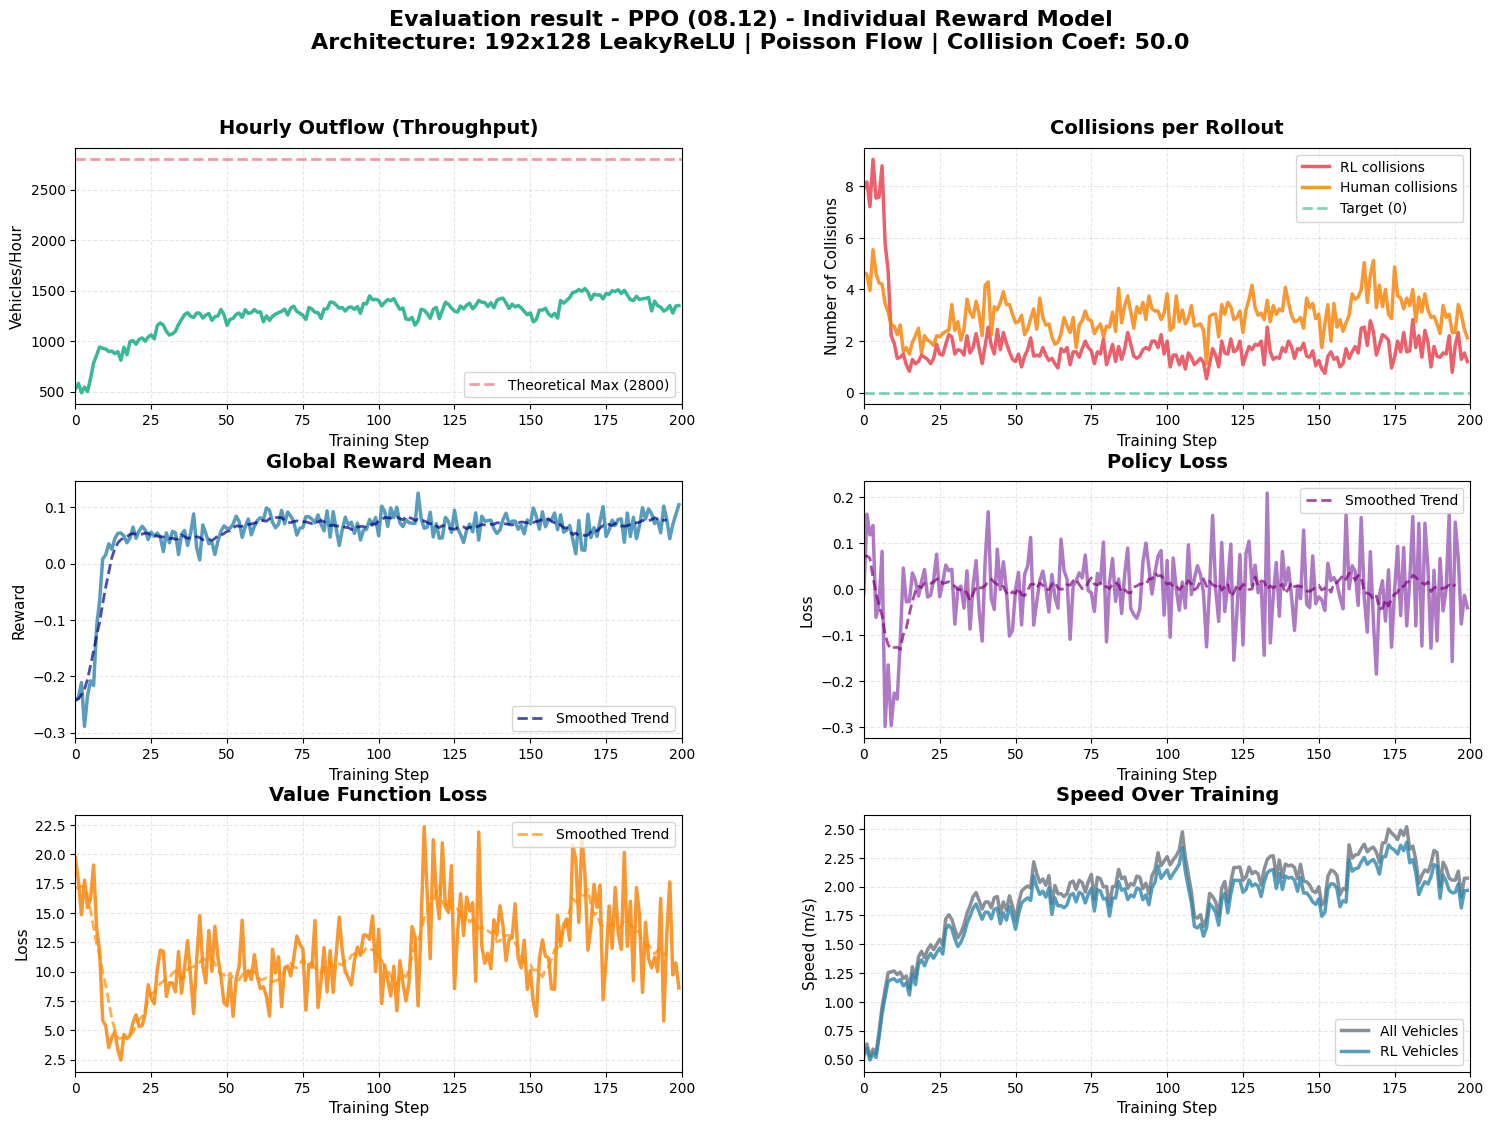


TRAINING SUMMARY - PPO (08.12)
Total Training Steps: 200

Final Metrics (Last 10 Steps Average):
--------------------------------------------------------------------------------
Hourly Outflow      : 1336.266 veh/hr
Collisions          :    4.366 per rollout
Global Reward       :    0.076 
Policy Loss         :    0.005 
Value Loss          :   11.448 
Speed (All)         :    2.083 m/s
Speed (RL)          :    1.976 m/s

Performance Indicators:
--------------------------------------------------------------------------------
Throughput Efficiency: 47.7% of theoretical max
Safety Score: NEEDS IMPROVEMENT (4.37 collisions)
Learning Stability: UNSTABLE (policy loss std: 0.1041)


In [16]:
# Load results
df = pd.read_csv('results/fourway_1x1_penetration0.5_turn_adam_ppo_08.12/train_results.csv')

# Calculate hourly outflow
def calculate_hourly_outflow(df, horizon=2000, sim_step=0.5):
    """Convert outflow per rollout to vehicles per hour"""
    simulation_time_seconds = horizon * sim_step
    simulation_time_hours = simulation_time_seconds / 3600
    df['outflow_hourly'] = df['outflow'] / simulation_time_hours
    return df

df = calculate_hourly_outflow(df.copy())

# Create comprehensive subplot figure
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# Define color scheme
colors = {
    'primary': '#2E86AB',
    'danger': '#E63946',
    'success': '#06A77D',
    'warning': '#F77F00',
    'info': '#9B59B6',
    'secondary': '#6C757D'
}

# --- Subplot 1: Hourly Outflow ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(df['step'], df['outflow_hourly'], linewidth=2.5, color=colors['success'], alpha=0.8)
ax1.axhline(y=2800, color=colors['danger'], linestyle='--', linewidth=2, alpha=0.5, label='Theoretical Max (2800)')
# ax1.fill_between(df['step'], 0, df['outflow_hourly'], alpha=0.2, color=colors['success'])
ax1.set_title('Hourly Outflow (Throughput)', fontsize=14, fontweight='bold', pad=10)
ax1.set_xlabel('Training Step', fontsize=11)
ax1.set_ylabel('Vehicles/Hour', fontsize=11)
ax1.legend(loc='lower right', fontsize=10)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_xlim(df['step'].min(), df['step'].max())

# Add annotation for final value
final_outflow = df['outflow_hourly'].iloc[-1]
ax1.annotate(f'Final: {final_outflow:.1f}', 
            xy=(df['step'].iloc[-1], final_outflow),
            xytext=(10, 10), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            fontsize=10, fontweight='bold')

# --- Subplot 2: Collisions ---
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(df['step'], df['collisions'] - df['collisions_human'], label = 'RL collisions', linewidth=2.5, color=colors['danger'], alpha=0.8)
ax2.plot(df['step'], df['collisions_human'], label = 'Human collisions', linewidth=2.5, color=colors['warning'], alpha=0.8)
# ax2.fill_between(df['step'], 0, df['collisions'], alpha=0.2, color=colors['danger'])
ax2.axhline(y=0, color=colors['success'], linestyle='--', linewidth=2, alpha=0.5, label='Target (0)')
ax2.set_title('Collisions per Rollout', fontsize=14, fontweight='bold', pad=10)
ax2.set_xlabel('Training Step', fontsize=11)
ax2.set_ylabel('Number of Collisions', fontsize=11)
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_xlim(df['step'].min(), df['step'].max())

# Add annotation for final value
final_collisions = df['collisions'].iloc[-1]
ax2.annotate(f'Final: {final_collisions:.2f}', 
            xy=(df['step'].iloc[-1], final_collisions),
            xytext=(10, -10), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            fontsize=10, fontweight='bold')

# --- Subplot 3: Global Reward Mean ---
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(df['step'], df['global_reward_mean'], linewidth=2.5, color=colors['primary'], alpha=0.8)
# ax3.fill_between(df['step'], df['global_reward_mean'].min(), df['global_reward_mean'], 
#                  alpha=0.2, color=colors['primary'])
ax3.set_title('Global Reward Mean', fontsize=14, fontweight='bold', pad=10)
ax3.set_xlabel('Training Step', fontsize=11)
ax3.set_ylabel('Reward', fontsize=11)
ax3.grid(True, alpha=0.3, linestyle='--')
ax3.set_xlim(df['step'].min(), df['step'].max())

# Add smoothed trend line
from scipy.ndimage import uniform_filter1d
window_size = max(5, len(df) // 20)
smoothed = uniform_filter1d(df['global_reward_mean'], size=window_size)
ax3.plot(df['step'], smoothed, linewidth=2, color='darkblue', linestyle='--', 
         alpha=0.7, label='Smoothed Trend')
ax3.legend(loc='lower right', fontsize=10)

# --- Subplot 4: Policy Loss ---
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(df['step'], df['policy_loss'], linewidth=2.5, color=colors['info'], alpha=0.8)
# ax4.fill_between(df['step'], 0, df['policy_loss'], alpha=0.2, color=colors['info'])
ax4.set_title('Policy Loss', fontsize=14, fontweight='bold', pad=10)
ax4.set_xlabel('Training Step', fontsize=11)
ax4.set_ylabel('Loss', fontsize=11)
ax4.grid(True, alpha=0.3, linestyle='--')
ax4.set_xlim(df['step'].min(), df['step'].max())

# Add smoothed trend line
smoothed_policy = uniform_filter1d(df['policy_loss'], size=window_size)
ax4.plot(df['step'], smoothed_policy, linewidth=2, color='purple', linestyle='--', 
         alpha=0.7, label='Smoothed Trend')
ax4.legend(loc='upper right', fontsize=10)

# --- Subplot 5: Value Function Loss ---
ax5 = fig.add_subplot(gs[2, 0])
ax5.plot(df['step'], df['value_loss'], linewidth=2.5, color=colors['warning'], alpha=0.8)
# ax5.fill_between(df['step'], 0, df['value_loss'], alpha=0.2, color=colors['warning'])
ax5.set_title('Value Function Loss', fontsize=14, fontweight='bold', pad=10)
ax5.set_xlabel('Training Step', fontsize=11)
ax5.set_ylabel('Loss', fontsize=11)
ax5.grid(True, alpha=0.3, linestyle='--')
ax5.set_xlim(df['step'].min(), df['step'].max())

# Add smoothed trend line
smoothed_value = uniform_filter1d(df['value_loss'], size=window_size)
ax5.plot(df['step'], smoothed_value, linewidth=2, color='darkorange', linestyle='--', 
         alpha=0.7, label='Smoothed Trend')
ax5.legend(loc='upper right', fontsize=10)

# --- Subplot 6: Speed Over Training ---
ax6 = fig.add_subplot(gs[2, 1])
ax6.plot(df['step'], df['speed'], label='All Vehicles', linewidth=2.5, 
         color=colors['secondary'], alpha=0.8)
ax6.plot(df['step'], df['speed_rl'], label='RL Vehicles', linewidth=2.5, 
         color=colors['primary'], alpha=0.8)
# ax6.fill_between(df['step'], df['speed'], alpha=0.1, color=colors['secondary'])
# ax6.fill_between(df['step'], df['speed_rl'], alpha=0.1, color=colors['primary'])
ax6.set_title('Speed Over Training', fontsize=14, fontweight='bold', pad=10)
ax6.set_xlabel('Training Step', fontsize=11)
ax6.set_ylabel('Speed (m/s)', fontsize=11)
ax6.legend(loc='lower right', fontsize=10)
ax6.grid(True, alpha=0.3, linestyle='--')
ax6.set_xlim(df['step'].min(), df['step'].max())

# Add annotation for final speeds
final_speed_all = df['speed'].iloc[-1]
final_speed_rl = df['speed_rl'].iloc[-1]
ax6.annotate(f'All: {final_speed_all:.2f} m/s\nRL: {final_speed_rl:.2f} m/s', 
            xy=(df['step'].iloc[-1], final_speed_rl),
            xytext=(-80, 20), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            fontsize=9, fontweight='bold')

# Add main title
fig.suptitle('Evaluation result - PPO (08.12) - Individual Reward Model\n' + 
             'Architecture: 192x128 LeakyReLU | Poisson Flow | Collision Coef: 50.0',
             fontsize=16, fontweight='bold', y=0.995)

plt.tight_layout()
plt.show()

# --- Print Summary Statistics ---
print("\n" + "="*80)
print("TRAINING SUMMARY - PPO (08.12)")
print("="*80)
print(f"Total Training Steps: {df['step'].max()}")
print(f"\nFinal Metrics (Last 10 Steps Average):")
print("-" * 80)

last_10 = df.tail(10)

metrics = {
    'Hourly Outflow': (last_10['outflow_hourly'].mean(), 'veh/hr'),
    'Collisions': (last_10['collisions'].mean(), 'per rollout'),
    'Global Reward': (last_10['global_reward_mean'].mean(), ''),
    'Policy Loss': (last_10['policy_loss'].mean(), ''),
    'Value Loss': (last_10['value_loss'].mean(), ''),
    'Speed (All)': (last_10['speed'].mean(), 'm/s'),
    'Speed (RL)': (last_10['speed_rl'].mean(), 'm/s'),
}

for metric, (value, unit) in metrics.items():
    print(f"{metric:20s}: {value:8.3f} {unit}")

print("\nPerformance Indicators:")
print("-" * 80)
efficiency = (last_10['outflow_hourly'].mean() / 2800) * 100
print(f"Throughput Efficiency: {efficiency:.1f}% of theoretical max")
print(f"Safety Score: {'EXCELLENT' if last_10['collisions'].mean() < 0.5 else 'NEEDS IMPROVEMENT'} ({last_10['collisions'].mean():.2f} collisions)")
print(f"Learning Stability: {'STABLE' if last_10['policy_loss'].std() < 0.01 else 'UNSTABLE'} (policy loss std: {last_10['policy_loss'].std():.4f})")
print("="*80)

# 09.12


/tmp/ipykernel_7197/1412412494.py:149: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


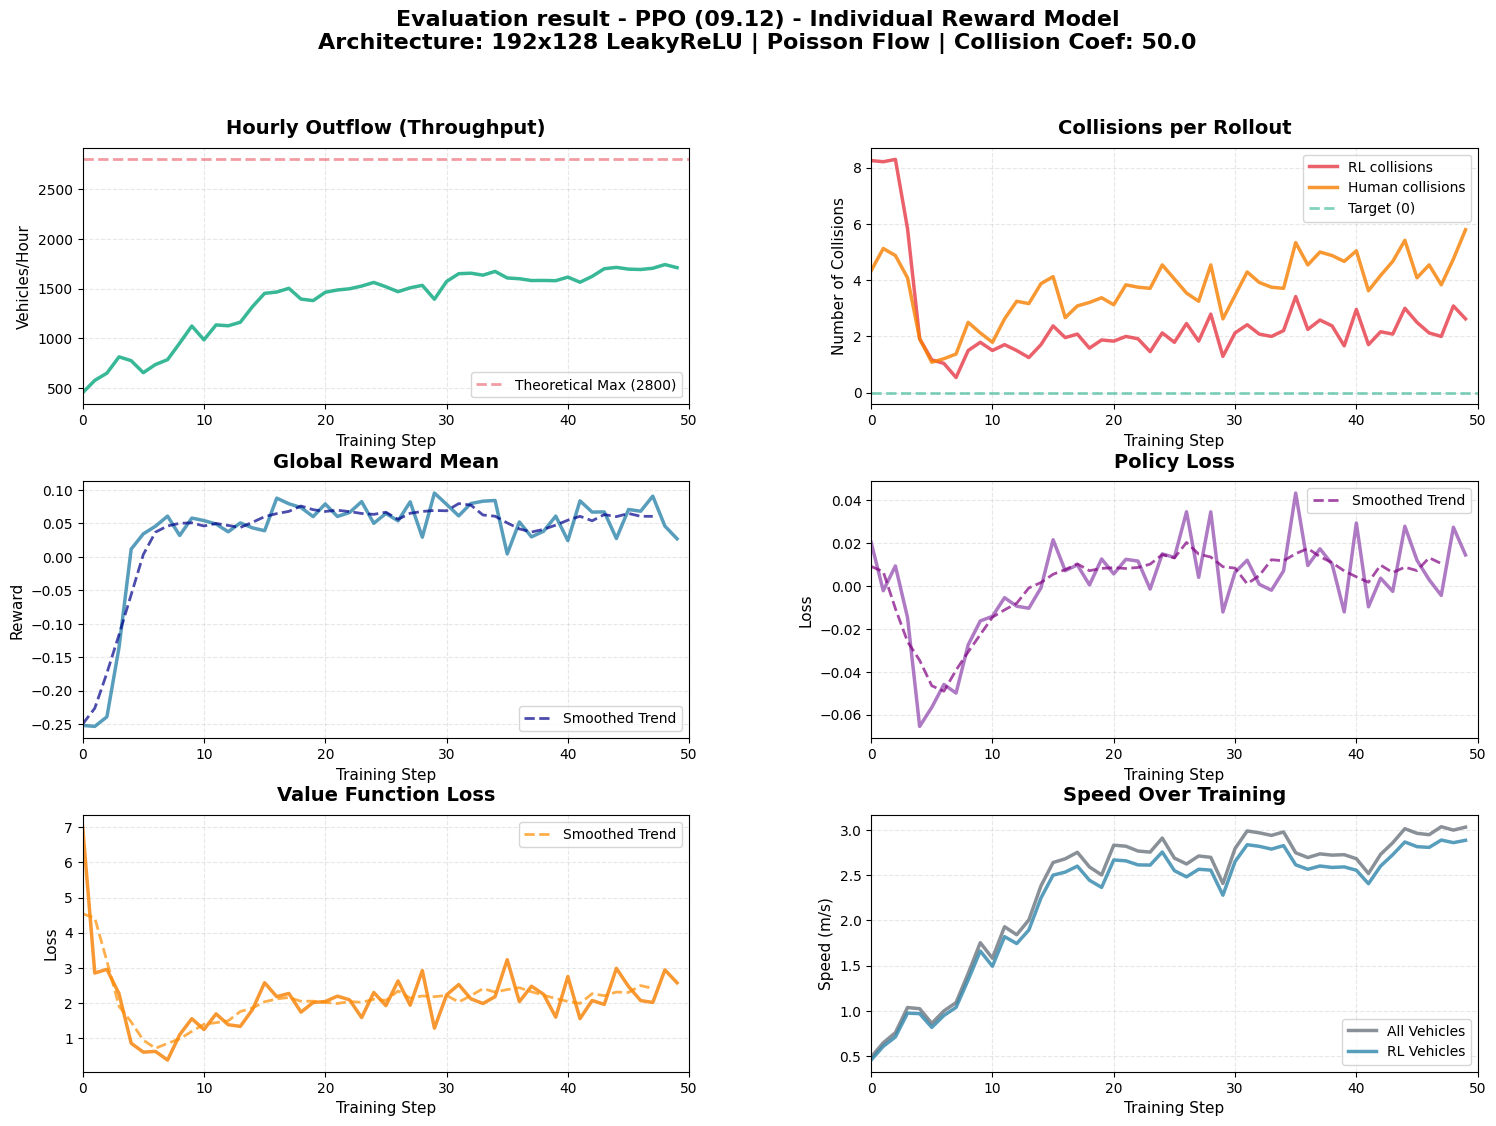


TRAINING SUMMARY - PPO (09.12)
Total Training Steps: 50

Final Metrics (Last 10 Steps Average):
--------------------------------------------------------------------------------
Hourly Outflow      : 1682.167 veh/hr
Collisions          :    6.907 per rollout
Global Reward       :    0.061 
Policy Loss         :    0.008 
Value Loss          :    2.293 
Speed (All)         :    2.899 m/s
Speed (RL)          :    2.761 m/s

Performance Indicators:
--------------------------------------------------------------------------------
Throughput Efficiency: 60.1% of theoretical max
Safety Score: NEEDS IMPROVEMENT (6.91 collisions)
Learning Stability: UNSTABLE (policy loss std: 0.0135)


In [9]:
# Load results
df = pd.read_csv('results/fourway_1x1_penetration0.5_turn_adam_ppo_09.12/train_results.csv')

# Calculate hourly outflow
def calculate_hourly_outflow(df, horizon=2000, sim_step=0.5):
    """Convert outflow per rollout to vehicles per hour"""
    simulation_time_seconds = horizon * sim_step
    simulation_time_hours = simulation_time_seconds / 3600
    df['outflow_hourly'] = df['outflow'] / simulation_time_hours
    return df

df = calculate_hourly_outflow(df.copy())

# Create comprehensive subplot figure
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# Define color scheme
colors = {
    'primary': '#2E86AB',
    'danger': '#E63946',
    'success': '#06A77D',
    'warning': '#F77F00',
    'info': '#9B59B6',
    'secondary': '#6C757D'
}

# --- Subplot 1: Hourly Outflow ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(df['step'], df['outflow_hourly'], linewidth=2.5, color=colors['success'], alpha=0.8)
ax1.axhline(y=2800, color=colors['danger'], linestyle='--', linewidth=2, alpha=0.5, label='Theoretical Max (2800)')
# ax1.fill_between(df['step'], 0, df['outflow_hourly'], alpha=0.2, color=colors['success'])
ax1.set_title('Hourly Outflow (Throughput)', fontsize=14, fontweight='bold', pad=10)
ax1.set_xlabel('Training Step', fontsize=11)
ax1.set_ylabel('Vehicles/Hour', fontsize=11)
ax1.legend(loc='lower right', fontsize=10)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_xlim(df['step'].min(), df['step'].max())

# Add annotation for final value
final_outflow = df['outflow_hourly'].iloc[-1]
ax1.annotate(f'Final: {final_outflow:.1f}', 
            xy=(df['step'].iloc[-1], final_outflow),
            xytext=(10, 10), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            fontsize=10, fontweight='bold')

# --- Subplot 2: Collisions ---
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(df['step'], df['collisions'] - df['collisions_human'], label = 'RL collisions', linewidth=2.5, color=colors['danger'], alpha=0.8)
ax2.plot(df['step'], df['collisions_human'], label = 'Human collisions', linewidth=2.5, color=colors['warning'], alpha=0.8)
# ax2.fill_between(df['step'], 0, df['collisions'], alpha=0.2, color=colors['danger'])
ax2.axhline(y=0, color=colors['success'], linestyle='--', linewidth=2, alpha=0.5, label='Target (0)')
ax2.set_title('Collisions per Rollout', fontsize=14, fontweight='bold', pad=10)
ax2.set_xlabel('Training Step', fontsize=11)
ax2.set_ylabel('Number of Collisions', fontsize=11)
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_xlim(df['step'].min(), df['step'].max())

# Add annotation for final value
final_collisions = df['collisions'].iloc[-1]
ax2.annotate(f'Final: {final_collisions:.2f}', 
            xy=(df['step'].iloc[-1], final_collisions),
            xytext=(10, -10), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            fontsize=10, fontweight='bold')

# --- Subplot 3: Global Reward Mean ---
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(df['step'], df['global_reward_mean'], linewidth=2.5, color=colors['primary'], alpha=0.8)
# ax3.fill_between(df['step'], df['global_reward_mean'].min(), df['global_reward_mean'], 
#                  alpha=0.2, color=colors['primary'])
ax3.set_title('Global Reward Mean', fontsize=14, fontweight='bold', pad=10)
ax3.set_xlabel('Training Step', fontsize=11)
ax3.set_ylabel('Reward', fontsize=11)
ax3.grid(True, alpha=0.3, linestyle='--')
ax3.set_xlim(df['step'].min(), df['step'].max())

# Add smoothed trend line
from scipy.ndimage import uniform_filter1d
window_size = max(5, len(df) // 20)
smoothed = uniform_filter1d(df['global_reward_mean'], size=window_size)
ax3.plot(df['step'], smoothed, linewidth=2, color='darkblue', linestyle='--', 
         alpha=0.7, label='Smoothed Trend')
ax3.legend(loc='lower right', fontsize=10)

# --- Subplot 4: Policy Loss ---
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(df['step'], df['policy_loss'], linewidth=2.5, color=colors['info'], alpha=0.8)
# ax4.fill_between(df['step'], 0, df['policy_loss'], alpha=0.2, color=colors['info'])
ax4.set_title('Policy Loss', fontsize=14, fontweight='bold', pad=10)
ax4.set_xlabel('Training Step', fontsize=11)
ax4.set_ylabel('Loss', fontsize=11)
ax4.grid(True, alpha=0.3, linestyle='--')
ax4.set_xlim(df['step'].min(), df['step'].max())

# Add smoothed trend line
smoothed_policy = uniform_filter1d(df['policy_loss'], size=window_size)
ax4.plot(df['step'], smoothed_policy, linewidth=2, color='purple', linestyle='--', 
         alpha=0.7, label='Smoothed Trend')
ax4.legend(loc='upper right', fontsize=10)

# --- Subplot 5: Value Function Loss ---
ax5 = fig.add_subplot(gs[2, 0])
ax5.plot(df['step'], df['value_loss'], linewidth=2.5, color=colors['warning'], alpha=0.8)
# ax5.fill_between(df['step'], 0, df['value_loss'], alpha=0.2, color=colors['warning'])
ax5.set_title('Value Function Loss', fontsize=14, fontweight='bold', pad=10)
ax5.set_xlabel('Training Step', fontsize=11)
ax5.set_ylabel('Loss', fontsize=11)
ax5.grid(True, alpha=0.3, linestyle='--')
ax5.set_xlim(df['step'].min(), df['step'].max())

# Add smoothed trend line
smoothed_value = uniform_filter1d(df['value_loss'], size=window_size)
ax5.plot(df['step'], smoothed_value, linewidth=2, color='darkorange', linestyle='--', 
         alpha=0.7, label='Smoothed Trend')
ax5.legend(loc='upper right', fontsize=10)

# --- Subplot 6: Speed Over Training ---
ax6 = fig.add_subplot(gs[2, 1])
ax6.plot(df['step'], df['speed'], label='All Vehicles', linewidth=2.5, 
         color=colors['secondary'], alpha=0.8)
ax6.plot(df['step'], df['speed_rl'], label='RL Vehicles', linewidth=2.5, 
         color=colors['primary'], alpha=0.8)
# ax6.fill_between(df['step'], df['speed'], alpha=0.1, color=colors['secondary'])
# ax6.fill_between(df['step'], df['speed_rl'], alpha=0.1, color=colors['primary'])
ax6.set_title('Speed Over Training', fontsize=14, fontweight='bold', pad=10)
ax6.set_xlabel('Training Step', fontsize=11)
ax6.set_ylabel('Speed (m/s)', fontsize=11)
ax6.legend(loc='lower right', fontsize=10)
ax6.grid(True, alpha=0.3, linestyle='--')
ax6.set_xlim(df['step'].min(), df['step'].max())

# Add annotation for final speeds
final_speed_all = df['speed'].iloc[-1]
final_speed_rl = df['speed_rl'].iloc[-1]
ax6.annotate(f'All: {final_speed_all:.2f} m/s\nRL: {final_speed_rl:.2f} m/s', 
            xy=(df['step'].iloc[-1], final_speed_rl),
            xytext=(-80, 20), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            fontsize=9, fontweight='bold')

# Add main title
fig.suptitle('Evaluation result - PPO (09.12) - Individual Reward Model\n' + 
             'Architecture: 192x128 LeakyReLU | Poisson Flow | Collision Coef: 50.0',
             fontsize=16, fontweight='bold', y=0.995)

plt.tight_layout()
plt.show()

# --- Print Summary Statistics ---
print("\n" + "="*80)
print("TRAINING SUMMARY - PPO (09.12)")
print("="*80)
print(f"Total Training Steps: {df['step'].max()}")
print(f"\nFinal Metrics (Last 10 Steps Average):")
print("-" * 80)

last_10 = df.tail(10)

metrics = {
    'Hourly Outflow': (last_10['outflow_hourly'].mean(), 'veh/hr'),
    'Collisions': (last_10['collisions'].mean(), 'per rollout'),
    'Global Reward': (last_10['global_reward_mean'].mean(), ''),
    'Policy Loss': (last_10['policy_loss'].mean(), ''),
    'Value Loss': (last_10['value_loss'].mean(), ''),
    'Speed (All)': (last_10['speed'].mean(), 'm/s'),
    'Speed (RL)': (last_10['speed_rl'].mean(), 'm/s'),
}

for metric, (value, unit) in metrics.items():
    print(f"{metric:20s}: {value:8.3f} {unit}")

print("\nPerformance Indicators:")
print("-" * 80)
efficiency = (last_10['outflow_hourly'].mean() / 2800) * 100
print(f"Throughput Efficiency: {efficiency:.1f}% of theoretical max")
print(f"Safety Score: {'EXCELLENT' if last_10['collisions'].mean() < 0.5 else 'NEEDS IMPROVEMENT'} ({last_10['collisions'].mean():.2f} collisions)")
print(f"Learning Stability: {'STABLE' if last_10['policy_loss'].std() < 0.01 else 'UNSTABLE'} (policy loss std: {last_10['policy_loss'].std():.4f})")
print("="*80)

# 10.12
Rework reward function

/tmp/ipykernel_197322/1947820780.py:149: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


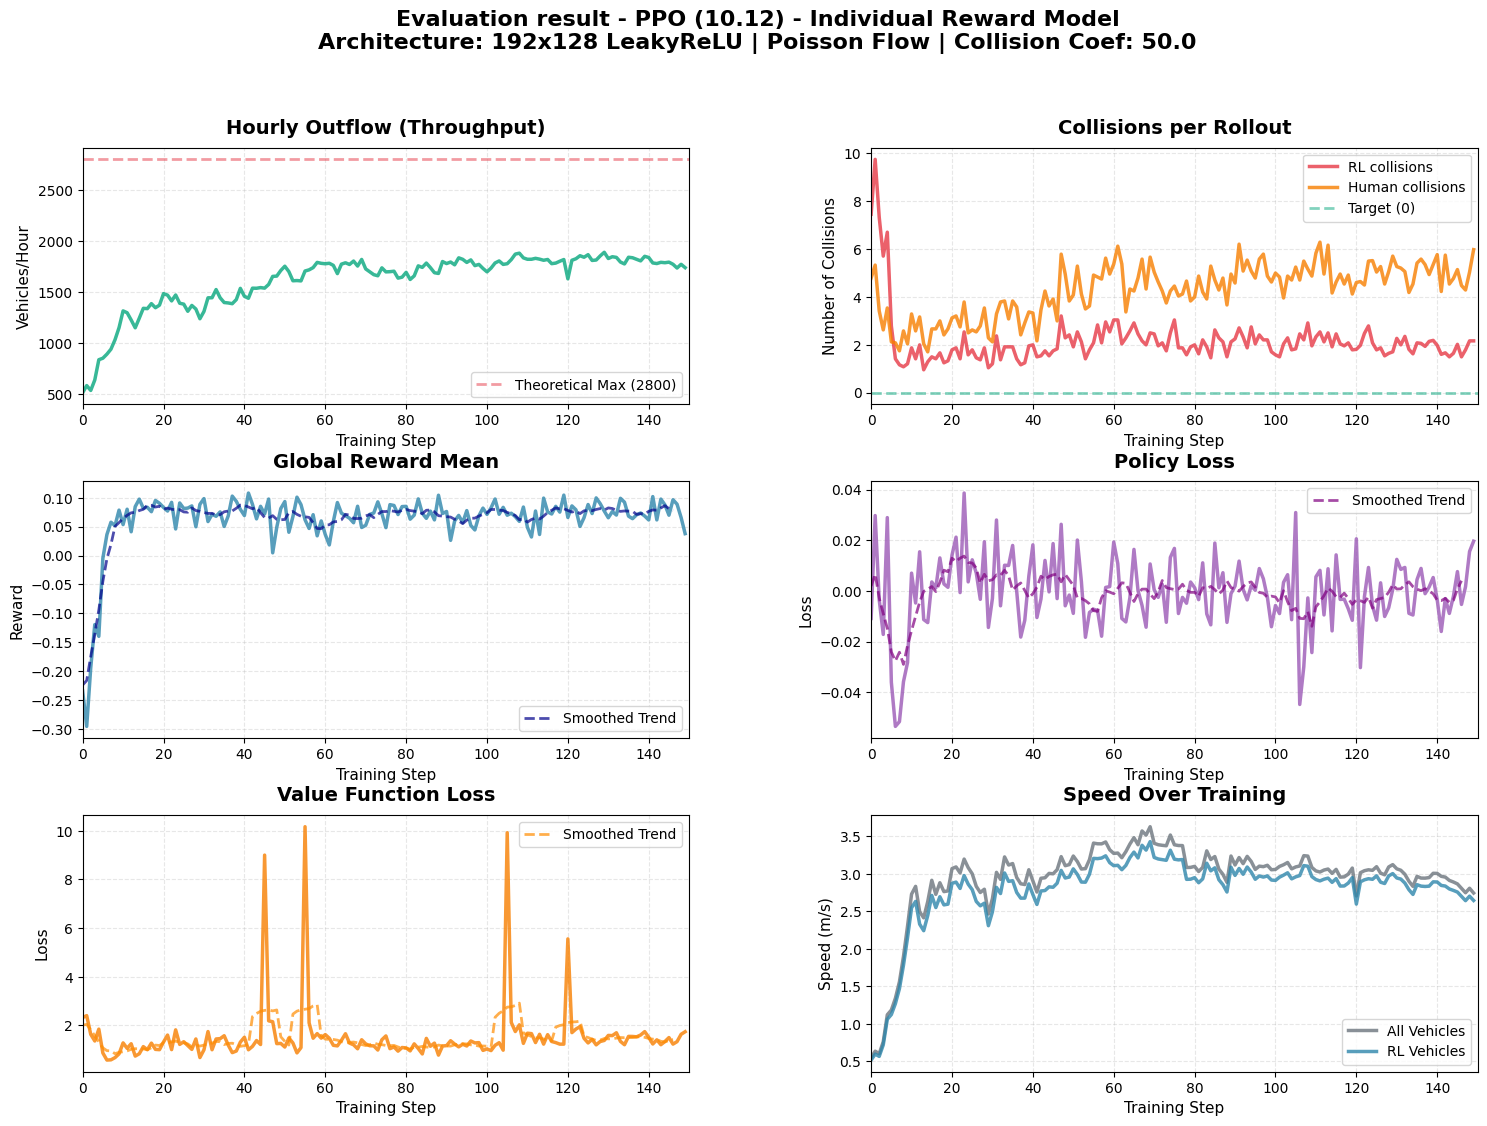


TRAINING SUMMARY - PPO (10.12)
Total Training Steps: 150

Final Metrics (Last 10 Steps Average):
--------------------------------------------------------------------------------
Hourly Outflow      : 1773.142 veh/hr
Collisions          :    6.699 per rollout
Global Reward       :    0.079 
Policy Loss         :    0.001 
Value Loss          :    1.404 
Speed (All)         :    2.855 m/s
Speed (RL)          :    2.745 m/s

Performance Indicators:
--------------------------------------------------------------------------------
Throughput Efficiency: 63.3% of theoretical max
Safety Score: NEEDS IMPROVEMENT (6.70 collisions)
Learning Stability: UNSTABLE (policy loss std: 0.0115)


In [6]:
# Load results
df = pd.read_csv('results/fourway_1x1_penetration0.5_turn_adam_ppo_10.12/train_results.csv')

# Calculate hourly outflow
def calculate_hourly_outflow(df, horizon=2000, sim_step=0.5):
    """Convert outflow per rollout to vehicles per hour"""
    simulation_time_seconds = horizon * sim_step
    simulation_time_hours = simulation_time_seconds / 3600
    df['outflow_hourly'] = df['outflow'] / simulation_time_hours
    return df

df = calculate_hourly_outflow(df.copy())

# Create comprehensive subplot figure
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# Define color scheme
colors = {
    'primary': '#2E86AB',
    'danger': '#E63946',
    'success': '#06A77D',
    'warning': '#F77F00',
    'info': '#9B59B6',
    'secondary': '#6C757D'
}

# --- Subplot 1: Hourly Outflow ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(df['step'], df['outflow_hourly'], linewidth=2.5, color=colors['success'], alpha=0.8)
ax1.axhline(y=2800, color=colors['danger'], linestyle='--', linewidth=2, alpha=0.5, label='Theoretical Max (2800)')
# ax1.fill_between(df['step'], 0, df['outflow_hourly'], alpha=0.2, color=colors['success'])
ax1.set_title('Hourly Outflow (Throughput)', fontsize=14, fontweight='bold', pad=10)
ax1.set_xlabel('Training Step', fontsize=11)
ax1.set_ylabel('Vehicles/Hour', fontsize=11)
ax1.legend(loc='lower right', fontsize=10)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_xlim(df['step'].min(), df['step'].max())

# Add annotation for final value
final_outflow = df['outflow_hourly'].iloc[-1]
ax1.annotate(f'Final: {final_outflow:.1f}', 
            xy=(df['step'].iloc[-1], final_outflow),
            xytext=(10, 10), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            fontsize=10, fontweight='bold')

# --- Subplot 2: Collisions ---
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(df['step'], df['collisions'] - df['collisions_human'], label = 'RL collisions', linewidth=2.5, color=colors['danger'], alpha=0.8)
ax2.plot(df['step'], df['collisions_human'], label = 'Human collisions', linewidth=2.5, color=colors['warning'], alpha=0.8)
# ax2.fill_between(df['step'], 0, df['collisions'], alpha=0.2, color=colors['danger'])
ax2.axhline(y=0, color=colors['success'], linestyle='--', linewidth=2, alpha=0.5, label='Target (0)')
ax2.set_title('Collisions per Rollout', fontsize=14, fontweight='bold', pad=10)
ax2.set_xlabel('Training Step', fontsize=11)
ax2.set_ylabel('Number of Collisions', fontsize=11)
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_xlim(df['step'].min(), df['step'].max())

# Add annotation for final value
final_collisions = df['collisions'].iloc[-1]
ax2.annotate(f'Final: {final_collisions:.2f}', 
            xy=(df['step'].iloc[-1], final_collisions),
            xytext=(10, -10), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            fontsize=10, fontweight='bold')

# --- Subplot 3: Global Reward Mean ---
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(df['step'], df['global_reward_mean'], linewidth=2.5, color=colors['primary'], alpha=0.8)
# ax3.fill_between(df['step'], df['global_reward_mean'].min(), df['global_reward_mean'], 
#                  alpha=0.2, color=colors['primary'])
ax3.set_title('Global Reward Mean', fontsize=14, fontweight='bold', pad=10)
ax3.set_xlabel('Training Step', fontsize=11)
ax3.set_ylabel('Reward', fontsize=11)
ax3.grid(True, alpha=0.3, linestyle='--')
ax3.set_xlim(df['step'].min(), df['step'].max())

# Add smoothed trend line
from scipy.ndimage import uniform_filter1d
window_size = max(5, len(df) // 20)
smoothed = uniform_filter1d(df['global_reward_mean'], size=window_size)
ax3.plot(df['step'], smoothed, linewidth=2, color='darkblue', linestyle='--', 
         alpha=0.7, label='Smoothed Trend')
ax3.legend(loc='lower right', fontsize=10)

# --- Subplot 4: Policy Loss ---
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(df['step'], df['policy_loss'], linewidth=2.5, color=colors['info'], alpha=0.8)
# ax4.fill_between(df['step'], 0, df['policy_loss'], alpha=0.2, color=colors['info'])
ax4.set_title('Policy Loss', fontsize=14, fontweight='bold', pad=10)
ax4.set_xlabel('Training Step', fontsize=11)
ax4.set_ylabel('Loss', fontsize=11)
ax4.grid(True, alpha=0.3, linestyle='--')
ax4.set_xlim(df['step'].min(), df['step'].max())

# Add smoothed trend line
smoothed_policy = uniform_filter1d(df['policy_loss'], size=window_size)
ax4.plot(df['step'], smoothed_policy, linewidth=2, color='purple', linestyle='--', 
         alpha=0.7, label='Smoothed Trend')
ax4.legend(loc='upper right', fontsize=10)

# --- Subplot 5: Value Function Loss ---
ax5 = fig.add_subplot(gs[2, 0])
ax5.plot(df['step'], df['value_loss'], linewidth=2.5, color=colors['warning'], alpha=0.8)
# ax5.fill_between(df['step'], 0, df['value_loss'], alpha=0.2, color=colors['warning'])
ax5.set_title('Value Function Loss', fontsize=14, fontweight='bold', pad=10)
ax5.set_xlabel('Training Step', fontsize=11)
ax5.set_ylabel('Loss', fontsize=11)
ax5.grid(True, alpha=0.3, linestyle='--')
ax5.set_xlim(df['step'].min(), df['step'].max())

# Add smoothed trend line
smoothed_value = uniform_filter1d(df['value_loss'], size=window_size)
ax5.plot(df['step'], smoothed_value, linewidth=2, color='darkorange', linestyle='--', 
         alpha=0.7, label='Smoothed Trend')
ax5.legend(loc='upper right', fontsize=10)

# --- Subplot 6: Speed Over Training ---
ax6 = fig.add_subplot(gs[2, 1])
ax6.plot(df['step'], df['speed'], label='All Vehicles', linewidth=2.5, 
         color=colors['secondary'], alpha=0.8)
ax6.plot(df['step'], df['speed_rl'], label='RL Vehicles', linewidth=2.5, 
         color=colors['primary'], alpha=0.8)
# ax6.fill_between(df['step'], df['speed'], alpha=0.1, color=colors['secondary'])
# ax6.fill_between(df['step'], df['speed_rl'], alpha=0.1, color=colors['primary'])
ax6.set_title('Speed Over Training', fontsize=14, fontweight='bold', pad=10)
ax6.set_xlabel('Training Step', fontsize=11)
ax6.set_ylabel('Speed (m/s)', fontsize=11)
ax6.legend(loc='lower right', fontsize=10)
ax6.grid(True, alpha=0.3, linestyle='--')
ax6.set_xlim(df['step'].min(), df['step'].max())

# Add annotation for final speeds
final_speed_all = df['speed'].iloc[-1]
final_speed_rl = df['speed_rl'].iloc[-1]
ax6.annotate(f'All: {final_speed_all:.2f} m/s\nRL: {final_speed_rl:.2f} m/s', 
            xy=(df['step'].iloc[-1], final_speed_rl),
            xytext=(-80, 20), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            fontsize=9, fontweight='bold')

# Add main title
fig.suptitle('Evaluation result - PPO (10.12) - Individual Reward Model\n' + 
             'Architecture: 192x128 LeakyReLU | Poisson Flow | Collision Coef: 50.0',
             fontsize=16, fontweight='bold', y=0.995)

plt.tight_layout()
plt.show()

# --- Print Summary Statistics ---
print("\n" + "="*80)
print("TRAINING SUMMARY - PPO (10.12)")
print("="*80)
print(f"Total Training Steps: {df['step'].max()}")
print(f"\nFinal Metrics (Last 10 Steps Average):")
print("-" * 80)

last_10 = df.tail(10)

metrics = {
    'Hourly Outflow': (last_10['outflow_hourly'].mean(), 'veh/hr'),
    'Collisions': (last_10['collisions'].mean(), 'per rollout'),
    'Global Reward': (last_10['global_reward_mean'].mean(), ''),
    'Policy Loss': (last_10['policy_loss'].mean(), ''),
    'Value Loss': (last_10['value_loss'].mean(), ''),
    'Speed (All)': (last_10['speed'].mean(), 'm/s'),
    'Speed (RL)': (last_10['speed_rl'].mean(), 'm/s'),
}

for metric, (value, unit) in metrics.items():
    print(f"{metric:20s}: {value:8.3f} {unit}")

print("\nPerformance Indicators:")
print("-" * 80)
efficiency = (last_10['outflow_hourly'].mean() / 2800) * 100
print(f"Throughput Efficiency: {efficiency:.1f}% of theoretical max")
print(f"Safety Score: {'EXCELLENT' if last_10['collisions'].mean() < 0.5 else 'NEEDS IMPROVEMENT'} ({last_10['collisions'].mean():.2f} collisions)")
print(f"Learning Stability: {'STABLE' if last_10['policy_loss'].std() < 0.01 else 'UNSTABLE'} (policy loss std: {last_10['policy_loss'].std():.4f})")
print("="*80)

# 11.12
Increse collsion penalty to 500

/tmp/ipykernel_1056/3325316670.py:149: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


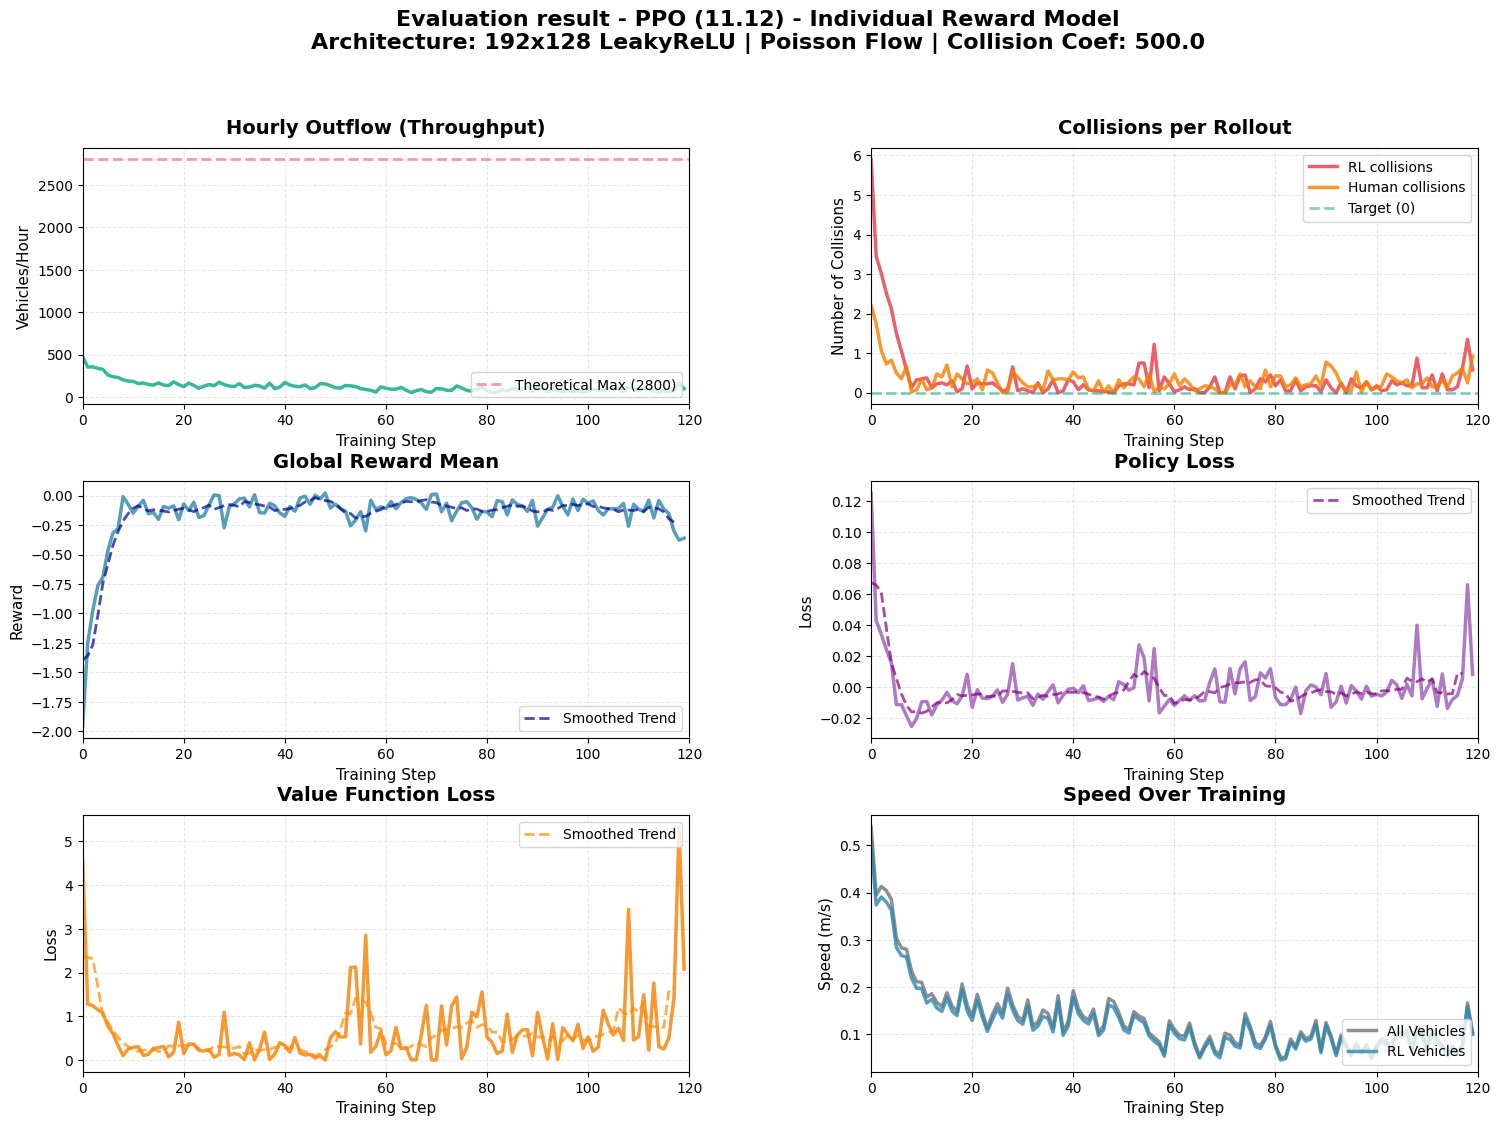


TRAINING SUMMARY - PPO (11.12)
Total Training Steps: 120

Final Metrics (Last 10 Steps Average):
--------------------------------------------------------------------------------
Hourly Outflow      :   88.290 veh/hr
Collisions          :    0.811 per rollout
Global Reward       :   -0.191 
Policy Loss         :    0.006 
Value Loss          :    1.489 
Speed (All)         :    0.091 m/s
Speed (RL)          :    0.086 m/s

Performance Indicators:
--------------------------------------------------------------------------------
Throughput Efficiency: 3.2% of theoretical max
Safety Score: NEEDS IMPROVEMENT (0.81 collisions)
Learning Stability: UNSTABLE (policy loss std: 0.0242)


In [2]:
# Load results
df = pd.read_csv('results/fourway_1x1_penetration0.5_turn_adam_ppo_11.12/train_results.csv')

# Calculate hourly outflow
def calculate_hourly_outflow(df, horizon=2000, sim_step=0.5):
    """Convert outflow per rollout to vehicles per hour"""
    simulation_time_seconds = horizon * sim_step
    simulation_time_hours = simulation_time_seconds / 3600
    df['outflow_hourly'] = df['outflow'] / simulation_time_hours
    return df

df = calculate_hourly_outflow(df.copy())

# Create comprehensive subplot figure
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# Define color scheme
colors = {
    'primary': '#2E86AB',
    'danger': '#E63946',
    'success': '#06A77D',
    'warning': '#F77F00',
    'info': '#9B59B6',
    'secondary': '#6C757D'
}

# --- Subplot 1: Hourly Outflow ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(df['step'], df['outflow_hourly'], linewidth=2.5, color=colors['success'], alpha=0.8)
ax1.axhline(y=2800, color=colors['danger'], linestyle='--', linewidth=2, alpha=0.5, label='Theoretical Max (2800)')
# ax1.fill_between(df['step'], 0, df['outflow_hourly'], alpha=0.2, color=colors['success'])
ax1.set_title('Hourly Outflow (Throughput)', fontsize=14, fontweight='bold', pad=10)
ax1.set_xlabel('Training Step', fontsize=11)
ax1.set_ylabel('Vehicles/Hour', fontsize=11)
ax1.legend(loc='lower right', fontsize=10)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_xlim(df['step'].min(), df['step'].max())

# Add annotation for final value
final_outflow = df['outflow_hourly'].iloc[-1]
ax1.annotate(f'Final: {final_outflow:.1f}', 
            xy=(df['step'].iloc[-1], final_outflow),
            xytext=(10, 10), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            fontsize=10, fontweight='bold')

# --- Subplot 2: Collisions ---
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(df['step'], df['collisions'] - df['collisions_human'], label = 'RL collisions', linewidth=2.5, color=colors['danger'], alpha=0.8)
ax2.plot(df['step'], df['collisions_human'], label = 'Human collisions', linewidth=2.5, color=colors['warning'], alpha=0.8)
# ax2.fill_between(df['step'], 0, df['collisions'], alpha=0.2, color=colors['danger'])
ax2.axhline(y=0, color=colors['success'], linestyle='--', linewidth=2, alpha=0.5, label='Target (0)')
ax2.set_title('Collisions per Rollout', fontsize=14, fontweight='bold', pad=10)
ax2.set_xlabel('Training Step', fontsize=11)
ax2.set_ylabel('Number of Collisions', fontsize=11)
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_xlim(df['step'].min(), df['step'].max())

# Add annotation for final value
final_collisions = df['collisions'].iloc[-1]
ax2.annotate(f'Final: {final_collisions:.2f}', 
            xy=(df['step'].iloc[-1], final_collisions),
            xytext=(10, -10), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            fontsize=10, fontweight='bold')

# --- Subplot 3: Global Reward Mean ---
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(df['step'], df['global_reward_mean'], linewidth=2.5, color=colors['primary'], alpha=0.8)
# ax3.fill_between(df['step'], df['global_reward_mean'].min(), df['global_reward_mean'], 
#                  alpha=0.2, color=colors['primary'])
ax3.set_title('Global Reward Mean', fontsize=14, fontweight='bold', pad=10)
ax3.set_xlabel('Training Step', fontsize=11)
ax3.set_ylabel('Reward', fontsize=11)
ax3.grid(True, alpha=0.3, linestyle='--')
ax3.set_xlim(df['step'].min(), df['step'].max())

# Add smoothed trend line
from scipy.ndimage import uniform_filter1d
window_size = max(5, len(df) // 20)
smoothed = uniform_filter1d(df['global_reward_mean'], size=window_size)
ax3.plot(df['step'], smoothed, linewidth=2, color='darkblue', linestyle='--', 
         alpha=0.7, label='Smoothed Trend')
ax3.legend(loc='lower right', fontsize=10)

# --- Subplot 4: Policy Loss ---
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(df['step'], df['policy_loss'], linewidth=2.5, color=colors['info'], alpha=0.8)
# ax4.fill_between(df['step'], 0, df['policy_loss'], alpha=0.2, color=colors['info'])
ax4.set_title('Policy Loss', fontsize=14, fontweight='bold', pad=10)
ax4.set_xlabel('Training Step', fontsize=11)
ax4.set_ylabel('Loss', fontsize=11)
ax4.grid(True, alpha=0.3, linestyle='--')
ax4.set_xlim(df['step'].min(), df['step'].max())

# Add smoothed trend line
smoothed_policy = uniform_filter1d(df['policy_loss'], size=window_size)
ax4.plot(df['step'], smoothed_policy, linewidth=2, color='purple', linestyle='--', 
         alpha=0.7, label='Smoothed Trend')
ax4.legend(loc='upper right', fontsize=10)

# --- Subplot 5: Value Function Loss ---
ax5 = fig.add_subplot(gs[2, 0])
ax5.plot(df['step'], df['value_loss'], linewidth=2.5, color=colors['warning'], alpha=0.8)
# ax5.fill_between(df['step'], 0, df['value_loss'], alpha=0.2, color=colors['warning'])
ax5.set_title('Value Function Loss', fontsize=14, fontweight='bold', pad=10)
ax5.set_xlabel('Training Step', fontsize=11)
ax5.set_ylabel('Loss', fontsize=11)
ax5.grid(True, alpha=0.3, linestyle='--')
ax5.set_xlim(df['step'].min(), df['step'].max())

# Add smoothed trend line
smoothed_value = uniform_filter1d(df['value_loss'], size=window_size)
ax5.plot(df['step'], smoothed_value, linewidth=2, color='darkorange', linestyle='--', 
         alpha=0.7, label='Smoothed Trend')
ax5.legend(loc='upper right', fontsize=10)

# --- Subplot 6: Speed Over Training ---
ax6 = fig.add_subplot(gs[2, 1])
ax6.plot(df['step'], df['speed'], label='All Vehicles', linewidth=2.5, 
         color=colors['secondary'], alpha=0.8)
ax6.plot(df['step'], df['speed_rl'], label='RL Vehicles', linewidth=2.5, 
         color=colors['primary'], alpha=0.8)
# ax6.fill_between(df['step'], df['speed'], alpha=0.1, color=colors['secondary'])
# ax6.fill_between(df['step'], df['speed_rl'], alpha=0.1, color=colors['primary'])
ax6.set_title('Speed Over Training', fontsize=14, fontweight='bold', pad=10)
ax6.set_xlabel('Training Step', fontsize=11)
ax6.set_ylabel('Speed (m/s)', fontsize=11)
ax6.legend(loc='lower right', fontsize=10)
ax6.grid(True, alpha=0.3, linestyle='--')
ax6.set_xlim(df['step'].min(), df['step'].max())

# Add annotation for final speeds
final_speed_all = df['speed'].iloc[-1]
final_speed_rl = df['speed_rl'].iloc[-1]
ax6.annotate(f'All: {final_speed_all:.2f} m/s\nRL: {final_speed_rl:.2f} m/s', 
            xy=(df['step'].iloc[-1], final_speed_rl),
            xytext=(-80, 20), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            fontsize=9, fontweight='bold')

# Add main title
fig.suptitle('Evaluation result - PPO (11.12) - Individual Reward Model\n' + 
             'Architecture: 192x128 LeakyReLU | Poisson Flow | Collision Coef: 500.0',
             fontsize=16, fontweight='bold', y=0.995)

plt.tight_layout()
plt.show()

# --- Print Summary Statistics ---
print("\n" + "="*80)
print("TRAINING SUMMARY - PPO (11.12)")
print("="*80)
print(f"Total Training Steps: {df['step'].max()}")
print(f"\nFinal Metrics (Last 10 Steps Average):")
print("-" * 80)

last_10 = df.tail(10)

metrics = {
    'Hourly Outflow': (last_10['outflow_hourly'].mean(), 'veh/hr'),
    'Collisions': (last_10['collisions'].mean(), 'per rollout'),
    'Global Reward': (last_10['global_reward_mean'].mean(), ''),
    'Policy Loss': (last_10['policy_loss'].mean(), ''),
    'Value Loss': (last_10['value_loss'].mean(), ''),
    'Speed (All)': (last_10['speed'].mean(), 'm/s'),
    'Speed (RL)': (last_10['speed_rl'].mean(), 'm/s'),
}

for metric, (value, unit) in metrics.items():
    print(f"{metric:20s}: {value:8.3f} {unit}")

print("\nPerformance Indicators:")
print("-" * 80)
efficiency = (last_10['outflow_hourly'].mean() / 2800) * 100
print(f"Throughput Efficiency: {efficiency:.1f}% of theoretical max")
print(f"Safety Score: {'EXCELLENT' if last_10['collisions'].mean() < 0.5 else 'NEEDS IMPROVEMENT'} ({last_10['collisions'].mean():.2f} collisions)")
print(f"Learning Stability: {'STABLE' if last_10['policy_loss'].std() < 0.01 else 'UNSTABLE'} (policy loss std: {last_10['policy_loss'].std():.4f})")
print("="*80)

# 12.12 

Add 1 more observation feature to observation space: distance between vehicle
Change collision penalty back to 50
Change batch size to 32


/tmp/ipykernel_31520/2981916260.py:149: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


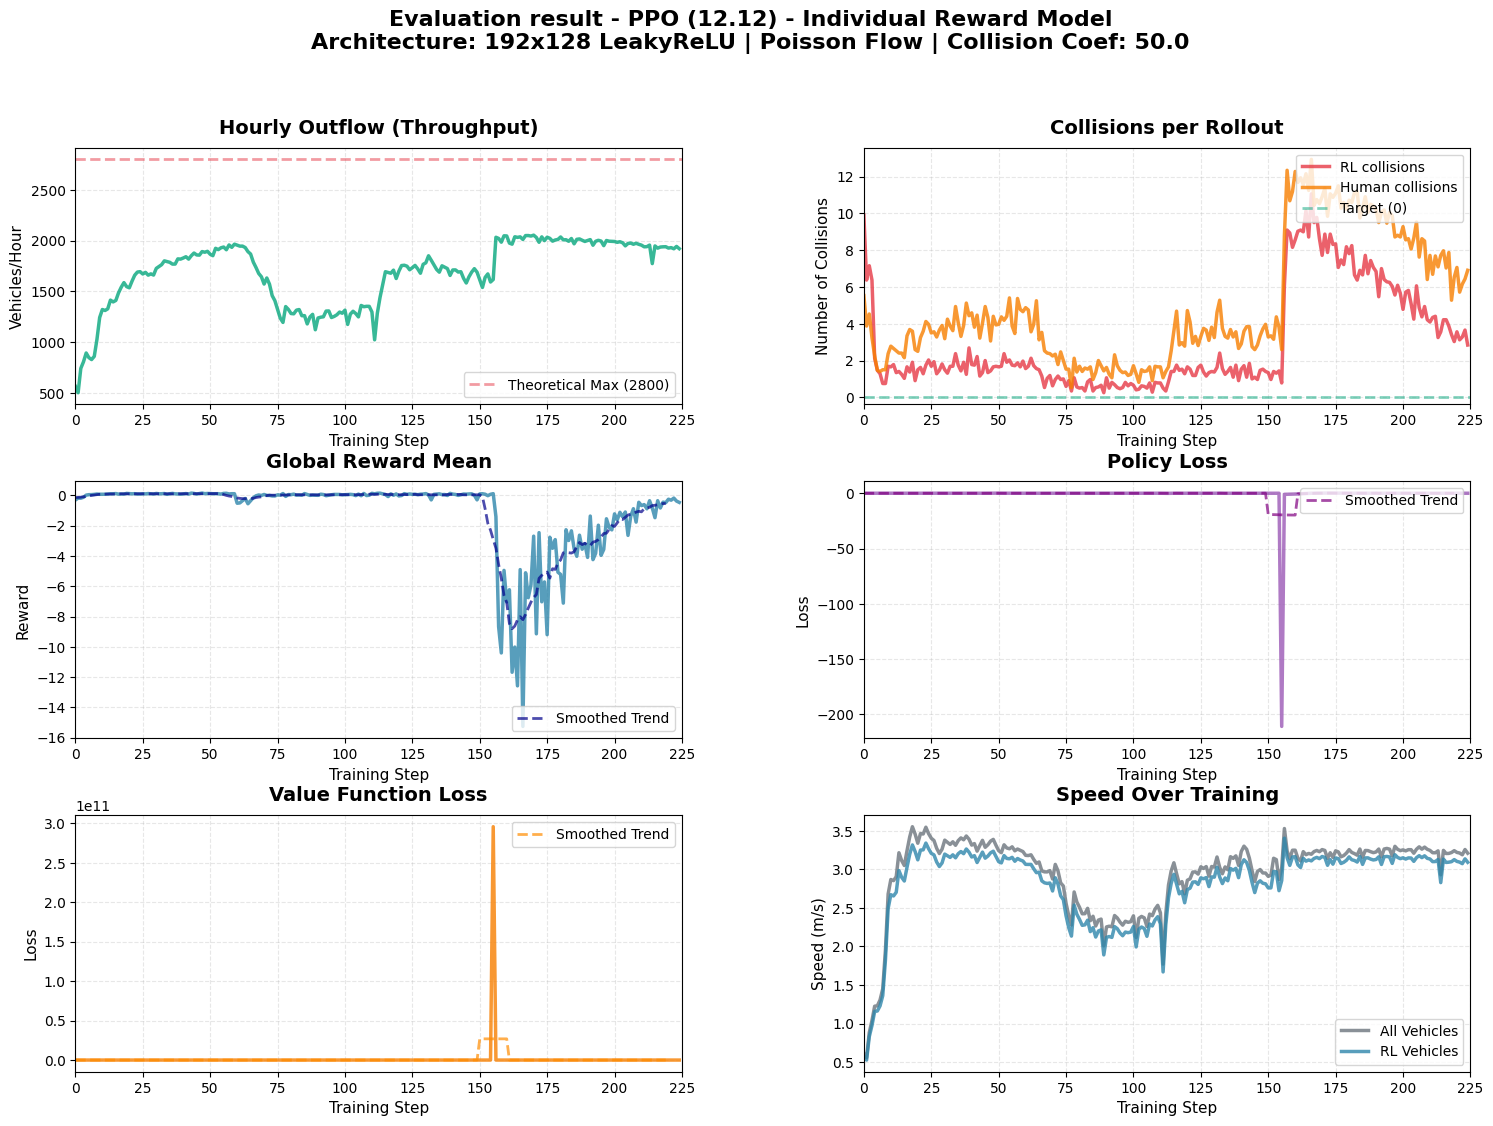


TRAINING SUMMARY - PPO (12.12)
Total Training Steps: 225

Final Metrics (Last 10 Steps Average):
--------------------------------------------------------------------------------
Hourly Outflow      : 1931.062 veh/hr
Collisions          :   10.000 per rollout
Global Reward       :   -0.414 
Policy Loss         :   -0.007 
Value Loss          :    0.431 
Speed (All)         :    3.220 m/s
Speed (RL)          :    3.103 m/s

Performance Indicators:
--------------------------------------------------------------------------------
Throughput Efficiency: 69.0% of theoretical max
Safety Score: NEEDS IMPROVEMENT (10.00 collisions)
Learning Stability: UNSTABLE (policy loss std: 0.0108)


In [20]:
# Load results
df = pd.read_csv('results/fourway_1x1_penetration0.5_turn_adam_ppo_12.12/train_results.csv')

# Calculate hourly outflow
def calculate_hourly_outflow(df, horizon=2000, sim_step=0.5):
    """Convert outflow per rollout to vehicles per hour"""
    simulation_time_seconds = horizon * sim_step
    simulation_time_hours = simulation_time_seconds / 3600
    df['outflow_hourly'] = df['outflow'] / simulation_time_hours
    return df

df = calculate_hourly_outflow(df.copy())

# Create comprehensive subplot figure
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# Define color scheme
colors = {
    'primary': '#2E86AB',
    'danger': '#E63946',
    'success': '#06A77D',
    'warning': '#F77F00',
    'info': '#9B59B6',
    'secondary': '#6C757D'
}

# --- Subplot 1: Hourly Outflow ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(df['step'], df['outflow_hourly'], linewidth=2.5, color=colors['success'], alpha=0.8)
ax1.axhline(y=2800, color=colors['danger'], linestyle='--', linewidth=2, alpha=0.5, label='Theoretical Max (2800)')
# ax1.fill_between(df['step'], 0, df['outflow_hourly'], alpha=0.2, color=colors['success'])
ax1.set_title('Hourly Outflow (Throughput)', fontsize=14, fontweight='bold', pad=10)
ax1.set_xlabel('Training Step', fontsize=11)
ax1.set_ylabel('Vehicles/Hour', fontsize=11)
ax1.legend(loc='lower right', fontsize=10)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_xlim(df['step'].min(), df['step'].max())

# Add annotation for final value
final_outflow = df['outflow_hourly'].iloc[-1]
ax1.annotate(f'Final: {final_outflow:.1f}', 
            xy=(df['step'].iloc[-1], final_outflow),
            xytext=(10, 10), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            fontsize=10, fontweight='bold')

# --- Subplot 2: Collisions ---
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(df['step'], df['collisions'] - df['collisions_human'], label = 'RL collisions', linewidth=2.5, color=colors['danger'], alpha=0.8)
ax2.plot(df['step'], df['collisions_human'], label = 'Human collisions', linewidth=2.5, color=colors['warning'], alpha=0.8)
# ax2.fill_between(df['step'], 0, df['collisions'], alpha=0.2, color=colors['danger'])
ax2.axhline(y=0, color=colors['success'], linestyle='--', linewidth=2, alpha=0.5, label='Target (0)')
ax2.set_title('Collisions per Rollout', fontsize=14, fontweight='bold', pad=10)
ax2.set_xlabel('Training Step', fontsize=11)
ax2.set_ylabel('Number of Collisions', fontsize=11)
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_xlim(df['step'].min(), df['step'].max())

# Add annotation for final value
final_collisions = df['collisions'].iloc[-1]
ax2.annotate(f'Final: {final_collisions:.2f}', 
            xy=(df['step'].iloc[-1], final_collisions),
            xytext=(10, -10), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            fontsize=10, fontweight='bold')

# --- Subplot 3: Global Reward Mean ---
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(df['step'], df['global_reward_mean'], linewidth=2.5, color=colors['primary'], alpha=0.8)
# ax3.fill_between(df['step'], df['global_reward_mean'].min(), df['global_reward_mean'], 
#                  alpha=0.2, color=colors['primary'])
ax3.set_title('Global Reward Mean', fontsize=14, fontweight='bold', pad=10)
ax3.set_xlabel('Training Step', fontsize=11)
ax3.set_ylabel('Reward', fontsize=11)
ax3.grid(True, alpha=0.3, linestyle='--')
ax3.set_xlim(df['step'].min(), df['step'].max())

# Add smoothed trend line
from scipy.ndimage import uniform_filter1d
window_size = max(5, len(df) // 20)
smoothed = uniform_filter1d(df['global_reward_mean'], size=window_size)
ax3.plot(df['step'], smoothed, linewidth=2, color='darkblue', linestyle='--', 
         alpha=0.7, label='Smoothed Trend')
ax3.legend(loc='lower right', fontsize=10)

# --- Subplot 4: Policy Loss ---
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(df['step'], df['policy_loss'], linewidth=2.5, color=colors['info'], alpha=0.8)
# ax4.fill_between(df['step'], 0, df['policy_loss'], alpha=0.2, color=colors['info'])
ax4.set_title('Policy Loss', fontsize=14, fontweight='bold', pad=10)
ax4.set_xlabel('Training Step', fontsize=11)
ax4.set_ylabel('Loss', fontsize=11)
ax4.grid(True, alpha=0.3, linestyle='--')
ax4.set_xlim(df['step'].min(), df['step'].max())

# Add smoothed trend line
smoothed_policy = uniform_filter1d(df['policy_loss'], size=window_size)
ax4.plot(df['step'], smoothed_policy, linewidth=2, color='purple', linestyle='--', 
         alpha=0.7, label='Smoothed Trend')
ax4.legend(loc='upper right', fontsize=10)

# --- Subplot 5: Value Function Loss ---
ax5 = fig.add_subplot(gs[2, 0])
ax5.plot(df['step'], df['value_loss'], linewidth=2.5, color=colors['warning'], alpha=0.8)
# ax5.fill_between(df['step'], 0, df['value_loss'], alpha=0.2, color=colors['warning'])
ax5.set_title('Value Function Loss', fontsize=14, fontweight='bold', pad=10)
ax5.set_xlabel('Training Step', fontsize=11)
ax5.set_ylabel('Loss', fontsize=11)
ax5.grid(True, alpha=0.3, linestyle='--')
ax5.set_xlim(df['step'].min(), df['step'].max())

# Add smoothed trend line
smoothed_value = uniform_filter1d(df['value_loss'], size=window_size)
ax5.plot(df['step'], smoothed_value, linewidth=2, color='darkorange', linestyle='--', 
         alpha=0.7, label='Smoothed Trend')
ax5.legend(loc='upper right', fontsize=10)

# --- Subplot 6: Speed Over Training ---
ax6 = fig.add_subplot(gs[2, 1])
ax6.plot(df['step'], df['speed'], label='All Vehicles', linewidth=2.5, 
         color=colors['secondary'], alpha=0.8)
ax6.plot(df['step'], df['speed_rl'], label='RL Vehicles', linewidth=2.5, 
         color=colors['primary'], alpha=0.8)
# ax6.fill_between(df['step'], df['speed'], alpha=0.1, color=colors['secondary'])
# ax6.fill_between(df['step'], df['speed_rl'], alpha=0.1, color=colors['primary'])
ax6.set_title('Speed Over Training', fontsize=14, fontweight='bold', pad=10)
ax6.set_xlabel('Training Step', fontsize=11)
ax6.set_ylabel('Speed (m/s)', fontsize=11)
ax6.legend(loc='lower right', fontsize=10)
ax6.grid(True, alpha=0.3, linestyle='--')
ax6.set_xlim(df['step'].min(), df['step'].max())

# Add annotation for final speeds
final_speed_all = df['speed'].iloc[-1]
final_speed_rl = df['speed_rl'].iloc[-1]
ax6.annotate(f'All: {final_speed_all:.2f} m/s\nRL: {final_speed_rl:.2f} m/s', 
            xy=(df['step'].iloc[-1], final_speed_rl),
            xytext=(-80, 20), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            fontsize=9, fontweight='bold')

# Add main title
fig.suptitle('Evaluation result - PPO (12.12) - Individual Reward Model\n' + 
             'Architecture: 192x128 LeakyReLU | Poisson Flow | Collision Coef: 50.0',
             fontsize=16, fontweight='bold', y=0.995)

plt.tight_layout()
plt.show()

# --- Print Summary Statistics ---
print("\n" + "="*80)
print("TRAINING SUMMARY - PPO (12.12)")
print("="*80)
print(f"Total Training Steps: {df['step'].max()}")
print(f"\nFinal Metrics (Last 10 Steps Average):")
print("-" * 80)

last_10 = df.tail(10)

metrics = {
    'Hourly Outflow': (last_10['outflow_hourly'].mean(), 'veh/hr'),
    'Collisions': (last_10['collisions'].mean(), 'per rollout'),
    'Global Reward': (last_10['global_reward_mean'].mean(), ''),
    'Policy Loss': (last_10['policy_loss'].mean(), ''),
    'Value Loss': (last_10['value_loss'].mean(), ''),
    'Speed (All)': (last_10['speed'].mean(), 'm/s'),
    'Speed (RL)': (last_10['speed_rl'].mean(), 'm/s'),
}

for metric, (value, unit) in metrics.items():
    print(f"{metric:20s}: {value:8.3f} {unit}")

print("\nPerformance Indicators:")
print("-" * 80)
efficiency = (last_10['outflow_hourly'].mean() / 2800) * 100
print(f"Throughput Efficiency: {efficiency:.1f}% of theoretical max")
print(f"Safety Score: {'EXCELLENT' if last_10['collisions'].mean() < 0.5 else 'NEEDS IMPROVEMENT'} ({last_10['collisions'].mean():.2f} collisions)")
print(f"Learning Stability: {'STABLE' if last_10['policy_loss'].std() < 0.01 else 'UNSTABLE'} (policy loss std: {last_10['policy_loss'].std():.4f})")
print("="*80)


# 12.12
av_frac = 1

/tmp/ipykernel_1096/1225905043.py:149: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


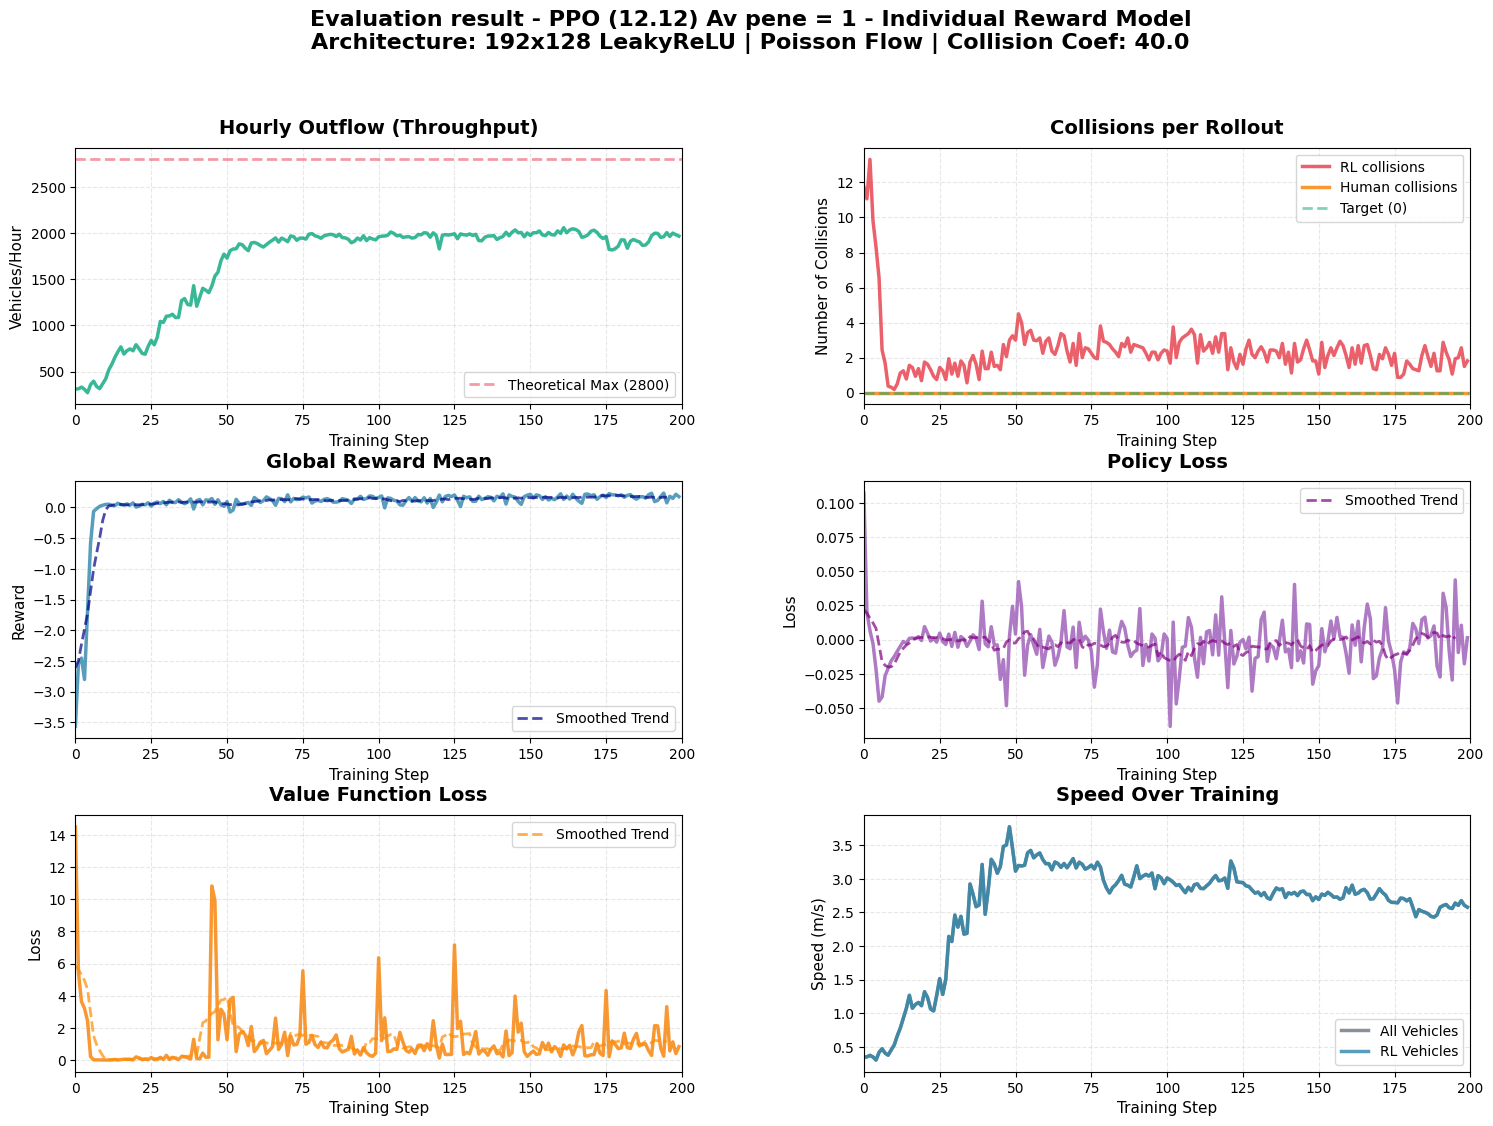


TRAINING SUMMARY - PPO (12.12) AV pene = 1
Total Training Steps: 200

Final Metrics (Last 10 Steps Average):
--------------------------------------------------------------------------------
Hourly Outflow      : 1981.900 veh/hr
Collisions          :    1.993 per rollout
Global Reward       :    0.157 
Policy Loss         :    0.005 
Value Loss          :    1.281 
Speed (All)         :    2.607 m/s
Speed (RL)          :    2.607 m/s

Performance Indicators:
--------------------------------------------------------------------------------
Throughput Efficiency: 70.8% of theoretical max
Safety Score: NEEDS IMPROVEMENT (1.99 collisions)
Learning Stability: UNSTABLE (policy loss std: 0.0245)


In [14]:
# Load results
df = pd.read_csv('results/fourway_1x1_penetration1_turn_adam_ppo_12.12/train_results.csv')

# Calculate hourly outflow
def calculate_hourly_outflow(df, horizon=2000, sim_step=0.5):
    """Convert outflow per rollout to vehicles per hour"""
    simulation_time_seconds = horizon * sim_step
    simulation_time_hours = simulation_time_seconds / 3600
    df['outflow_hourly'] = df['outflow'] / simulation_time_hours
    return df

df = calculate_hourly_outflow(df.copy())

# Create comprehensive subplot figure
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# Define color scheme
colors = {
    'primary': '#2E86AB',
    'danger': '#E63946',
    'success': '#06A77D',
    'warning': '#F77F00',
    'info': '#9B59B6',
    'secondary': '#6C757D'
}

# --- Subplot 1: Hourly Outflow ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(df['step'], df['outflow_hourly'], linewidth=2.5, color=colors['success'], alpha=0.8)
ax1.axhline(y=2800, color=colors['danger'], linestyle='--', linewidth=2, alpha=0.5, label='Theoretical Max (2800)')
# ax1.fill_between(df['step'], 0, df['outflow_hourly'], alpha=0.2, color=colors['success'])
ax1.set_title('Hourly Outflow (Throughput)', fontsize=14, fontweight='bold', pad=10)
ax1.set_xlabel('Training Step', fontsize=11)
ax1.set_ylabel('Vehicles/Hour', fontsize=11)
ax1.legend(loc='lower right', fontsize=10)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_xlim(df['step'].min(), df['step'].max())

# Add annotation for final value
final_outflow = df['outflow_hourly'].iloc[-1]
ax1.annotate(f'Final: {final_outflow:.1f}', 
            xy=(df['step'].iloc[-1], final_outflow),
            xytext=(10, 10), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            fontsize=10, fontweight='bold')

# --- Subplot 2: Collisions ---
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(df['step'], df['collisions'] - df['collisions_human'], label = 'RL collisions', linewidth=2.5, color=colors['danger'], alpha=0.8)
ax2.plot(df['step'], df['collisions_human'], label = 'Human collisions', linewidth=2.5, color=colors['warning'], alpha=0.8)
# ax2.fill_between(df['step'], 0, df['collisions'], alpha=0.2, color=colors['danger'])
ax2.axhline(y=0, color=colors['success'], linestyle='--', linewidth=2, alpha=0.5, label='Target (0)')
ax2.set_title('Collisions per Rollout', fontsize=14, fontweight='bold', pad=10)
ax2.set_xlabel('Training Step', fontsize=11)
ax2.set_ylabel('Number of Collisions', fontsize=11)
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_xlim(df['step'].min(), df['step'].max())

# Add annotation for final value
final_collisions = df['collisions'].iloc[-1]
ax2.annotate(f'Final: {final_collisions:.2f}', 
            xy=(df['step'].iloc[-1], final_collisions),
            xytext=(10, -10), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            fontsize=10, fontweight='bold')

# --- Subplot 3: Global Reward Mean ---
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(df['step'], df['global_reward_mean'], linewidth=2.5, color=colors['primary'], alpha=0.8)
# ax3.fill_between(df['step'], df['global_reward_mean'].min(), df['global_reward_mean'], 
#                  alpha=0.2, color=colors['primary'])
ax3.set_title('Global Reward Mean', fontsize=14, fontweight='bold', pad=10)
ax3.set_xlabel('Training Step', fontsize=11)
ax3.set_ylabel('Reward', fontsize=11)
ax3.grid(True, alpha=0.3, linestyle='--')
ax3.set_xlim(df['step'].min(), df['step'].max())

# Add smoothed trend line
from scipy.ndimage import uniform_filter1d
window_size = max(5, len(df) // 20)
smoothed = uniform_filter1d(df['global_reward_mean'], size=window_size)
ax3.plot(df['step'], smoothed, linewidth=2, color='darkblue', linestyle='--', 
         alpha=0.7, label='Smoothed Trend')
ax3.legend(loc='lower right', fontsize=10)

# --- Subplot 4: Policy Loss ---
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(df['step'], df['policy_loss'], linewidth=2.5, color=colors['info'], alpha=0.8)
# ax4.fill_between(df['step'], 0, df['policy_loss'], alpha=0.2, color=colors['info'])
ax4.set_title('Policy Loss', fontsize=14, fontweight='bold', pad=10)
ax4.set_xlabel('Training Step', fontsize=11)
ax4.set_ylabel('Loss', fontsize=11)
ax4.grid(True, alpha=0.3, linestyle='--')
ax4.set_xlim(df['step'].min(), df['step'].max())

# Add smoothed trend line
smoothed_policy = uniform_filter1d(df['policy_loss'], size=window_size)
ax4.plot(df['step'], smoothed_policy, linewidth=2, color='purple', linestyle='--', 
         alpha=0.7, label='Smoothed Trend')
ax4.legend(loc='upper right', fontsize=10)

# --- Subplot 5: Value Function Loss ---
ax5 = fig.add_subplot(gs[2, 0])
ax5.plot(df['step'], df['value_loss'], linewidth=2.5, color=colors['warning'], alpha=0.8)
# ax5.fill_between(df['step'], 0, df['value_loss'], alpha=0.2, color=colors['warning'])
ax5.set_title('Value Function Loss', fontsize=14, fontweight='bold', pad=10)
ax5.set_xlabel('Training Step', fontsize=11)
ax5.set_ylabel('Loss', fontsize=11)
ax5.grid(True, alpha=0.3, linestyle='--')
ax5.set_xlim(df['step'].min(), df['step'].max())

# Add smoothed trend line
smoothed_value = uniform_filter1d(df['value_loss'], size=window_size)
ax5.plot(df['step'], smoothed_value, linewidth=2, color='darkorange', linestyle='--', 
         alpha=0.7, label='Smoothed Trend')
ax5.legend(loc='upper right', fontsize=10)

# --- Subplot 6: Speed Over Training ---
ax6 = fig.add_subplot(gs[2, 1])
ax6.plot(df['step'], df['speed'], label='All Vehicles', linewidth=2.5, 
         color=colors['secondary'], alpha=0.8)
ax6.plot(df['step'], df['speed_rl'], label='RL Vehicles', linewidth=2.5, 
         color=colors['primary'], alpha=0.8)
# ax6.fill_between(df['step'], df['speed'], alpha=0.1, color=colors['secondary'])
# ax6.fill_between(df['step'], df['speed_rl'], alpha=0.1, color=colors['primary'])
ax6.set_title('Speed Over Training', fontsize=14, fontweight='bold', pad=10)
ax6.set_xlabel('Training Step', fontsize=11)
ax6.set_ylabel('Speed (m/s)', fontsize=11)
ax6.legend(loc='lower right', fontsize=10)
ax6.grid(True, alpha=0.3, linestyle='--')
ax6.set_xlim(df['step'].min(), df['step'].max())

# Add annotation for final speeds
final_speed_all = df['speed'].iloc[-1]
final_speed_rl = df['speed_rl'].iloc[-1]
ax6.annotate(f'All: {final_speed_all:.2f} m/s\nRL: {final_speed_rl:.2f} m/s', 
            xy=(df['step'].iloc[-1], final_speed_rl),
            xytext=(-80, 20), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            fontsize=9, fontweight='bold')

# Add main title
fig.suptitle('Evaluation result - PPO (12.12) Av pene = 1 - Individual Reward Model\n' + 
             'Architecture: 192x128 LeakyReLU | Poisson Flow | Collision Coef: 40.0',
             fontsize=16, fontweight='bold', y=0.995)

plt.tight_layout()
plt.show()

# --- Print Summary Statistics ---
print("\n" + "="*80)
print("TRAINING SUMMARY - PPO (12.12) AV pene = 1")
print("="*80)
print(f"Total Training Steps: {df['step'].max()}")
print(f"\nFinal Metrics (Last 10 Steps Average):")
print("-" * 80)

last_10 = df.tail(10)

metrics = {
    'Hourly Outflow': (last_10['outflow_hourly'].mean(), 'veh/hr'),
    'Collisions': (last_10['collisions'].mean(), 'per rollout'),
    'Global Reward': (last_10['global_reward_mean'].mean(), ''),
    'Policy Loss': (last_10['policy_loss'].mean(), ''),
    'Value Loss': (last_10['value_loss'].mean(), ''),
    'Speed (All)': (last_10['speed'].mean(), 'm/s'),
    'Speed (RL)': (last_10['speed_rl'].mean(), 'm/s'),
}

for metric, (value, unit) in metrics.items():
    print(f"{metric:20s}: {value:8.3f} {unit}")

print("\nPerformance Indicators:")
print("-" * 80)
efficiency = (last_10['outflow_hourly'].mean() / 2800) * 100
print(f"Throughput Efficiency: {efficiency:.1f}% of theoretical max")
print(f"Safety Score: {'EXCELLENT' if last_10['collisions'].mean() < 0.5 else 'NEEDS IMPROVEMENT'} ({last_10['collisions'].mean():.2f} collisions)")
print(f"Learning Stability: {'STABLE' if last_10['policy_loss'].std() < 0.01 else 'UNSTABLE'} (policy loss std: {last_10['policy_loss'].std():.4f})")
print("="*80)


# 14.12 
Take best model from pene 1 to train pene 0.5


/tmp/ipykernel_1045/4239725196.py:150: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


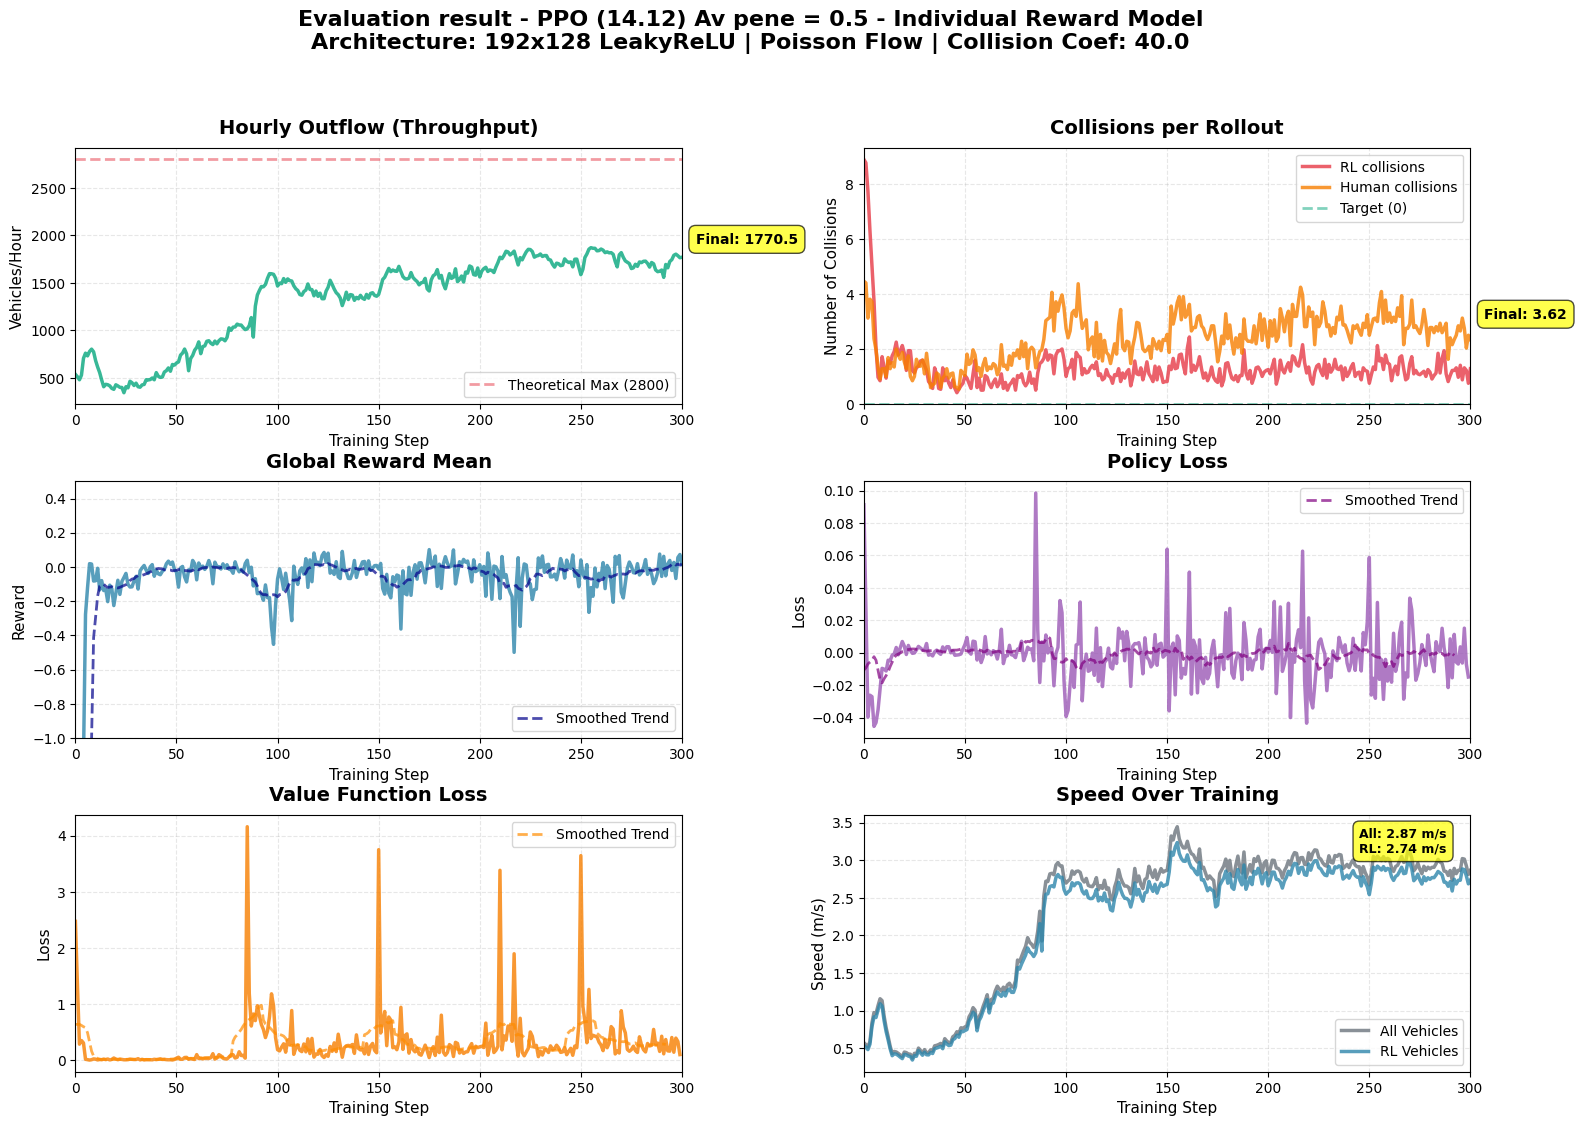


TRAINING SUMMARY - PPO (14.12) AV pene = 0.5
Total Training Steps: 300

Final Metrics (Last 10 Steps Average):
--------------------------------------------------------------------------------
Hourly Outflow      : 1730.037 veh/hr
Collisions          :    3.681 per rollout
Global Reward       :    0.015 
Policy Loss         :   -0.003 
Value Loss          :    0.243 
Speed (All)         :    2.882 m/s
Speed (RL)          :    2.747 m/s

Performance Indicators:
--------------------------------------------------------------------------------
Throughput Efficiency: 61.8% of theoretical max
Safety Score: NEEDS IMPROVEMENT (3.68 collisions)
Learning Stability: UNSTABLE (policy loss std: 0.0108)


In [8]:
# Load results
df = pd.read_csv('results/fourway_1x1_penetration0.5_turn_adam_ppo_14.12/train_results.csv')

# Calculate hourly outflow
def calculate_hourly_outflow(df, horizon=2000, sim_step=0.5):
    """Convert outflow per rollout to vehicles per hour"""
    simulation_time_seconds = horizon * sim_step
    simulation_time_hours = simulation_time_seconds / 3600
    df['outflow_hourly'] = df['outflow'] / simulation_time_hours
    return df

df = calculate_hourly_outflow(df.copy())

# Create comprehensive subplot figure
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# Define color scheme
colors = {
    'primary': '#2E86AB',
    'danger': '#E63946',
    'success': '#06A77D',
    'warning': '#F77F00',
    'info': '#9B59B6',
    'secondary': '#6C757D'
}

# --- Subplot 1: Hourly Outflow ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(df['step'], df['outflow_hourly'], linewidth=2.5, color=colors['success'], alpha=0.8)
ax1.axhline(y=2800, color=colors['danger'], linestyle='--', linewidth=2, alpha=0.5, label='Theoretical Max (2800)')
# ax1.fill_between(df['step'], 0, df['outflow_hourly'], alpha=0.2, color=colors['success'])
ax1.set_title('Hourly Outflow (Throughput)', fontsize=14, fontweight='bold', pad=10)
ax1.set_xlabel('Training Step', fontsize=11)
ax1.set_ylabel('Vehicles/Hour', fontsize=11)
ax1.legend(loc='lower right', fontsize=10)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_xlim(df['step'].min(), df['step'].max())

# Add annotation for final value
final_outflow = df['outflow_hourly'].iloc[-1]
ax1.annotate(f'Final: {final_outflow:.1f}', 
            xy=(df['step'].iloc[-1], final_outflow),
            xytext=(10, 10), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            fontsize=10, fontweight='bold')

# --- Subplot 2: Collisions ---
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(df['step'], df['collisions'] - df['collisions_human'], label = 'RL collisions', linewidth=2.5, color=colors['danger'], alpha=0.8)
ax2.plot(df['step'], df['collisions_human'], label = 'Human collisions', linewidth=2.5, color=colors['warning'], alpha=0.8)
# ax2.fill_between(df['step'], 0, df['collisions'], alpha=0.2, color=colors['danger'])
ax2.axhline(y=0, color=colors['success'], linestyle='--', linewidth=2, alpha=0.5, label='Target (0)')
ax2.set_title('Collisions per Rollout', fontsize=14, fontweight='bold', pad=10)
ax2.set_xlabel('Training Step', fontsize=11)
ax2.set_ylabel('Number of Collisions', fontsize=11)
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_xlim(df['step'].min(), df['step'].max())

# Add annotation for final value
final_collisions = df['collisions'].iloc[-1]
ax2.annotate(f'Final: {final_collisions:.2f}', 
            xy=(df['step'].iloc[-1], final_collisions),
            xytext=(10, -10), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            fontsize=10, fontweight='bold')

# --- Subplot 3: Global Reward Mean ---
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(df['step'], df['global_reward_mean'], linewidth=2.5, color=colors['primary'], alpha=0.8)
# ax3.fill_between(df['step'], df['global_reward_mean'].min(), df['global_reward_mean'], 
#                  alpha=0.2, color=colors['primary'])
ax3.set_title('Global Reward Mean', fontsize=14, fontweight='bold', pad=10)
ax3.set_xlabel('Training Step', fontsize=11)
ax3.set_ylabel('Reward', fontsize=11)
ax3.grid(True, alpha=0.3, linestyle='--')
ax3.set_xlim(df['step'].min(), df['step'].max())
ax3.set_ylim(-1, 0.5)

# Add smoothed trend line
from scipy.ndimage import uniform_filter1d
window_size = max(5, len(df) // 20)
smoothed = uniform_filter1d(df['global_reward_mean'], size=window_size)
ax3.plot(df['step'], smoothed, linewidth=2, color='darkblue', linestyle='--', 
         alpha=0.7, label='Smoothed Trend')
ax3.legend(loc='lower right', fontsize=10)

# --- Subplot 4: Policy Loss ---
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(df['step'], df['policy_loss'], linewidth=2.5, color=colors['info'], alpha=0.8)
# ax4.fill_between(df['step'], 0, df['policy_loss'], alpha=0.2, color=colors['info'])
ax4.set_title('Policy Loss', fontsize=14, fontweight='bold', pad=10)
ax4.set_xlabel('Training Step', fontsize=11)
ax4.set_ylabel('Loss', fontsize=11)
ax4.grid(True, alpha=0.3, linestyle='--')
ax4.set_xlim(df['step'].min(), df['step'].max())

# Add smoothed trend line
smoothed_policy = uniform_filter1d(df['policy_loss'], size=window_size)
ax4.plot(df['step'], smoothed_policy, linewidth=2, color='purple', linestyle='--', 
         alpha=0.7, label='Smoothed Trend')
ax4.legend(loc='upper right', fontsize=10)

# --- Subplot 5: Value Function Loss ---
ax5 = fig.add_subplot(gs[2, 0])
ax5.plot(df['step'], df['value_loss'], linewidth=2.5, color=colors['warning'], alpha=0.8)
# ax5.fill_between(df['step'], 0, df['value_loss'], alpha=0.2, color=colors['warning'])
ax5.set_title('Value Function Loss', fontsize=14, fontweight='bold', pad=10)
ax5.set_xlabel('Training Step', fontsize=11)
ax5.set_ylabel('Loss', fontsize=11)
ax5.grid(True, alpha=0.3, linestyle='--')
ax5.set_xlim(df['step'].min(), df['step'].max())

# Add smoothed trend line
smoothed_value = uniform_filter1d(df['value_loss'], size=window_size)
ax5.plot(df['step'], smoothed_value, linewidth=2, color='darkorange', linestyle='--', 
         alpha=0.7, label='Smoothed Trend')
ax5.legend(loc='upper right', fontsize=10)

# --- Subplot 6: Speed Over Training ---
ax6 = fig.add_subplot(gs[2, 1])
ax6.plot(df['step'], df['speed'], label='All Vehicles', linewidth=2.5, 
         color=colors['secondary'], alpha=0.8)
ax6.plot(df['step'], df['speed_rl'], label='RL Vehicles', linewidth=2.5, 
         color=colors['primary'], alpha=0.8)
# ax6.fill_between(df['step'], df['speed'], alpha=0.1, color=colors['secondary'])
# ax6.fill_between(df['step'], df['speed_rl'], alpha=0.1, color=colors['primary'])
ax6.set_title('Speed Over Training', fontsize=14, fontweight='bold', pad=10)
ax6.set_xlabel('Training Step', fontsize=11)
ax6.set_ylabel('Speed (m/s)', fontsize=11)
ax6.legend(loc='lower right', fontsize=10)
ax6.grid(True, alpha=0.3, linestyle='--')
ax6.set_xlim(df['step'].min(), df['step'].max())

# Add annotation for final speeds
final_speed_all = df['speed'].iloc[-1]
final_speed_rl = df['speed_rl'].iloc[-1]
ax6.annotate(f'All: {final_speed_all:.2f} m/s\nRL: {final_speed_rl:.2f} m/s', 
            xy=(df['step'].iloc[-1], final_speed_rl),
            xytext=(-80, 20), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            fontsize=9, fontweight='bold')

# Add main title
fig.suptitle('Evaluation result - PPO (14.12) Av pene = 0.5 - Individual Reward Model\n' + 
             'Architecture: 192x128 LeakyReLU | Poisson Flow | Collision Coef: 40.0',
             fontsize=16, fontweight='bold', y=0.995)

plt.tight_layout()
plt.show()

# --- Print Summary Statistics ---
print("\n" + "="*80)
print("TRAINING SUMMARY - PPO (14.12) AV pene = 0.5")
print("="*80)
print(f"Total Training Steps: {df['step'].max()}")
print(f"\nFinal Metrics (Last 10 Steps Average):")
print("-" * 80)

last_10 = df.tail(10)

metrics = {
    'Hourly Outflow': (last_10['outflow_hourly'].mean(), 'veh/hr'),
    'Collisions': (last_10['collisions'].mean(), 'per rollout'),
    'Global Reward': (last_10['global_reward_mean'].mean(), ''),
    'Policy Loss': (last_10['policy_loss'].mean(), ''),
    'Value Loss': (last_10['value_loss'].mean(), ''),
    'Speed (All)': (last_10['speed'].mean(), 'm/s'),
    'Speed (RL)': (last_10['speed_rl'].mean(), 'm/s'),
}

for metric, (value, unit) in metrics.items():
    print(f"{metric:20s}: {value:8.3f} {unit}")

print("\nPerformance Indicators:")
print("-" * 80)
efficiency = (last_10['outflow_hourly'].mean() / 2800) * 100
print(f"Throughput Efficiency: {efficiency:.1f}% of theoretical max")
print(f"Safety Score: {'EXCELLENT' if last_10['collisions'].mean() < 0.5 else 'NEEDS IMPROVEMENT'} ({last_10['collisions'].mean():.2f} collisions)")
print(f"Learning Stability: {'STABLE' if last_10['policy_loss'].std() < 0.01 else 'UNSTABLE'} (policy loss std: {last_10['policy_loss'].std():.4f})")
print("="*80)


# 15.12

av frac = 0.333

/tmp/ipykernel_1045/1246294405.py:150: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


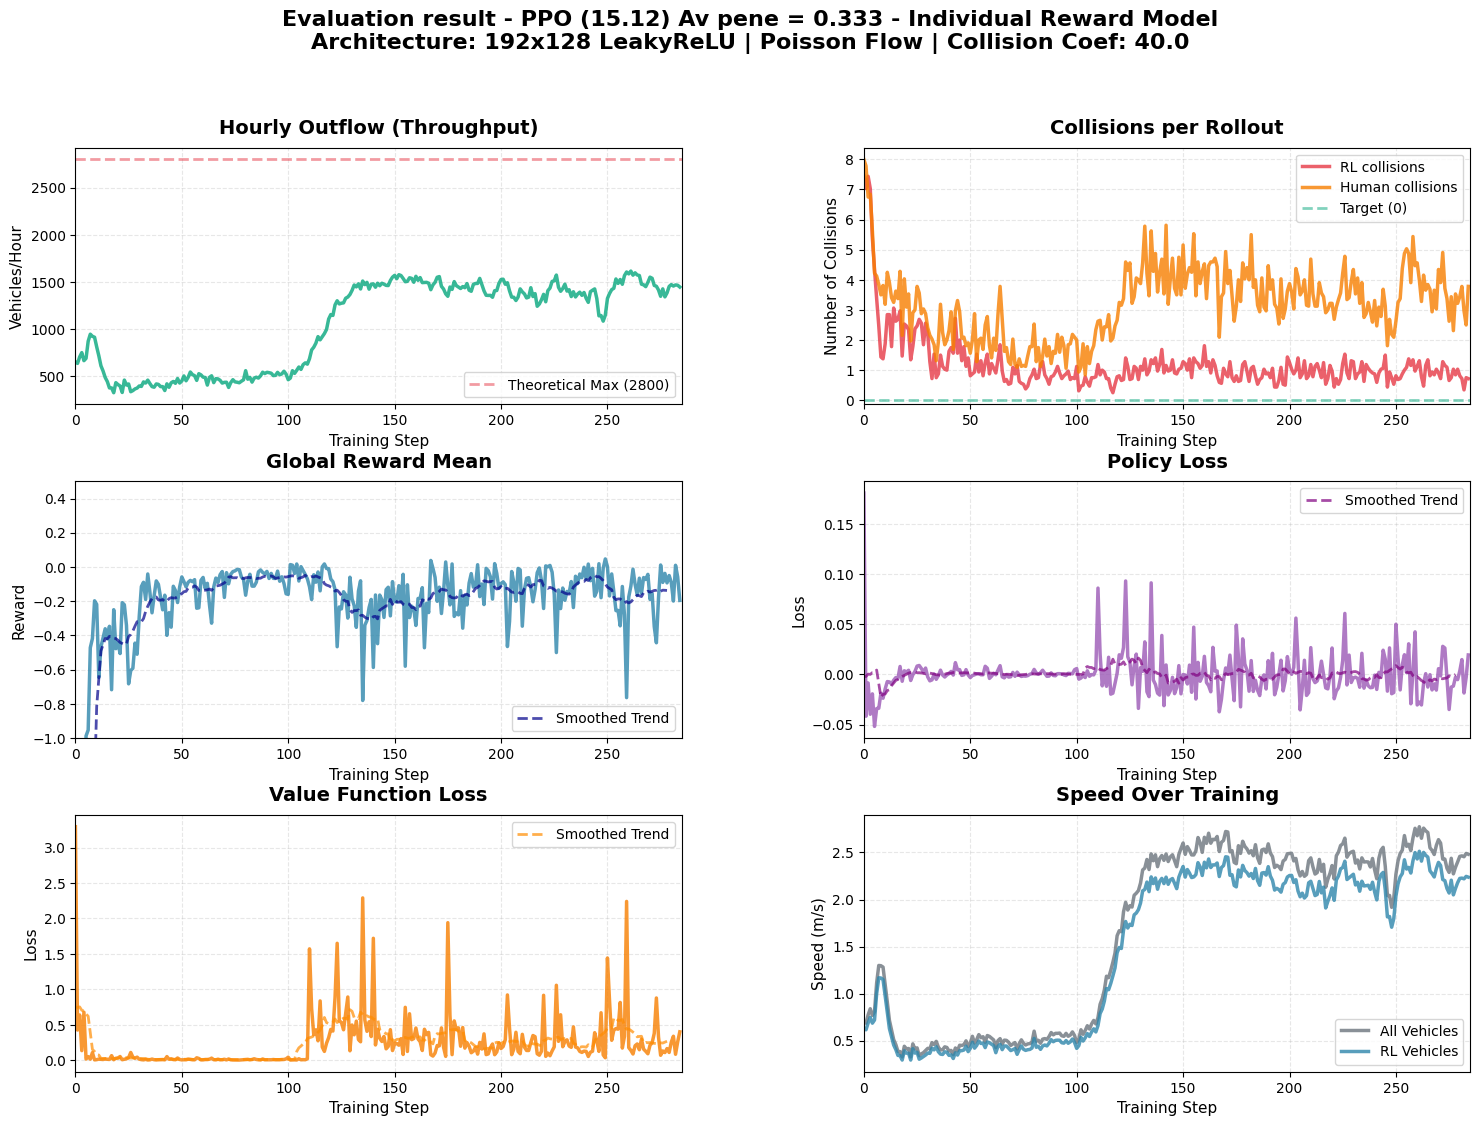


TRAINING SUMMARY - PPO (15.12) AV pene = 0.333
Total Training Steps: 285

Final Metrics (Last 10 Steps Average):
--------------------------------------------------------------------------------
Hourly Outflow      : 1436.150 veh/hr
Collisions          :    3.997 per rollout
Global Reward       :   -0.089 
Policy Loss         :   -0.002 
Value Loss          :    0.205 
Speed (All)         :    2.422 m/s
Speed (RL)          :    2.190 m/s

Performance Indicators:
--------------------------------------------------------------------------------
Throughput Efficiency: 51.3% of theoretical max
Safety Score: NEEDS IMPROVEMENT (4.00 collisions)
Learning Stability: UNSTABLE (policy loss std: 0.0125)


In [23]:
# Load results
df = pd.read_csv('results/fourway_1x1_penetration0.333_turn_adam_ppo_15.12/train_results.csv')

# Calculate hourly outflow
def calculate_hourly_outflow(df, horizon=2000, sim_step=0.5):
    """Convert outflow per rollout to vehicles per hour"""
    simulation_time_seconds = horizon * sim_step
    simulation_time_hours = simulation_time_seconds / 3600
    df['outflow_hourly'] = df['outflow'] / simulation_time_hours
    return df

df = calculate_hourly_outflow(df.copy())

# Create comprehensive subplot figure
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# Define color scheme
colors = {
    'primary': '#2E86AB',
    'danger': '#E63946',
    'success': '#06A77D',
    'warning': '#F77F00',
    'info': '#9B59B6',
    'secondary': '#6C757D'
}

# --- Subplot 1: Hourly Outflow ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(df['step'], df['outflow_hourly'], linewidth=2.5, color=colors['success'], alpha=0.8)
ax1.axhline(y=2800, color=colors['danger'], linestyle='--', linewidth=2, alpha=0.5, label='Theoretical Max (2800)')
# ax1.fill_between(df['step'], 0, df['outflow_hourly'], alpha=0.2, color=colors['success'])
ax1.set_title('Hourly Outflow (Throughput)', fontsize=14, fontweight='bold', pad=10)
ax1.set_xlabel('Training Step', fontsize=11)
ax1.set_ylabel('Vehicles/Hour', fontsize=11)
ax1.legend(loc='lower right', fontsize=10)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_xlim(df['step'].min(), df['step'].max())

# Add annotation for final value
final_outflow = df['outflow_hourly'].iloc[-1]
ax1.annotate(f'Final: {final_outflow:.1f}', 
            xy=(df['step'].iloc[-1], final_outflow),
            xytext=(10, 10), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            fontsize=10, fontweight='bold')

# --- Subplot 2: Collisions ---
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(df['step'], df['collisions'] - df['collisions_human'], label = 'RL collisions', linewidth=2.5, color=colors['danger'], alpha=0.8)
ax2.plot(df['step'], df['collisions_human'], label = 'Human collisions', linewidth=2.5, color=colors['warning'], alpha=0.8)
# ax2.fill_between(df['step'], 0, df['collisions'], alpha=0.2, color=colors['danger'])
ax2.axhline(y=0, color=colors['success'], linestyle='--', linewidth=2, alpha=0.5, label='Target (0)')
ax2.set_title('Collisions per Rollout', fontsize=14, fontweight='bold', pad=10)
ax2.set_xlabel('Training Step', fontsize=11)
ax2.set_ylabel('Number of Collisions', fontsize=11)
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_xlim(df['step'].min(), df['step'].max())

# Add annotation for final value
final_collisions = df['collisions'].iloc[-1]
ax2.annotate(f'Final: {final_collisions:.2f}', 
            xy=(df['step'].iloc[-1], final_collisions),
            xytext=(10, -10), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            fontsize=10, fontweight='bold')

# --- Subplot 3: Global Reward Mean ---
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(df['step'], df['global_reward_mean'], linewidth=2.5, color=colors['primary'], alpha=0.8)
# ax3.fill_between(df['step'], df['global_reward_mean'].min(), df['global_reward_mean'], 
#                  alpha=0.2, color=colors['primary'])
ax3.set_title('Global Reward Mean', fontsize=14, fontweight='bold', pad=10)
ax3.set_xlabel('Training Step', fontsize=11)
ax3.set_ylabel('Reward', fontsize=11)
ax3.grid(True, alpha=0.3, linestyle='--')
ax3.set_xlim(df['step'].min(), df['step'].max())
ax3.set_ylim(-1, 0.5)

# Add smoothed trend line
from scipy.ndimage import uniform_filter1d
window_size = max(5, len(df) // 20)
smoothed = uniform_filter1d(df['global_reward_mean'], size=window_size)
ax3.plot(df['step'], smoothed, linewidth=2, color='darkblue', linestyle='--', 
         alpha=0.7, label='Smoothed Trend')
ax3.legend(loc='lower right', fontsize=10)

# --- Subplot 4: Policy Loss ---
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(df['step'], df['policy_loss'], linewidth=2.5, color=colors['info'], alpha=0.8)
# ax4.fill_between(df['step'], 0, df['policy_loss'], alpha=0.2, color=colors['info'])
ax4.set_title('Policy Loss', fontsize=14, fontweight='bold', pad=10)
ax4.set_xlabel('Training Step', fontsize=11)
ax4.set_ylabel('Loss', fontsize=11)
ax4.grid(True, alpha=0.3, linestyle='--')
ax4.set_xlim(df['step'].min(), df['step'].max())

# Add smoothed trend line
smoothed_policy = uniform_filter1d(df['policy_loss'], size=window_size)
ax4.plot(df['step'], smoothed_policy, linewidth=2, color='purple', linestyle='--', 
         alpha=0.7, label='Smoothed Trend')
ax4.legend(loc='upper right', fontsize=10)

# --- Subplot 5: Value Function Loss ---
ax5 = fig.add_subplot(gs[2, 0])
ax5.plot(df['step'], df['value_loss'], linewidth=2.5, color=colors['warning'], alpha=0.8)
# ax5.fill_between(df['step'], 0, df['value_loss'], alpha=0.2, color=colors['warning'])
ax5.set_title('Value Function Loss', fontsize=14, fontweight='bold', pad=10)
ax5.set_xlabel('Training Step', fontsize=11)
ax5.set_ylabel('Loss', fontsize=11)
ax5.grid(True, alpha=0.3, linestyle='--')
ax5.set_xlim(df['step'].min(), df['step'].max())

# Add smoothed trend line
smoothed_value = uniform_filter1d(df['value_loss'], size=window_size)
ax5.plot(df['step'], smoothed_value, linewidth=2, color='darkorange', linestyle='--', 
         alpha=0.7, label='Smoothed Trend')
ax5.legend(loc='upper right', fontsize=10)

# --- Subplot 6: Speed Over Training ---
ax6 = fig.add_subplot(gs[2, 1])
ax6.plot(df['step'], df['speed'], label='All Vehicles', linewidth=2.5, 
         color=colors['secondary'], alpha=0.8)
ax6.plot(df['step'], df['speed_rl'], label='RL Vehicles', linewidth=2.5, 
         color=colors['primary'], alpha=0.8)
# ax6.fill_between(df['step'], df['speed'], alpha=0.1, color=colors['secondary'])
# ax6.fill_between(df['step'], df['speed_rl'], alpha=0.1, color=colors['primary'])
ax6.set_title('Speed Over Training', fontsize=14, fontweight='bold', pad=10)
ax6.set_xlabel('Training Step', fontsize=11)
ax6.set_ylabel('Speed (m/s)', fontsize=11)
ax6.legend(loc='lower right', fontsize=10)
ax6.grid(True, alpha=0.3, linestyle='--')
ax6.set_xlim(df['step'].min(), df['step'].max())

# Add annotation for final speeds
final_speed_all = df['speed'].iloc[-1]
final_speed_rl = df['speed_rl'].iloc[-1]
ax6.annotate(f'All: {final_speed_all:.2f} m/s\nRL: {final_speed_rl:.2f} m/s', 
            xy=(df['step'].iloc[-1], final_speed_rl),
            xytext=(-80, 20), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            fontsize=9, fontweight='bold')

# Add main title
fig.suptitle('Evaluation result - PPO (15.12) Av pene = 0.333 - Individual Reward Model\n' + 
             'Architecture: 192x128 LeakyReLU | Poisson Flow | Collision Coef: 40.0',
             fontsize=16, fontweight='bold', y=0.995)

plt.tight_layout()
plt.show()

# --- Print Summary Statistics ---
print("\n" + "="*80)
print("TRAINING SUMMARY - PPO (15.12) AV pene = 0.333")
print("="*80)
print(f"Total Training Steps: {df['step'].max()}")
print(f"\nFinal Metrics (Last 10 Steps Average):")
print("-" * 80)

last_10 = df.tail(10)

metrics = {
    'Hourly Outflow': (last_10['outflow_hourly'].mean(), 'veh/hr'),
    'Collisions': (last_10['collisions'].mean(), 'per rollout'),
    'Global Reward': (last_10['global_reward_mean'].mean(), ''),
    'Policy Loss': (last_10['policy_loss'].mean(), ''),
    'Value Loss': (last_10['value_loss'].mean(), ''),
    'Speed (All)': (last_10['speed'].mean(), 'm/s'),
    'Speed (RL)': (last_10['speed_rl'].mean(), 'm/s'),
}

for metric, (value, unit) in metrics.items():
    print(f"{metric:20s}: {value:8.3f} {unit}")

print("\nPerformance Indicators:")
print("-" * 80)
efficiency = (last_10['outflow_hourly'].mean() / 2800) * 100
print(f"Throughput Efficiency: {efficiency:.1f}% of theoretical max")
print(f"Safety Score: {'EXCELLENT' if last_10['collisions'].mean() < 0.5 else 'NEEDS IMPROVEMENT'} ({last_10['collisions'].mean():.2f} collisions)")
print(f"Learning Stability: {'STABLE' if last_10['policy_loss'].std() < 0.01 else 'UNSTABLE'} (policy loss std: {last_10['policy_loss'].std():.4f})")
print("="*80)


# 17.12
Change network layers
Change reward function to only punish ahead vehicle

/tmp/ipykernel_77069/1676835727.py:150: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


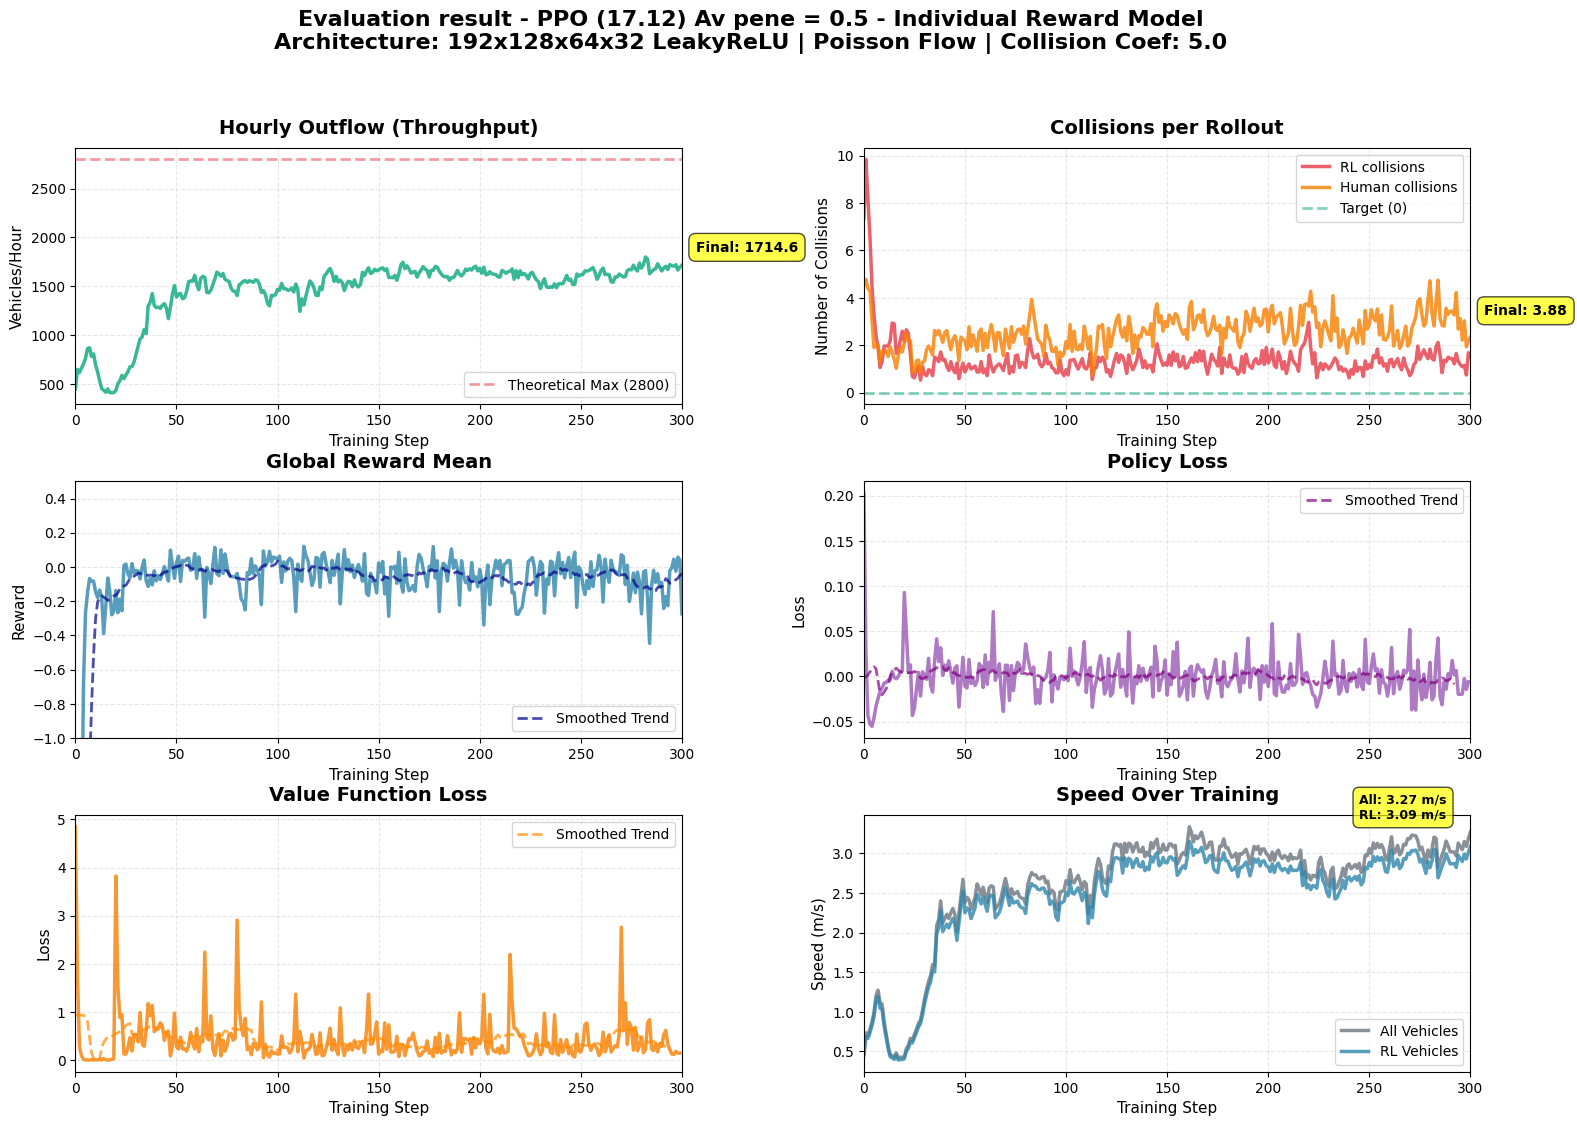


TRAINING SUMMARY - PPO (17.12) AV pene = 0.5
Total Training Steps: 300

Final Metrics (Last 10 Steps Average):
--------------------------------------------------------------------------------
Hourly Outflow      : 1699.335 veh/hr
Collisions          :    4.150 per rollout
Global Reward       :   -0.083 
Policy Loss         :   -0.006 
Value Loss          :    0.271 
Speed (All)         :    3.096 m/s
Speed (RL)          :    2.939 m/s

Performance Indicators:
--------------------------------------------------------------------------------
Throughput Efficiency: 60.7% of theoretical max
Safety Score: NEEDS IMPROVEMENT (4.15 collisions)
Learning Stability: UNSTABLE (policy loss std: 0.0133)


In [12]:
# Load results
df = pd.read_csv('results/fourway_1x1_penetration0.5_turn_adam_ppo_17.12/train_results.csv')

# Calculate hourly outflow
def calculate_hourly_outflow(df, horizon=2000, sim_step=0.5):
    """Convert outflow per rollout to vehicles per hour"""
    simulation_time_seconds = horizon * sim_step
    simulation_time_hours = simulation_time_seconds / 3600
    df['outflow_hourly'] = df['outflow'] / simulation_time_hours
    return df

df = calculate_hourly_outflow(df.copy())

# Create comprehensive subplot figure
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# Define color scheme
colors = {
    'primary': '#2E86AB',
    'danger': '#E63946',
    'success': '#06A77D',
    'warning': '#F77F00',
    'info': '#9B59B6',
    'secondary': '#6C757D'
}

# --- Subplot 1: Hourly Outflow ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(df['step'], df['outflow_hourly'], linewidth=2.5, color=colors['success'], alpha=0.8)
ax1.axhline(y=2800, color=colors['danger'], linestyle='--', linewidth=2, alpha=0.5, label='Theoretical Max (2800)')
# ax1.fill_between(df['step'], 0, df['outflow_hourly'], alpha=0.2, color=colors['success'])
ax1.set_title('Hourly Outflow (Throughput)', fontsize=14, fontweight='bold', pad=10)
ax1.set_xlabel('Training Step', fontsize=11)
ax1.set_ylabel('Vehicles/Hour', fontsize=11)
ax1.legend(loc='lower right', fontsize=10)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_xlim(df['step'].min(), df['step'].max())

# Add annotation for final value
final_outflow = df['outflow_hourly'].iloc[-1]
ax1.annotate(f'Final: {final_outflow:.1f}', 
            xy=(df['step'].iloc[-1], final_outflow),
            xytext=(10, 10), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            fontsize=10, fontweight='bold')

# --- Subplot 2: Collisions ---
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(df['step'], df['collisions'] - df['collisions_human'], label = 'RL collisions', linewidth=2.5, color=colors['danger'], alpha=0.8)
ax2.plot(df['step'], df['collisions_human'], label = 'Human collisions', linewidth=2.5, color=colors['warning'], alpha=0.8)
# ax2.fill_between(df['step'], 0, df['collisions'], alpha=0.2, color=colors['danger'])
ax2.axhline(y=0, color=colors['success'], linestyle='--', linewidth=2, alpha=0.5, label='Target (0)')
ax2.set_title('Collisions per Rollout', fontsize=14, fontweight='bold', pad=10)
ax2.set_xlabel('Training Step', fontsize=11)
ax2.set_ylabel('Number of Collisions', fontsize=11)
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_xlim(df['step'].min(), df['step'].max())

# Add annotation for final value
final_collisions = df['collisions'].iloc[-1]
ax2.annotate(f'Final: {final_collisions:.2f}', 
            xy=(df['step'].iloc[-1], final_collisions),
            xytext=(10, -10), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            fontsize=10, fontweight='bold')

# --- Subplot 3: Global Reward Mean ---
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(df['step'], df['global_reward_mean'], linewidth=2.5, color=colors['primary'], alpha=0.8)
# ax3.fill_between(df['step'], df['global_reward_mean'].min(), df['global_reward_mean'], 
#                  alpha=0.2, color=colors['primary'])
ax3.set_title('Global Reward Mean', fontsize=14, fontweight='bold', pad=10)
ax3.set_xlabel('Training Step', fontsize=11)
ax3.set_ylabel('Reward', fontsize=11)
ax3.grid(True, alpha=0.3, linestyle='--')
ax3.set_xlim(df['step'].min(), df['step'].max())
ax3.set_ylim(-1, 0.5)

# Add smoothed trend line
from scipy.ndimage import uniform_filter1d
window_size = max(5, len(df) // 20)
smoothed = uniform_filter1d(df['global_reward_mean'], size=window_size)
ax3.plot(df['step'], smoothed, linewidth=2, color='darkblue', linestyle='--', 
         alpha=0.7, label='Smoothed Trend')
ax3.legend(loc='lower right', fontsize=10)

# --- Subplot 4: Policy Loss ---
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(df['step'], df['policy_loss'], linewidth=2.5, color=colors['info'], alpha=0.8)
# ax4.fill_between(df['step'], 0, df['policy_loss'], alpha=0.2, color=colors['info'])
ax4.set_title('Policy Loss', fontsize=14, fontweight='bold', pad=10)
ax4.set_xlabel('Training Step', fontsize=11)
ax4.set_ylabel('Loss', fontsize=11)
ax4.grid(True, alpha=0.3, linestyle='--')
ax4.set_xlim(df['step'].min(), df['step'].max())

# Add smoothed trend line
smoothed_policy = uniform_filter1d(df['policy_loss'], size=window_size)
ax4.plot(df['step'], smoothed_policy, linewidth=2, color='purple', linestyle='--', 
         alpha=0.7, label='Smoothed Trend')
ax4.legend(loc='upper right', fontsize=10)

# --- Subplot 5: Value Function Loss ---
ax5 = fig.add_subplot(gs[2, 0])
ax5.plot(df['step'], df['value_loss'], linewidth=2.5, color=colors['warning'], alpha=0.8)
# ax5.fill_between(df['step'], 0, df['value_loss'], alpha=0.2, color=colors['warning'])
ax5.set_title('Value Function Loss', fontsize=14, fontweight='bold', pad=10)
ax5.set_xlabel('Training Step', fontsize=11)
ax5.set_ylabel('Loss', fontsize=11)
ax5.grid(True, alpha=0.3, linestyle='--')
ax5.set_xlim(df['step'].min(), df['step'].max())

# Add smoothed trend line
smoothed_value = uniform_filter1d(df['value_loss'], size=window_size)
ax5.plot(df['step'], smoothed_value, linewidth=2, color='darkorange', linestyle='--', 
         alpha=0.7, label='Smoothed Trend')
ax5.legend(loc='upper right', fontsize=10)

# --- Subplot 6: Speed Over Training ---
ax6 = fig.add_subplot(gs[2, 1])
ax6.plot(df['step'], df['speed'], label='All Vehicles', linewidth=2.5, 
         color=colors['secondary'], alpha=0.8)
ax6.plot(df['step'], df['speed_rl'], label='RL Vehicles', linewidth=2.5, 
         color=colors['primary'], alpha=0.8)
# ax6.fill_between(df['step'], df['speed'], alpha=0.1, color=colors['secondary'])
# ax6.fill_between(df['step'], df['speed_rl'], alpha=0.1, color=colors['primary'])
ax6.set_title('Speed Over Training', fontsize=14, fontweight='bold', pad=10)
ax6.set_xlabel('Training Step', fontsize=11)
ax6.set_ylabel('Speed (m/s)', fontsize=11)
ax6.legend(loc='lower right', fontsize=10)
ax6.grid(True, alpha=0.3, linestyle='--')
ax6.set_xlim(df['step'].min(), df['step'].max())

# Add annotation for final speeds
final_speed_all = df['speed'].iloc[-1]
final_speed_rl = df['speed_rl'].iloc[-1]
ax6.annotate(f'All: {final_speed_all:.2f} m/s\nRL: {final_speed_rl:.2f} m/s', 
            xy=(df['step'].iloc[-1], final_speed_rl),
            xytext=(-80, 20), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            fontsize=9, fontweight='bold')

# Add main title
fig.suptitle('Evaluation result - PPO (17.12) Av pene = 0.5 - Individual Reward Model\n' + 
             'Architecture: 192x128x64x32 LeakyReLU | Poisson Flow | Collision Coef: 5.0',
             fontsize=16, fontweight='bold', y=0.995)

plt.tight_layout()
plt.show()

# --- Print Summary Statistics ---
print("\n" + "="*80)
print("TRAINING SUMMARY - PPO (17.12) AV pene = 0.5")
print("="*80)
print(f"Total Training Steps: {df['step'].max()}")
print(f"\nFinal Metrics (Last 10 Steps Average):")
print("-" * 80)

last_10 = df.tail(10)

metrics = {
    'Hourly Outflow': (last_10['outflow_hourly'].mean(), 'veh/hr'),
    'Collisions': (last_10['collisions'].mean(), 'per rollout'),
    'Global Reward': (last_10['global_reward_mean'].mean(), ''),
    'Policy Loss': (last_10['policy_loss'].mean(), ''),
    'Value Loss': (last_10['value_loss'].mean(), ''),
    'Speed (All)': (last_10['speed'].mean(), 'm/s'),
    'Speed (RL)': (last_10['speed_rl'].mean(), 'm/s'),
}

for metric, (value, unit) in metrics.items():
    print(f"{metric:20s}: {value:8.3f} {unit}")

print("\nPerformance Indicators:")
print("-" * 80)
efficiency = (last_10['outflow_hourly'].mean() / 2800) * 100
print(f"Throughput Efficiency: {efficiency:.1f}% of theoretical max")
print(f"Safety Score: {'EXCELLENT' if last_10['collisions'].mean() < 4.0 else 'NEEDS IMPROVEMENT'} ({last_10['collisions'].mean():.2f} collisions)")
print(f"Learning Stability: {'STABLE' if last_10['policy_loss'].std() < 0.01 else 'UNSTABLE'} (policy loss std: {last_10['policy_loss'].std():.4f})")
print("="*80)


# 03.02.2026

Implemtent Multi-head Attention

/tmp/ipykernel_1056/3224766082.py:151: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


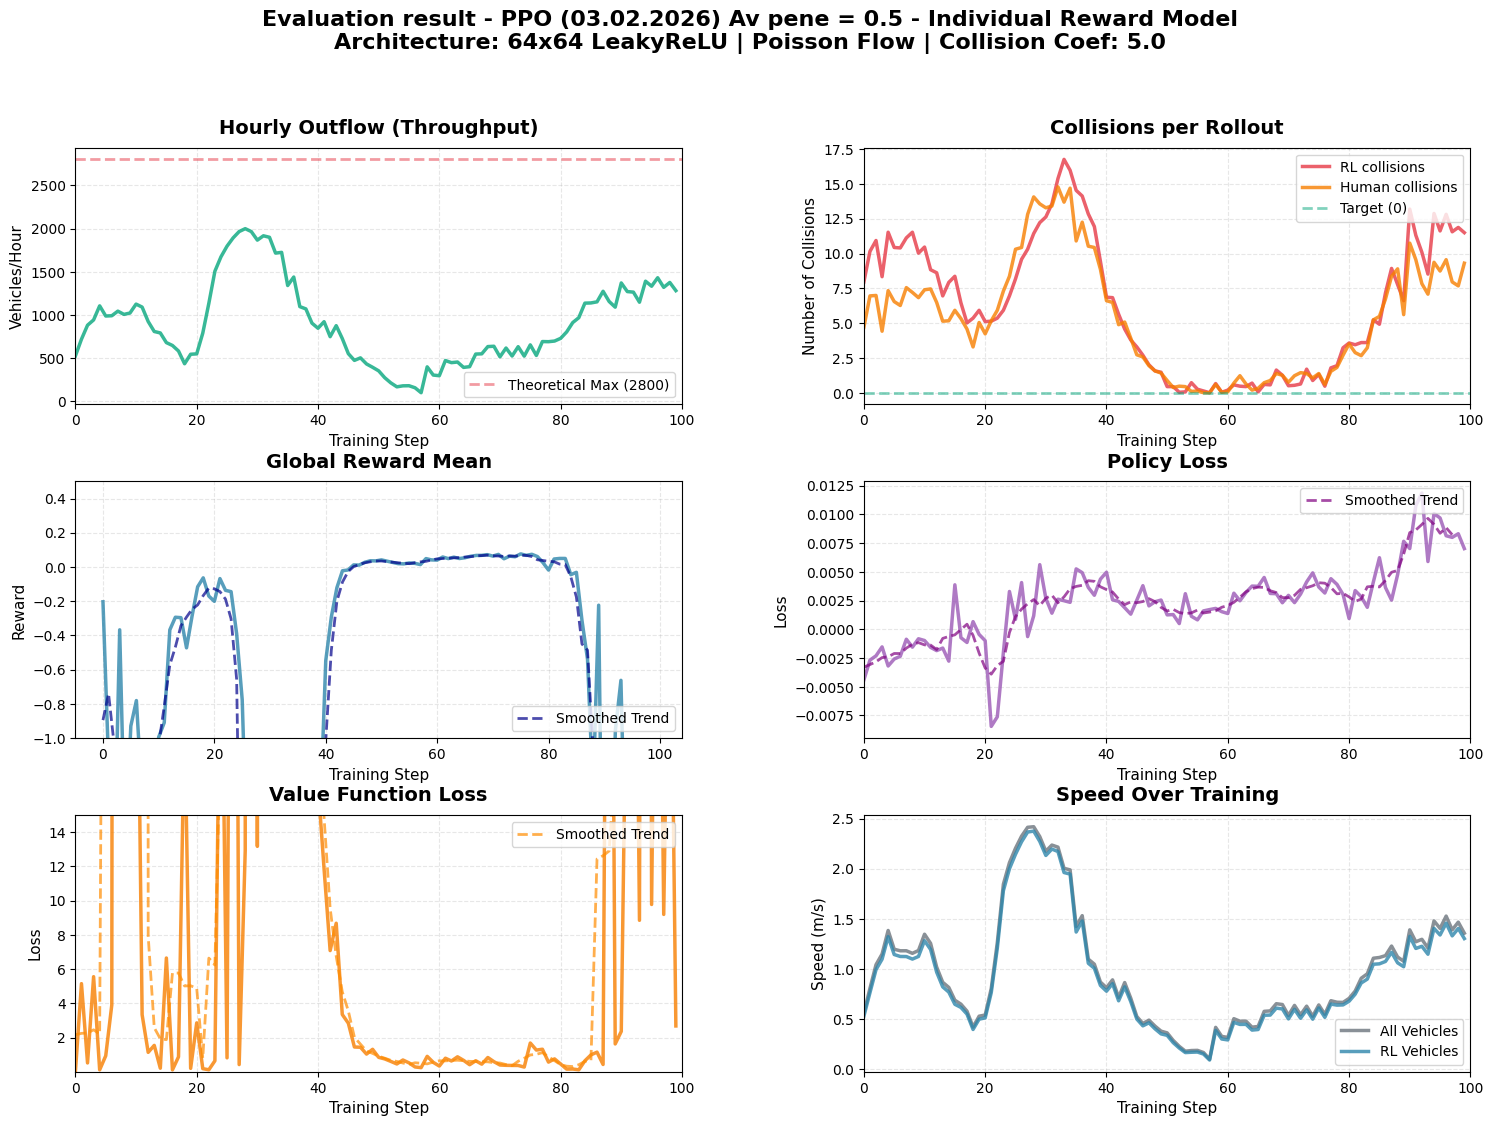


TRAINING SUMMARY - PPO (03.02.2026) AV pene = 0.5
Total Training Steps: 100

Final Metrics (Last 10 Steps Average):
--------------------------------------------------------------------------------
Hourly Outflow      : 1312.763 veh/hr
Collisions          :   19.927 per rollout
Global Reward       :   -2.014 
Policy Loss         :    0.009 
Value Loss          :   35.643 
Speed (All)         :    1.378 m/s
Speed (RL)          :    1.313 m/s

Performance Indicators:
--------------------------------------------------------------------------------
Throughput Efficiency: 46.9% of theoretical max
Safety Score: NEEDS IMPROVEMENT (19.93 collisions)
Learning Stability: STABLE (policy loss std: 0.0019)


In [6]:
# Load results
df = pd.read_csv('results/fourway_1x1_penetration0.5_turn_adam_ppo_transformer_02.02/train_results.csv')

# Calculate hourly outflow
def calculate_hourly_outflow(df, horizon=2000, sim_step=0.5):
    """Convert outflow per rollout to vehicles per hour"""
    simulation_time_seconds = horizon * sim_step
    simulation_time_hours = simulation_time_seconds / 3600
    df['outflow_hourly'] = df['outflow'] / simulation_time_hours
    return df

df = calculate_hourly_outflow(df.copy())

# Create comprehensive subplot figure
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# Define color scheme
colors = {
    'primary': '#2E86AB',
    'danger': '#E63946',
    'success': '#06A77D',
    'warning': '#F77F00',
    'info': '#9B59B6',
    'secondary': '#6C757D'
}

# --- Subplot 1: Hourly Outflow ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(df['step'], df['outflow_hourly'], linewidth=2.5, color=colors['success'], alpha=0.8)
ax1.axhline(y=2800, color=colors['danger'], linestyle='--', linewidth=2, alpha=0.5, label='Theoretical Max (2800)')
# ax1.fill_between(df['step'], 0, df['outflow_hourly'], alpha=0.2, color=colors['success'])
ax1.set_title('Hourly Outflow (Throughput)', fontsize=14, fontweight='bold', pad=10)
ax1.set_xlabel('Training Step', fontsize=11)
ax1.set_ylabel('Vehicles/Hour', fontsize=11)
ax1.legend(loc='lower right', fontsize=10)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_xlim(df['step'].min(), df['step'].max())

# Add annotation for final value
final_outflow = df['outflow_hourly'].iloc[-1]
ax1.annotate(f'Final: {final_outflow:.1f}', 
            xy=(df['step'].iloc[-1], final_outflow),
            xytext=(10, 10), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            fontsize=10, fontweight='bold')

# --- Subplot 2: Collisions ---
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(df['step'], df['collisions'] - df['collisions_human'], label = 'RL collisions', linewidth=2.5, color=colors['danger'], alpha=0.8)
ax2.plot(df['step'], df['collisions_human'], label = 'Human collisions', linewidth=2.5, color=colors['warning'], alpha=0.8)
# ax2.fill_between(df['step'], 0, df['collisions'], alpha=0.2, color=colors['danger'])
ax2.axhline(y=0, color=colors['success'], linestyle='--', linewidth=2, alpha=0.5, label='Target (0)')
ax2.set_title('Collisions per Rollout', fontsize=14, fontweight='bold', pad=10)
ax2.set_xlabel('Training Step', fontsize=11)
ax2.set_ylabel('Number of Collisions', fontsize=11)
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_xlim(df['step'].min(), df['step'].max())

# Add annotation for final value
final_collisions = df['collisions'].iloc[-1]
ax2.annotate(f'Final: {final_collisions:.2f}', 
            xy=(df['step'].iloc[-1], final_collisions),
            xytext=(10, -10), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            fontsize=10, fontweight='bold')

# --- Subplot 3: Global Reward Mean ---
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(df['step'], df['global_reward_mean'], linewidth=2.5, color=colors['primary'], alpha=0.8)
# ax3.fill_between(df['step'], df['global_reward_mean'].min(), df['global_reward_mean'], 
#                  alpha=0.2, color=colors['primary'])
ax3.set_title('Global Reward Mean', fontsize=14, fontweight='bold', pad=10)
ax3.set_xlabel('Training Step', fontsize=11)
ax3.set_ylabel('Reward', fontsize=11)
ax3.grid(True, alpha=0.3, linestyle='--')
# ax3.set_xlim(df['step'].min(), df['step'].max())
ax3.set_ylim(-1, 0.5)

# Add smoothed trend line
from scipy.ndimage import uniform_filter1d
window_size = max(5, len(df) // 20)
smoothed = uniform_filter1d(df['global_reward_mean'], size=window_size)
ax3.plot(df['step'], smoothed, linewidth=2, color='darkblue', linestyle='--', 
         alpha=0.7, label='Smoothed Trend')
ax3.legend(loc='lower right', fontsize=10)

# --- Subplot 4: Policy Loss ---
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(df['step'], df['policy_loss'], linewidth=2.5, color=colors['info'], alpha=0.8)
# ax4.fill_between(df['step'], 0, df['policy_loss'], alpha=0.2, color=colors['info'])
ax4.set_title('Policy Loss', fontsize=14, fontweight='bold', pad=10)
ax4.set_xlabel('Training Step', fontsize=11)
ax4.set_ylabel('Loss', fontsize=11)
ax4.grid(True, alpha=0.3, linestyle='--')
ax4.set_xlim(df['step'].min(), df['step'].max())

# Add smoothed trend line
smoothed_policy = uniform_filter1d(df['policy_loss'], size=window_size)
ax4.plot(df['step'], smoothed_policy, linewidth=2, color='purple', linestyle='--', 
         alpha=0.7, label='Smoothed Trend')
ax4.legend(loc='upper right', fontsize=10)

# --- Subplot 5: Value Function Loss ---
ax5 = fig.add_subplot(gs[2, 0])
ax5.plot(df['step'], df['value_loss'], linewidth=2.5, color=colors['warning'], alpha=0.8)
# ax5.fill_between(df['step'], 0, df['value_loss'], alpha=0.2, color=colors['warning'])
ax5.set_title('Value Function Loss', fontsize=14, fontweight='bold', pad=10)
ax5.set_xlabel('Training Step', fontsize=11)
ax5.set_ylabel('Loss', fontsize=11)
ax5.grid(True, alpha=0.3, linestyle='--')
ax5.set_xlim(df['step'].min(), df['step'].max())
ax5.set_ylim(df['value_loss'].min(), 15)

# Add smoothed trend line
smoothed_value = uniform_filter1d(df['value_loss'], size=window_size)
ax5.plot(df['step'], smoothed_value, linewidth=2, color='darkorange', linestyle='--', 
         alpha=0.7, label='Smoothed Trend')
ax5.legend(loc='upper right', fontsize=10)

# --- Subplot 6: Speed Over Training ---
ax6 = fig.add_subplot(gs[2, 1])
ax6.plot(df['step'], df['speed'], label='All Vehicles', linewidth=2.5, 
         color=colors['secondary'], alpha=0.8)
ax6.plot(df['step'], df['speed_rl'], label='RL Vehicles', linewidth=2.5, 
         color=colors['primary'], alpha=0.8)
# ax6.fill_between(df['step'], df['speed'], alpha=0.1, color=colors['secondary'])
# ax6.fill_between(df['step'], df['speed_rl'], alpha=0.1, color=colors['primary'])
ax6.set_title('Speed Over Training', fontsize=14, fontweight='bold', pad=10)
ax6.set_xlabel('Training Step', fontsize=11)
ax6.set_ylabel('Speed (m/s)', fontsize=11)
ax6.legend(loc='lower right', fontsize=10)
ax6.grid(True, alpha=0.3, linestyle='--')
ax6.set_xlim(df['step'].min(), df['step'].max())

# Add annotation for final speeds
final_speed_all = df['speed'].iloc[-1]
final_speed_rl = df['speed_rl'].iloc[-1]
ax6.annotate(f'All: {final_speed_all:.2f} m/s\nRL: {final_speed_rl:.2f} m/s', 
            xy=(df['step'].iloc[-1], final_speed_rl),
            xytext=(-80, 20), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            fontsize=9, fontweight='bold')

# Add main title
fig.suptitle('Evaluation result - PPO (03.02.2026) Av pene = 0.5 - Individual Reward Model\n' + 
             'Architecture: 64x64 LeakyReLU | Poisson Flow | Collision Coef: 5.0',
             fontsize=16, fontweight='bold', y=0.995)

plt.tight_layout()
plt.show()

# --- Print Summary Statistics ---
print("\n" + "="*80)
print("TRAINING SUMMARY - PPO (03.02.2026) AV pene = 0.5")
print("="*80)
print(f"Total Training Steps: {df['step'].max()}")
print(f"\nFinal Metrics (Last 10 Steps Average):")
print("-" * 80)

last_10 = df.tail(10)

metrics = {
    'Hourly Outflow': (last_10['outflow_hourly'].mean(), 'veh/hr'),
    'Collisions': (last_10['collisions'].mean(), 'per rollout'),
    'Global Reward': (last_10['global_reward_mean'].mean(), ''),
    'Policy Loss': (last_10['policy_loss'].mean(), ''),
    'Value Loss': (last_10['value_loss'].mean(), ''),
    'Speed (All)': (last_10['speed'].mean(), 'm/s'),
    'Speed (RL)': (last_10['speed_rl'].mean(), 'm/s'),
}

for metric, (value, unit) in metrics.items():
    print(f"{metric:20s}: {value:8.3f} {unit}")

print("\nPerformance Indicators:")
print("-" * 80)
efficiency = (last_10['outflow_hourly'].mean() / 2800) * 100
print(f"Throughput Efficiency: {efficiency:.1f}% of theoretical max")
print(f"Safety Score: {'EXCELLENT' if last_10['collisions'].mean() < 4.0 else 'NEEDS IMPROVEMENT'} ({last_10['collisions'].mean():.2f} collisions)")
print(f"Learning Stability: {'STABLE' if last_10['policy_loss'].std() < 0.01 else 'UNSTABLE'} (policy loss std: {last_10['policy_loss'].std():.4f})")
print("="*80)


# 05.02
Change network architecture 
64x64 to 256x256
change architecture from embeded transformer to 128 input, 512 layer, 3 layers

/tmp/ipykernel_1117/658619465.py:151: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


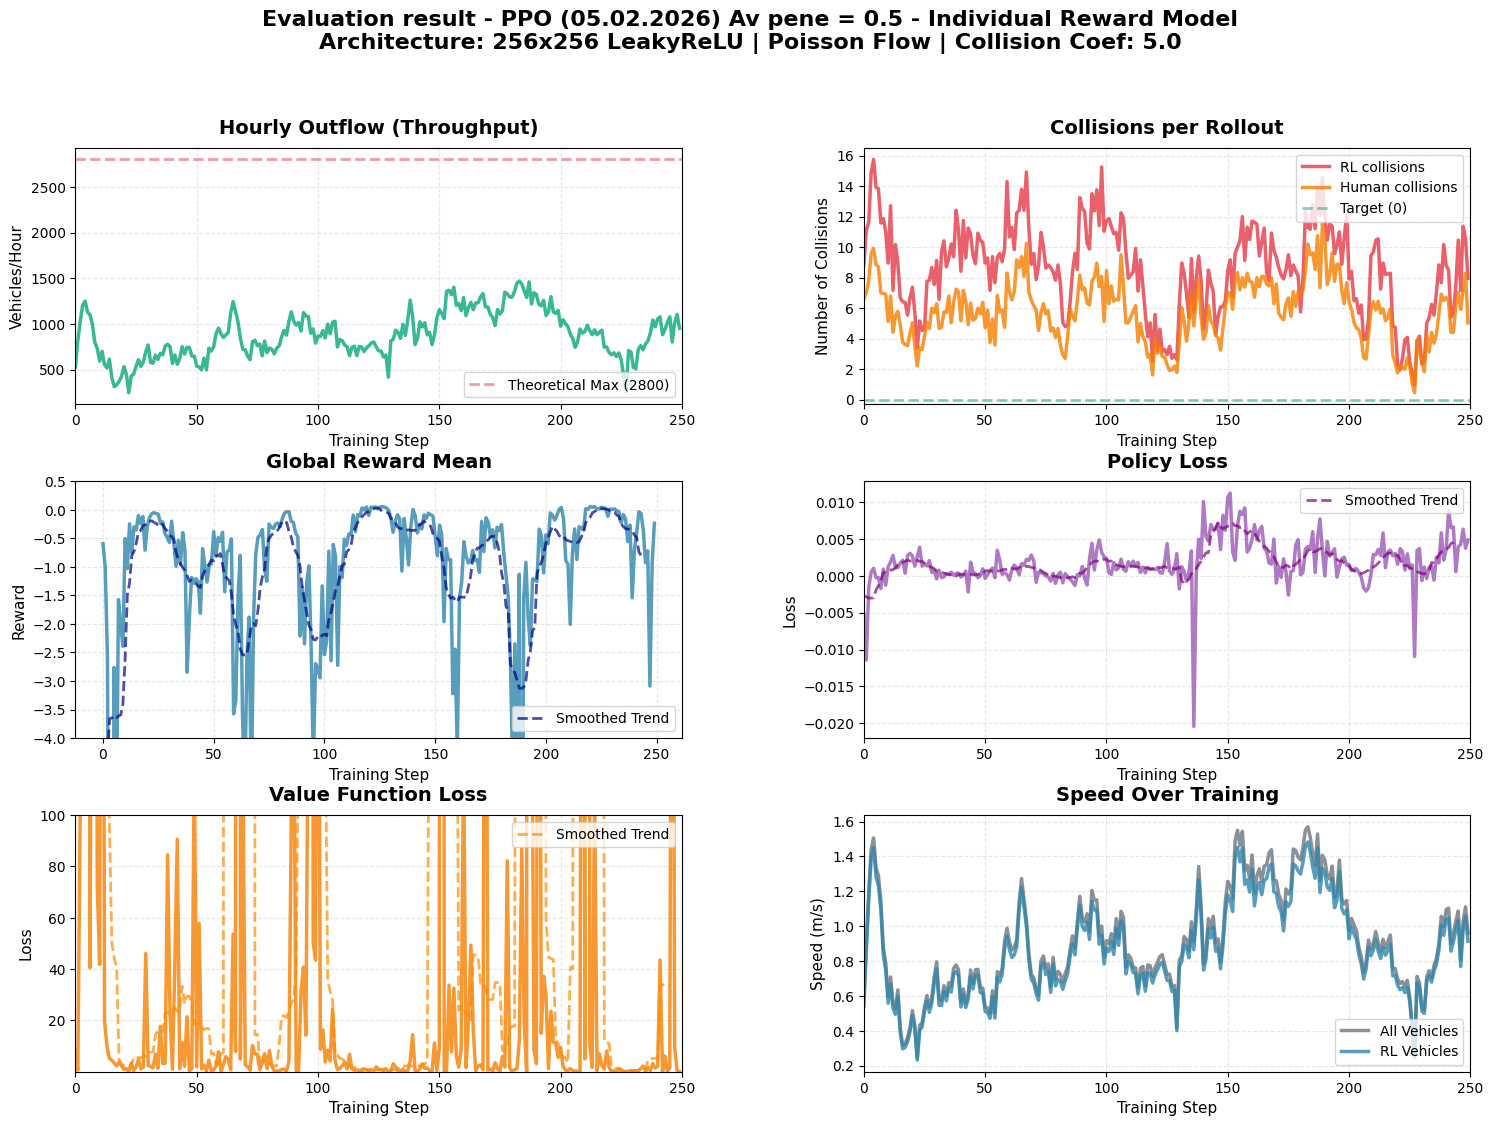


TRAINING SUMMARY - PPO (05.02.2026) AV pene = 0.5
Total Training Steps: 250

Final Metrics (Last 10 Steps Average):
--------------------------------------------------------------------------------
Hourly Outflow      :  985.133 veh/hr
Collisions          :   14.389 per rollout
Global Reward       :   -0.752 
Policy Loss         :    0.005 
Value Loss          :   44.325 
Speed (All)         :    0.999 m/s
Speed (RL)          :    0.949 m/s

Performance Indicators:
--------------------------------------------------------------------------------
Throughput Efficiency: 35.2% of theoretical max
Safety Score: NEEDS IMPROVEMENT (14.39 collisions)
Learning Stability: STABLE (policy loss std: 0.0023)


In [5]:
# Load results
df = pd.read_csv('results/fourway_1x1_penetration0.5_turn_adam_ppo_transformer_05.02/train_results.csv')

# Calculate hourly outflow
def calculate_hourly_outflow(df, horizon=2000, sim_step=0.5):
    """Convert outflow per rollout to vehicles per hour"""
    simulation_time_seconds = horizon * sim_step
    simulation_time_hours = simulation_time_seconds / 3600
    df['outflow_hourly'] = df['outflow'] / simulation_time_hours
    return df

df = calculate_hourly_outflow(df.copy())

# Create comprehensive subplot figure
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# Define color scheme
colors = {
    'primary': '#2E86AB',
    'danger': '#E63946',
    'success': '#06A77D',
    'warning': '#F77F00',
    'info': '#9B59B6',
    'secondary': '#6C757D'
}

# --- Subplot 1: Hourly Outflow ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(df['step'], df['outflow_hourly'], linewidth=2.5, color=colors['success'], alpha=0.8)
ax1.axhline(y=2800, color=colors['danger'], linestyle='--', linewidth=2, alpha=0.5, label='Theoretical Max (2800)')
# ax1.fill_between(df['step'], 0, df['outflow_hourly'], alpha=0.2, color=colors['success'])
ax1.set_title('Hourly Outflow (Throughput)', fontsize=14, fontweight='bold', pad=10)
ax1.set_xlabel('Training Step', fontsize=11)
ax1.set_ylabel('Vehicles/Hour', fontsize=11)
ax1.legend(loc='lower right', fontsize=10)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_xlim(df['step'].min(), df['step'].max())

# Add annotation for final value
final_outflow = df['outflow_hourly'].iloc[-1]
ax1.annotate(f'Final: {final_outflow:.1f}', 
            xy=(df['step'].iloc[-1], final_outflow),
            xytext=(10, 10), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            fontsize=10, fontweight='bold')

# --- Subplot 2: Collisions ---
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(df['step'], df['collisions'] - df['collisions_human'], label = 'RL collisions', linewidth=2.5, color=colors['danger'], alpha=0.8)
ax2.plot(df['step'], df['collisions_human'], label = 'Human collisions', linewidth=2.5, color=colors['warning'], alpha=0.8)
# ax2.fill_between(df['step'], 0, df['collisions'], alpha=0.2, color=colors['danger'])
ax2.axhline(y=0, color=colors['success'], linestyle='--', linewidth=2, alpha=0.5, label='Target (0)')
ax2.set_title('Collisions per Rollout', fontsize=14, fontweight='bold', pad=10)
ax2.set_xlabel('Training Step', fontsize=11)
ax2.set_ylabel('Number of Collisions', fontsize=11)
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_xlim(df['step'].min(), df['step'].max())

# Add annotation for final value
final_collisions = df['collisions'].iloc[-1]
ax2.annotate(f'Final: {final_collisions:.2f}', 
            xy=(df['step'].iloc[-1], final_collisions),
            xytext=(10, -10), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            fontsize=10, fontweight='bold')

# --- Subplot 3: Global Reward Mean ---
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(df['step'], df['global_reward_mean'], linewidth=2.5, color=colors['primary'], alpha=0.8)
# ax3.fill_between(df['step'], df['global_reward_mean'].min(), df['global_reward_mean'], 
#                  alpha=0.2, color=colors['primary'])
ax3.set_title('Global Reward Mean', fontsize=14, fontweight='bold', pad=10)
ax3.set_xlabel('Training Step', fontsize=11)
ax3.set_ylabel('Reward', fontsize=11)
ax3.grid(True, alpha=0.3, linestyle='--')
# ax3.set_xlim(df['step'].min(), df['step'].max())
ax3.set_ylim(-4, 0.5)

# Add smoothed trend line
from scipy.ndimage import uniform_filter1d
window_size = max(5, len(df) // 20)
smoothed = uniform_filter1d(df['global_reward_mean'], size=window_size)
ax3.plot(df['step'], smoothed, linewidth=2, color='darkblue', linestyle='--', 
         alpha=0.7, label='Smoothed Trend')
ax3.legend(loc='lower right', fontsize=10)

# --- Subplot 4: Policy Loss ---
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(df['step'], df['policy_loss'], linewidth=2.5, color=colors['info'], alpha=0.8)
# ax4.fill_between(df['step'], 0, df['policy_loss'], alpha=0.2, color=colors['info'])
ax4.set_title('Policy Loss', fontsize=14, fontweight='bold', pad=10)
ax4.set_xlabel('Training Step', fontsize=11)
ax4.set_ylabel('Loss', fontsize=11)
ax4.grid(True, alpha=0.3, linestyle='--')
ax4.set_xlim(df['step'].min(), df['step'].max())

# Add smoothed trend line
smoothed_policy = uniform_filter1d(df['policy_loss'], size=window_size)
ax4.plot(df['step'], smoothed_policy, linewidth=2, color='purple', linestyle='--', 
         alpha=0.7, label='Smoothed Trend')
ax4.legend(loc='upper right', fontsize=10)

# --- Subplot 5: Value Function Loss ---
ax5 = fig.add_subplot(gs[2, 0])
ax5.plot(df['step'], df['value_loss'], linewidth=2.5, color=colors['warning'], alpha=0.8)
# ax5.fill_between(df['step'], 0, df['value_loss'], alpha=0.2, color=colors['warning'])
ax5.set_title('Value Function Loss', fontsize=14, fontweight='bold', pad=10)
ax5.set_xlabel('Training Step', fontsize=11)
ax5.set_ylabel('Loss', fontsize=11)
ax5.grid(True, alpha=0.3, linestyle='--')
ax5.set_xlim(df['step'].min(), df['step'].max())
ax5.set_ylim(df['value_loss'].min(), 100)

# Add smoothed trend line
smoothed_value = uniform_filter1d(df['value_loss'], size=window_size)
ax5.plot(df['step'], smoothed_value, linewidth=2, color='darkorange', linestyle='--', 
         alpha=0.7, label='Smoothed Trend')
ax5.legend(loc='upper right', fontsize=10)

# --- Subplot 6: Speed Over Training ---
ax6 = fig.add_subplot(gs[2, 1])
ax6.plot(df['step'], df['speed'], label='All Vehicles', linewidth=2.5, 
         color=colors['secondary'], alpha=0.8)
ax6.plot(df['step'], df['speed_rl'], label='RL Vehicles', linewidth=2.5, 
         color=colors['primary'], alpha=0.8)
# ax6.fill_between(df['step'], df['speed'], alpha=0.1, color=colors['secondary'])
# ax6.fill_between(df['step'], df['speed_rl'], alpha=0.1, color=colors['primary'])
ax6.set_title('Speed Over Training', fontsize=14, fontweight='bold', pad=10)
ax6.set_xlabel('Training Step', fontsize=11)
ax6.set_ylabel('Speed (m/s)', fontsize=11)
ax6.legend(loc='lower right', fontsize=10)
ax6.grid(True, alpha=0.3, linestyle='--')
ax6.set_xlim(df['step'].min(), df['step'].max())

# Add annotation for final speeds
final_speed_all = df['speed'].iloc[-1]
final_speed_rl = df['speed_rl'].iloc[-1]
ax6.annotate(f'All: {final_speed_all:.2f} m/s\nRL: {final_speed_rl:.2f} m/s', 
            xy=(df['step'].iloc[-1], final_speed_rl),
            xytext=(-80, 20), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            fontsize=9, fontweight='bold')

# Add main title
fig.suptitle('Evaluation result - PPO (05.02.2026) Av pene = 0.5 - Individual Reward Model\n' + 
             'Architecture: 256x256 LeakyReLU | Poisson Flow | Collision Coef: 5.0',
             fontsize=16, fontweight='bold', y=0.995)

plt.tight_layout()
plt.show()

# --- Print Summary Statistics ---
print("\n" + "="*80)
print("TRAINING SUMMARY - PPO (05.02.2026) AV pene = 0.5")
print("="*80)
print(f"Total Training Steps: {df['step'].max()}")
print(f"\nFinal Metrics (Last 10 Steps Average):")
print("-" * 80)

last_10 = df.tail(10)

metrics = {
    'Hourly Outflow': (last_10['outflow_hourly'].mean(), 'veh/hr'),
    'Collisions': (last_10['collisions'].mean(), 'per rollout'),
    'Global Reward': (last_10['global_reward_mean'].mean(), ''),
    'Policy Loss': (last_10['policy_loss'].mean(), ''),
    'Value Loss': (last_10['value_loss'].mean(), ''),
    'Speed (All)': (last_10['speed'].mean(), 'm/s'),
    'Speed (RL)': (last_10['speed_rl'].mean(), 'm/s'),
}

for metric, (value, unit) in metrics.items():
    print(f"{metric:20s}: {value:8.3f} {unit}")

print("\nPerformance Indicators:")
print("-" * 80)
efficiency = (last_10['outflow_hourly'].mean() / 2800) * 100
print(f"Throughput Efficiency: {efficiency:.1f}% of theoretical max")
print(f"Safety Score: {'EXCELLENT' if last_10['collisions'].mean() < 4.0 else 'NEEDS IMPROVEMENT'} ({last_10['collisions'].mean():.2f} collisions)")
print(f"Learning Stability: {'STABLE' if last_10['policy_loss'].std() < 0.01 else 'UNSTABLE'} (policy loss std: {last_10['policy_loss'].std():.4f})")
print("="*80)


# 07.02
Added 1 more feature to obs space
Distance to ego leader

/tmp/ipykernel_1056/2736907219.py:151: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


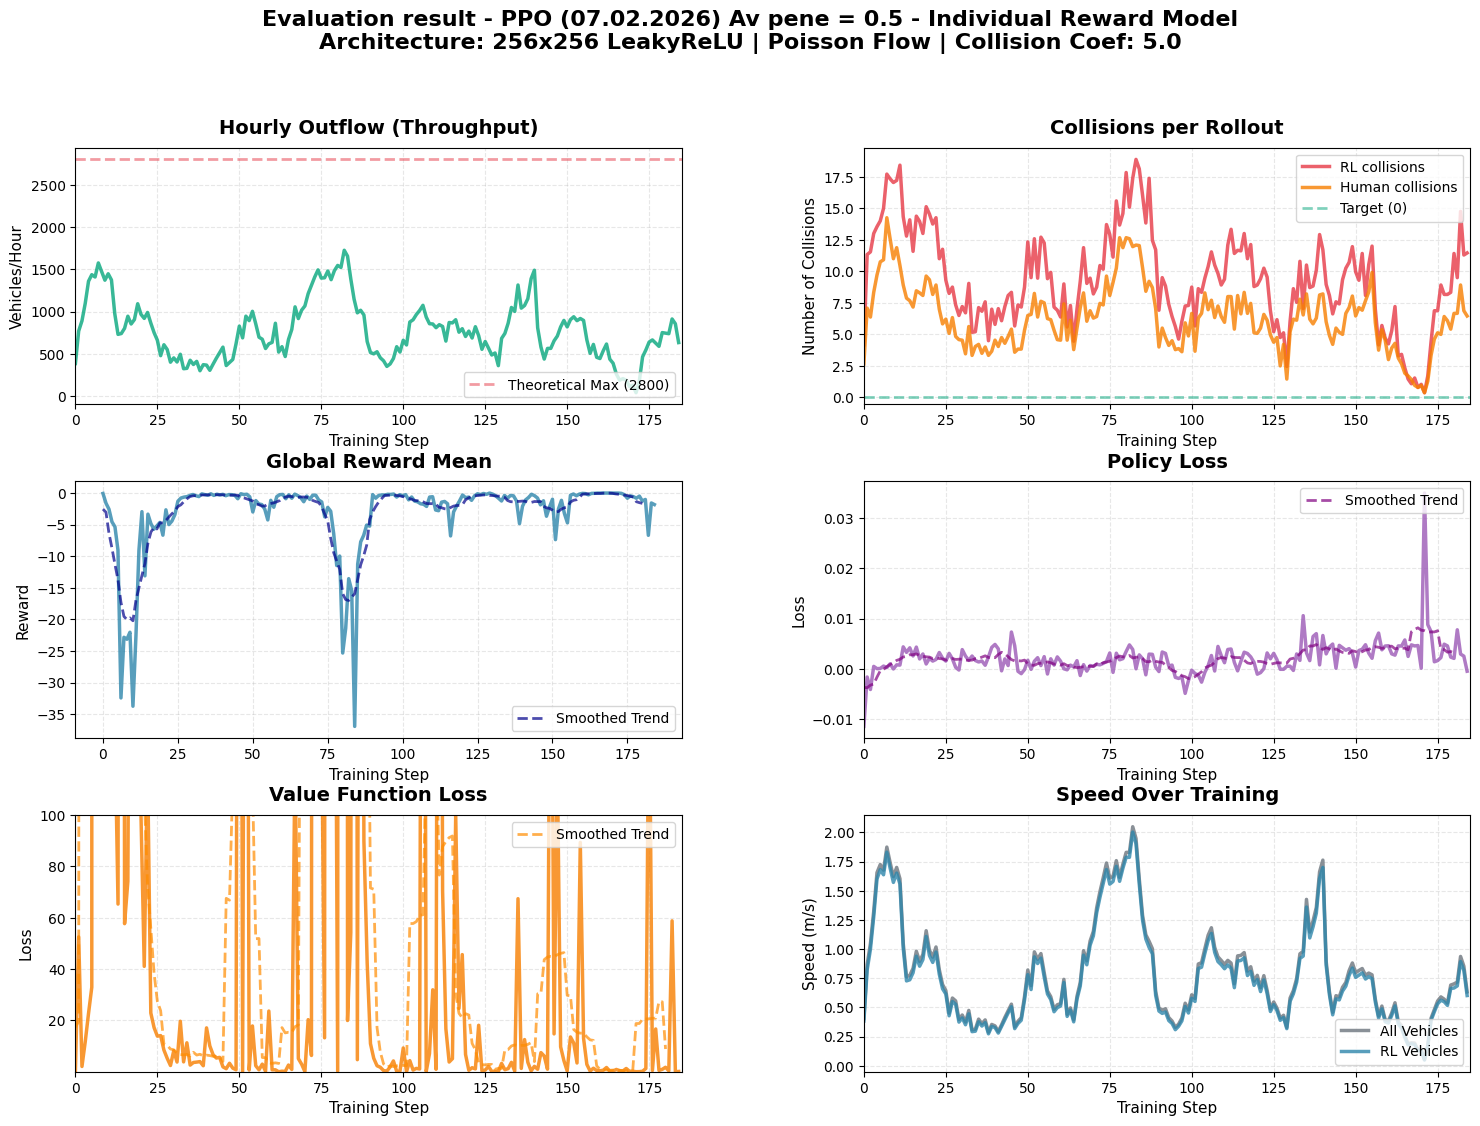


TRAINING SUMMARY - PPO (07.02.2026) AV pene = 0.5
Total Training Steps: 185

Final Metrics (Last 10 Steps Average):
--------------------------------------------------------------------------------
Hourly Outflow      :  725.367 veh/hr
Collisions          :   16.722 per rollout
Global Reward       :   -1.616 
Policy Loss         :    0.003 
Value Loss          :    8.864 
Speed (All)         :    0.692 m/s
Speed (RL)          :    0.661 m/s

Performance Indicators:
--------------------------------------------------------------------------------
Throughput Efficiency: 25.9% of theoretical max
Safety Score: NEEDS IMPROVEMENT (16.72 collisions)
Learning Stability: STABLE (policy loss std: 0.0023)


In [13]:
# Load results
df = pd.read_csv('results/fourway_1x1_penetration0.5_turn_adam_ppo_transformer_07.02/train_results.csv')

# Calculate hourly outflow
def calculate_hourly_outflow(df, horizon=2000, sim_step=0.5):
    """Convert outflow per rollout to vehicles per hour"""
    simulation_time_seconds = horizon * sim_step
    simulation_time_hours = simulation_time_seconds / 3600
    df['outflow_hourly'] = df['outflow'] / simulation_time_hours
    return df

df = calculate_hourly_outflow(df.copy())

# Create comprehensive subplot figure
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# Define color scheme
colors = {
    'primary': '#2E86AB',
    'danger': '#E63946',
    'success': '#06A77D',
    'warning': '#F77F00',
    'info': '#9B59B6',
    'secondary': '#6C757D'
}

# --- Subplot 1: Hourly Outflow ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(df['step'], df['outflow_hourly'], linewidth=2.5, color=colors['success'], alpha=0.8)
ax1.axhline(y=2800, color=colors['danger'], linestyle='--', linewidth=2, alpha=0.5, label='Theoretical Max (2800)')
# ax1.fill_between(df['step'], 0, df['outflow_hourly'], alpha=0.2, color=colors['success'])
ax1.set_title('Hourly Outflow (Throughput)', fontsize=14, fontweight='bold', pad=10)
ax1.set_xlabel('Training Step', fontsize=11)
ax1.set_ylabel('Vehicles/Hour', fontsize=11)
ax1.legend(loc='lower right', fontsize=10)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_xlim(df['step'].min(), df['step'].max())

# Add annotation for final value
final_outflow = df['outflow_hourly'].iloc[-1]
ax1.annotate(f'Final: {final_outflow:.1f}', 
            xy=(df['step'].iloc[-1], final_outflow),
            xytext=(10, 10), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            fontsize=10, fontweight='bold')

# --- Subplot 2: Collisions ---
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(df['step'], df['collisions'] - df['collisions_human'], label = 'RL collisions', linewidth=2.5, color=colors['danger'], alpha=0.8)
ax2.plot(df['step'], df['collisions_human'], label = 'Human collisions', linewidth=2.5, color=colors['warning'], alpha=0.8)
# ax2.fill_between(df['step'], 0, df['collisions'], alpha=0.2, color=colors['danger'])
ax2.axhline(y=0, color=colors['success'], linestyle='--', linewidth=2, alpha=0.5, label='Target (0)')
ax2.set_title('Collisions per Rollout', fontsize=14, fontweight='bold', pad=10)
ax2.set_xlabel('Training Step', fontsize=11)
ax2.set_ylabel('Number of Collisions', fontsize=11)
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_xlim(df['step'].min(), df['step'].max())

# Add annotation for final value
final_collisions = df['collisions'].iloc[-1]
ax2.annotate(f'Final: {final_collisions:.2f}', 
            xy=(df['step'].iloc[-1], final_collisions),
            xytext=(10, -10), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            fontsize=10, fontweight='bold')

# --- Subplot 3: Global Reward Mean ---
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(df['step'], df['global_reward_mean'], linewidth=2.5, color=colors['primary'], alpha=0.8)
# ax3.fill_between(df['step'], df['global_reward_mean'].min(), df['global_reward_mean'], 
#                  alpha=0.2, color=colors['primary'])
ax3.set_title('Global Reward Mean', fontsize=14, fontweight='bold', pad=10)
ax3.set_xlabel('Training Step', fontsize=11)
ax3.set_ylabel('Reward', fontsize=11)
ax3.grid(True, alpha=0.3, linestyle='--')
# ax3.set_xlim(df['step'].min(), df['step'].max())
#ax3.set_ylim(-4, 0.5)

# Add smoothed trend line
from scipy.ndimage import uniform_filter1d
window_size = max(5, len(df) // 20)
smoothed = uniform_filter1d(df['global_reward_mean'], size=window_size)
ax3.plot(df['step'], smoothed, linewidth=2, color='darkblue', linestyle='--', 
         alpha=0.7, label='Smoothed Trend')
ax3.legend(loc='lower right', fontsize=10)

# --- Subplot 4: Policy Loss ---
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(df['step'], df['policy_loss'], linewidth=2.5, color=colors['info'], alpha=0.8)
# ax4.fill_between(df['step'], 0, df['policy_loss'], alpha=0.2, color=colors['info'])
ax4.set_title('Policy Loss', fontsize=14, fontweight='bold', pad=10)
ax4.set_xlabel('Training Step', fontsize=11)
ax4.set_ylabel('Loss', fontsize=11)
ax4.grid(True, alpha=0.3, linestyle='--')
ax4.set_xlim(df['step'].min(), df['step'].max())

# Add smoothed trend line
smoothed_policy = uniform_filter1d(df['policy_loss'], size=window_size)
ax4.plot(df['step'], smoothed_policy, linewidth=2, color='purple', linestyle='--', 
         alpha=0.7, label='Smoothed Trend')
ax4.legend(loc='upper right', fontsize=10)

# --- Subplot 5: Value Function Loss ---
ax5 = fig.add_subplot(gs[2, 0])
ax5.plot(df['step'], df['value_loss'], linewidth=2.5, color=colors['warning'], alpha=0.8)
# ax5.fill_between(df['step'], 0, df['value_loss'], alpha=0.2, color=colors['warning'])
ax5.set_title('Value Function Loss', fontsize=14, fontweight='bold', pad=10)
ax5.set_xlabel('Training Step', fontsize=11)
ax5.set_ylabel('Loss', fontsize=11)
ax5.grid(True, alpha=0.3, linestyle='--')
ax5.set_xlim(df['step'].min(), df['step'].max())
ax5.set_ylim(df['value_loss'].min(), 100)

# Add smoothed trend line
smoothed_value = uniform_filter1d(df['value_loss'], size=window_size)
ax5.plot(df['step'], smoothed_value, linewidth=2, color='darkorange', linestyle='--', 
         alpha=0.7, label='Smoothed Trend')
ax5.legend(loc='upper right', fontsize=10)

# --- Subplot 6: Speed Over Training ---
ax6 = fig.add_subplot(gs[2, 1])
ax6.plot(df['step'], df['speed'], label='All Vehicles', linewidth=2.5, 
         color=colors['secondary'], alpha=0.8)
ax6.plot(df['step'], df['speed_rl'], label='RL Vehicles', linewidth=2.5, 
         color=colors['primary'], alpha=0.8)
# ax6.fill_between(df['step'], df['speed'], alpha=0.1, color=colors['secondary'])
# ax6.fill_between(df['step'], df['speed_rl'], alpha=0.1, color=colors['primary'])
ax6.set_title('Speed Over Training', fontsize=14, fontweight='bold', pad=10)
ax6.set_xlabel('Training Step', fontsize=11)
ax6.set_ylabel('Speed (m/s)', fontsize=11)
ax6.legend(loc='lower right', fontsize=10)
ax6.grid(True, alpha=0.3, linestyle='--')
ax6.set_xlim(df['step'].min(), df['step'].max())

# Add annotation for final speeds
final_speed_all = df['speed'].iloc[-1]
final_speed_rl = df['speed_rl'].iloc[-1]
ax6.annotate(f'All: {final_speed_all:.2f} m/s\nRL: {final_speed_rl:.2f} m/s', 
            xy=(df['step'].iloc[-1], final_speed_rl),
            xytext=(-80, 20), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            fontsize=9, fontweight='bold')

# Add main title
fig.suptitle('Evaluation result - PPO (07.02.2026) Av pene = 0.5 - Individual Reward Model\n' + 
             'Architecture: 256x256 LeakyReLU | Poisson Flow | Collision Coef: 5.0',
             fontsize=16, fontweight='bold', y=0.995)

plt.tight_layout()
plt.show()

# --- Print Summary Statistics ---
print("\n" + "="*80)
print("TRAINING SUMMARY - PPO (07.02.2026) AV pene = 0.5")
print("="*80)
print(f"Total Training Steps: {df['step'].max()}")
print(f"\nFinal Metrics (Last 10 Steps Average):")
print("-" * 80)

last_10 = df.tail(10)

metrics = {
    'Hourly Outflow': (last_10['outflow_hourly'].mean(), 'veh/hr'),
    'Collisions': (last_10['collisions'].mean(), 'per rollout'),
    'Global Reward': (last_10['global_reward_mean'].mean(), ''),
    'Policy Loss': (last_10['policy_loss'].mean(), ''),
    'Value Loss': (last_10['value_loss'].mean(), ''),
    'Speed (All)': (last_10['speed'].mean(), 'm/s'),
    'Speed (RL)': (last_10['speed_rl'].mean(), 'm/s'),
}

for metric, (value, unit) in metrics.items():
    print(f"{metric:20s}: {value:8.3f} {unit}")

print("\nPerformance Indicators:")
print("-" * 80)
efficiency = (last_10['outflow_hourly'].mean() / 2800) * 100
print(f"Throughput Efficiency: {efficiency:.1f}% of theoretical max")
print(f"Safety Score: {'EXCELLENT' if last_10['collisions'].mean() < 4.0 else 'NEEDS IMPROVEMENT'} ({last_10['collisions'].mean():.2f} collisions)")
print(f"Learning Stability: {'STABLE' if last_10['policy_loss'].std() < 0.01 else 'UNSTABLE'} (policy loss std: {last_10['policy_loss'].std():.4f})")
print("="*80)


# 11.02
Change architecture of Embeded: 128 
Forward : 256
3 layers 4 head

/tmp/ipykernel_7197/3085101233.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(loc='lower right', fontsize=10)
/tmp/ipykernel_7197/3085101233.py:151: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


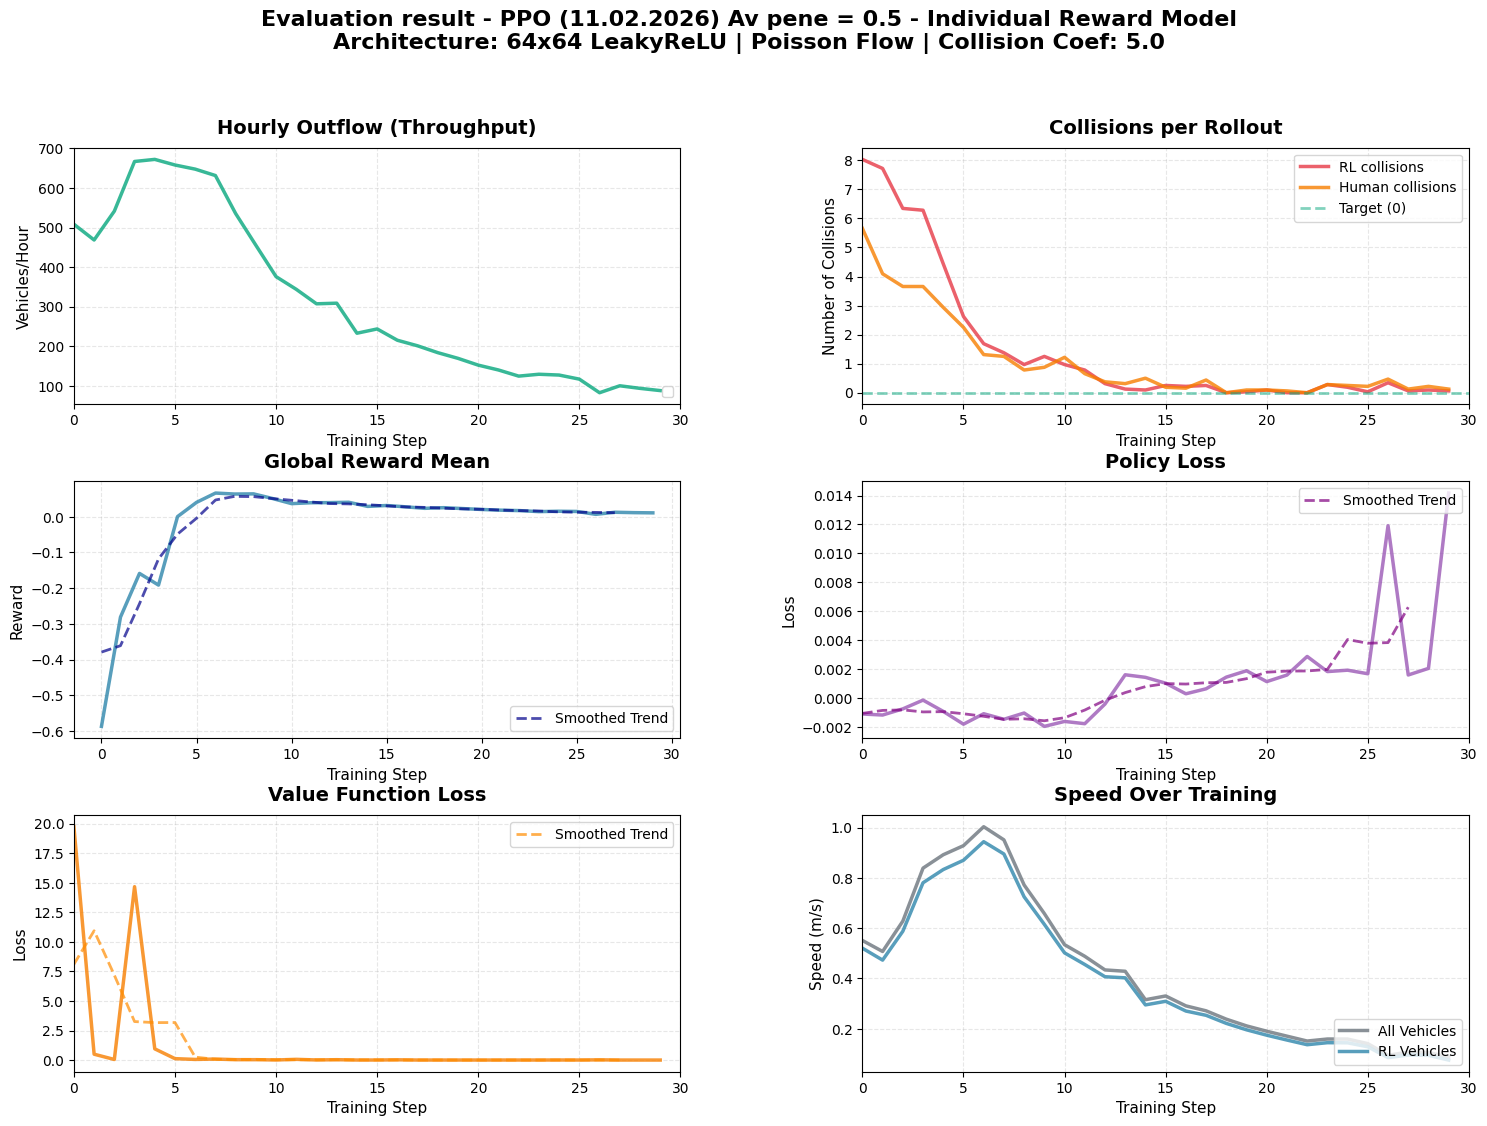


TRAINING SUMMARY - PPO (11.02.2026) AV pene = 0.5
Total Training Steps: 30

Final Metrics (Last 10 Steps Average):
--------------------------------------------------------------------------------
Hourly Outflow      :  111.137 veh/hr
Collisions          :    0.312 per rollout
Global Reward       :    0.014 
Policy Loss         :    0.004 
Value Loss          :    0.007 
Speed (All)         :    0.131 m/s
Speed (RL)          :    0.118 m/s

Performance Indicators:
--------------------------------------------------------------------------------
Throughput Efficiency: 4.0% of theoretical max
Safety Score: EXCELLENT (0.31 collisions)
Learning Stability: STABLE (policy loss std: 0.0050)


In [13]:
# Load results
df = pd.read_csv('results/fourway_1x1_penetration0.5_turn_adam_ppo_transformer_11.02/train_results.csv')

# Calculate hourly outflow
def calculate_hourly_outflow(df, horizon=2000, sim_step=0.5):
    """Convert outflow per rollout to vehicles per hour"""
    simulation_time_seconds = horizon * sim_step
    simulation_time_hours = simulation_time_seconds / 3600
    df['outflow_hourly'] = df['outflow'] / simulation_time_hours
    return df

df = calculate_hourly_outflow(df.copy())

# Create comprehensive subplot figure
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# Define color scheme
colors = {
    'primary': '#2E86AB',
    'danger': '#E63946',
    'success': '#06A77D',
    'warning': '#F77F00',
    'info': '#9B59B6',
    'secondary': '#6C757D'
}

# --- Subplot 1: Hourly Outflow ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(df['step'], df['outflow_hourly'], linewidth=2.5, color=colors['success'], alpha=0.8)
# ax1.axhline(y=2800, color=colors['danger'], linestyle='--', linewidth=2, alpha=0.5, label='Theoretical Max (2800)')
# ax1.fill_between(df['step'], 0, df['outflow_hourly'], alpha=0.2, color=colors['success'])
ax1.set_title('Hourly Outflow (Throughput)', fontsize=14, fontweight='bold', pad=10)
ax1.set_xlabel('Training Step', fontsize=11)
ax1.set_ylabel('Vehicles/Hour', fontsize=11)
ax1.legend(loc='lower right', fontsize=10)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_xlim(df['step'].min(), df['step'].max())

# Add annotation for final value
final_outflow = df['outflow_hourly'].iloc[-1]
ax1.annotate(f'Final: {final_outflow:.1f}', 
            xy=(df['step'].iloc[-1], final_outflow),
            xytext=(10, 10), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            fontsize=10, fontweight='bold')

# --- Subplot 2: Collisions ---
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(df['step'], df['collisions'] - df['collisions_human'], label = 'RL collisions', linewidth=2.5, color=colors['danger'], alpha=0.8)
ax2.plot(df['step'], df['collisions_human'], label = 'Human collisions', linewidth=2.5, color=colors['warning'], alpha=0.8)
# ax2.fill_between(df['step'], 0, df['collisions'], alpha=0.2, color=colors['danger'])
ax2.axhline(y=0, color=colors['success'], linestyle='--', linewidth=2, alpha=0.5, label='Target (0)')
ax2.set_title('Collisions per Rollout', fontsize=14, fontweight='bold', pad=10)
ax2.set_xlabel('Training Step', fontsize=11)
ax2.set_ylabel('Number of Collisions', fontsize=11)
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_xlim(df['step'].min(), df['step'].max())

# Add annotation for final value
final_collisions = df['collisions'].iloc[-1]
ax2.annotate(f'Final: {final_collisions:.2f}', 
            xy=(df['step'].iloc[-1], final_collisions),
            xytext=(10, -10), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            fontsize=10, fontweight='bold')

# --- Subplot 3: Global Reward Mean ---
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(df['step'], df['global_reward_mean'], linewidth=2.5, color=colors['primary'], alpha=0.8)
# ax3.fill_between(df['step'], df['global_reward_mean'].min(), df['global_reward_mean'], 
#                  alpha=0.2, color=colors['primary'])
ax3.set_title('Global Reward Mean', fontsize=14, fontweight='bold', pad=10)
ax3.set_xlabel('Training Step', fontsize=11)
ax3.set_ylabel('Reward', fontsize=11)
ax3.grid(True, alpha=0.3, linestyle='--')
# ax3.set_xlim(df['step'].min(), df['step'].max())
#ax3.set_ylim(-4, 0.5)

# Add smoothed trend line
from scipy.ndimage import uniform_filter1d
window_size = max(5, len(df) // 20)
smoothed = uniform_filter1d(df['global_reward_mean'], size=window_size)
ax3.plot(df['step'], smoothed, linewidth=2, color='darkblue', linestyle='--', 
         alpha=0.7, label='Smoothed Trend')
ax3.legend(loc='lower right', fontsize=10)

# --- Subplot 4: Policy Loss ---
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(df['step'], df['policy_loss'], linewidth=2.5, color=colors['info'], alpha=0.8)
# ax4.fill_between(df['step'], 0, df['policy_loss'], alpha=0.2, color=colors['info'])
ax4.set_title('Policy Loss', fontsize=14, fontweight='bold', pad=10)
ax4.set_xlabel('Training Step', fontsize=11)
ax4.set_ylabel('Loss', fontsize=11)
ax4.grid(True, alpha=0.3, linestyle='--')
ax4.set_xlim(df['step'].min(), df['step'].max())

# Add smoothed trend line
smoothed_policy = uniform_filter1d(df['policy_loss'], size=window_size)
ax4.plot(df['step'], smoothed_policy, linewidth=2, color='purple', linestyle='--', 
         alpha=0.7, label='Smoothed Trend')
ax4.legend(loc='upper right', fontsize=10)

# --- Subplot 5: Value Function Loss ---
ax5 = fig.add_subplot(gs[2, 0])
ax5.plot(df['step'], df['value_loss'], linewidth=2.5, color=colors['warning'], alpha=0.8)
# ax5.fill_between(df['step'], 0, df['value_loss'], alpha=0.2, color=colors['warning'])
ax5.set_title('Value Function Loss', fontsize=14, fontweight='bold', pad=10)
ax5.set_xlabel('Training Step', fontsize=11)
ax5.set_ylabel('Loss', fontsize=11)
ax5.grid(True, alpha=0.3, linestyle='--')
ax5.set_xlim(df['step'].min(), df['step'].max())
#ax5.set_ylim(df['value_loss'].min(), 100)

# Add smoothed trend line
smoothed_value = uniform_filter1d(df['value_loss'], size=window_size)
ax5.plot(df['step'], smoothed_value, linewidth=2, color='darkorange', linestyle='--', 
         alpha=0.7, label='Smoothed Trend')
ax5.legend(loc='upper right', fontsize=10)

# --- Subplot 6: Speed Over Training ---
ax6 = fig.add_subplot(gs[2, 1])
ax6.plot(df['step'], df['speed'], label='All Vehicles', linewidth=2.5, 
         color=colors['secondary'], alpha=0.8)
ax6.plot(df['step'], df['speed_rl'], label='RL Vehicles', linewidth=2.5, 
         color=colors['primary'], alpha=0.8)
# ax6.fill_between(df['step'], df['speed'], alpha=0.1, color=colors['secondary'])
# ax6.fill_between(df['step'], df['speed_rl'], alpha=0.1, color=colors['primary'])
ax6.set_title('Speed Over Training', fontsize=14, fontweight='bold', pad=10)
ax6.set_xlabel('Training Step', fontsize=11)
ax6.set_ylabel('Speed (m/s)', fontsize=11)
ax6.legend(loc='lower right', fontsize=10)
ax6.grid(True, alpha=0.3, linestyle='--')
ax6.set_xlim(df['step'].min(), df['step'].max())

# Add annotation for final speeds
final_speed_all = df['speed'].iloc[-1]
final_speed_rl = df['speed_rl'].iloc[-1]
ax6.annotate(f'All: {final_speed_all:.2f} m/s\nRL: {final_speed_rl:.2f} m/s', 
            xy=(df['step'].iloc[-1], final_speed_rl),
            xytext=(-80, 20), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            fontsize=9, fontweight='bold')

# Add main title
fig.suptitle('Evaluation result - PPO (11.02.2026) Av pene = 0.5 - Individual Reward Model\n' + 
             'Architecture: 64x64 LeakyReLU | Poisson Flow | Collision Coef: 5.0',
             fontsize=16, fontweight='bold', y=0.995)

plt.tight_layout()
plt.show()

# --- Print Summary Statistics ---
print("\n" + "="*80)
print("TRAINING SUMMARY - PPO (11.02.2026) AV pene = 0.5")
print("="*80)
print(f"Total Training Steps: {df['step'].max()}")
print(f"\nFinal Metrics (Last 10 Steps Average):")
print("-" * 80)

last_10 = df.tail(10)

metrics = {
    'Hourly Outflow': (last_10['outflow_hourly'].mean(), 'veh/hr'),
    'Collisions': (last_10['collisions'].mean(), 'per rollout'),
    'Global Reward': (last_10['global_reward_mean'].mean(), ''),
    'Policy Loss': (last_10['policy_loss'].mean(), ''),
    'Value Loss': (last_10['value_loss'].mean(), ''),
    'Speed (All)': (last_10['speed'].mean(), 'm/s'),
    'Speed (RL)': (last_10['speed_rl'].mean(), 'm/s'),
}

for metric, (value, unit) in metrics.items():
    print(f"{metric:20s}: {value:8.3f} {unit}")

print("\nPerformance Indicators:")
print("-" * 80)
efficiency = (last_10['outflow_hourly'].mean() / 2800) * 100
print(f"Throughput Efficiency: {efficiency:.1f}% of theoretical max")
print(f"Safety Score: {'EXCELLENT' if last_10['collisions'].mean() < 4.0 else 'NEEDS IMPROVEMENT'} ({last_10['collisions'].mean():.2f} collisions)")
print(f"Learning Stability: {'STABLE' if last_10['policy_loss'].std() < 0.01 else 'UNSTABLE'} (policy loss std: {last_10['policy_loss'].std():.4f})")
print("="*80)


# 12.02
Update the transformer logic 
klarg = 0.02 #atari, control task use this 
klcoef = 0.2 
n_gds = 10 # Open AI standard

/tmp/ipykernel_1082/1415971158.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(loc='lower right', fontsize=10)
/tmp/ipykernel_1082/1415971158.py:151: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


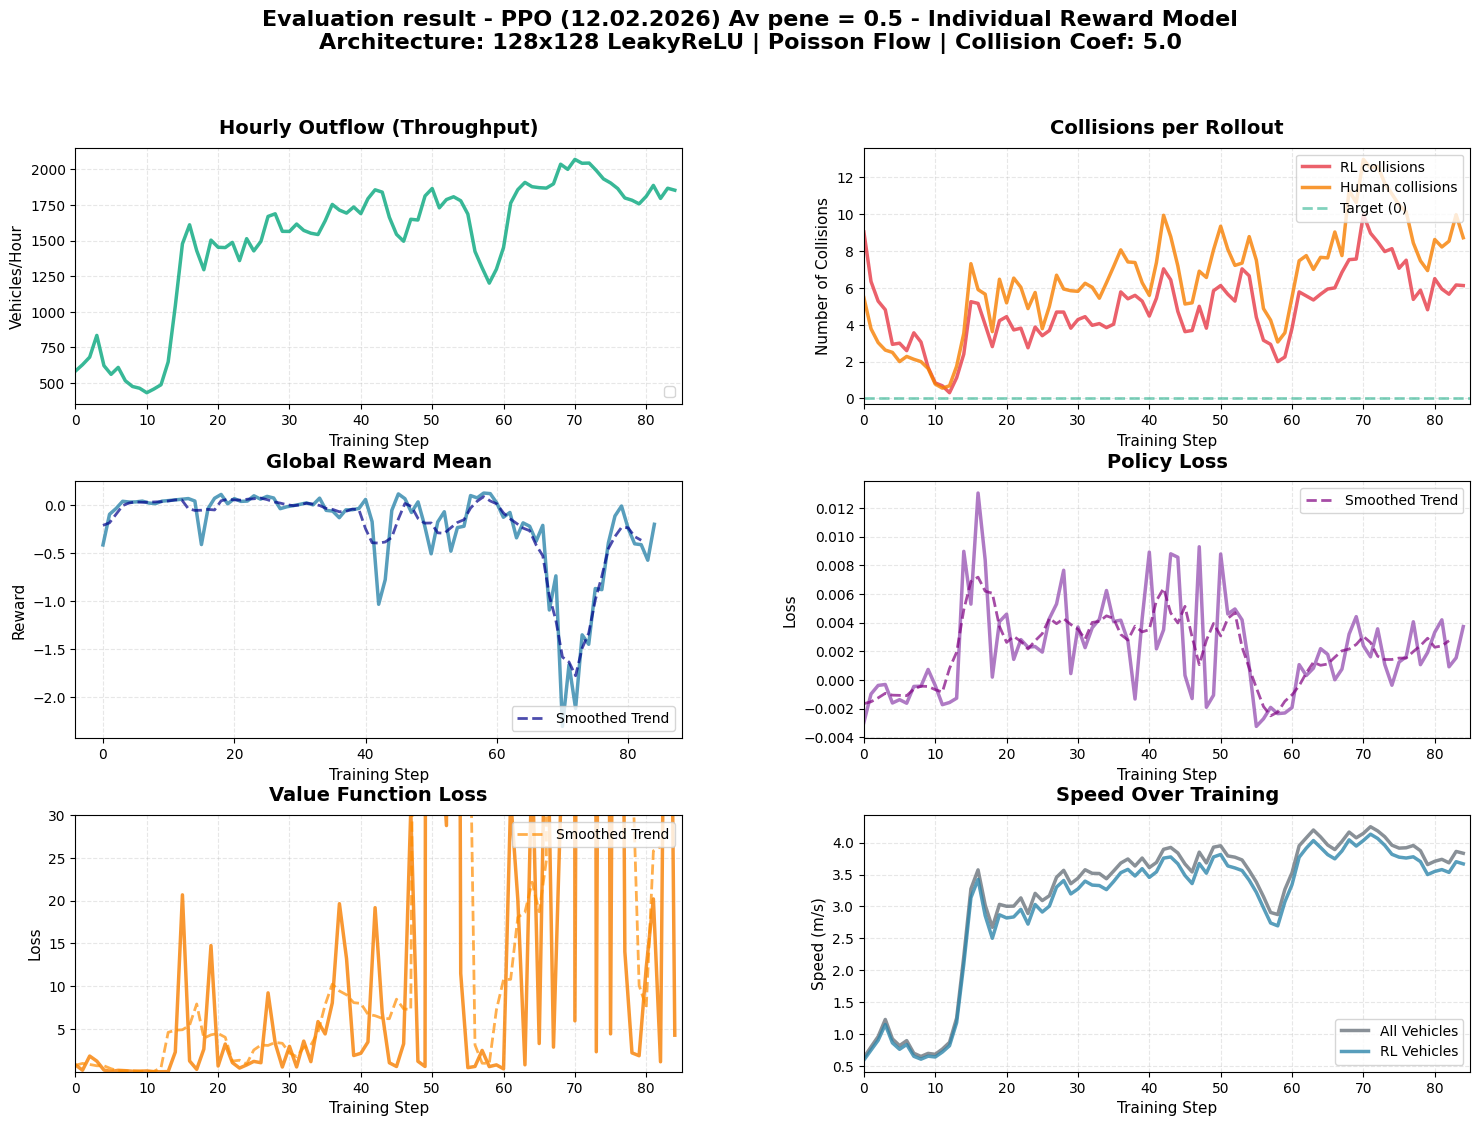


TRAINING SUMMARY - PPO (12.02.2026) AV pene = 0.5
Total Training Steps: 85

Final Metrics (Last 10 Steps Average):
--------------------------------------------------------------------------------
Hourly Outflow      : 1824.112 veh/hr
Collisions          :   14.552 per rollout
Global Reward       :   -0.357 
Policy Loss         :    0.002 
Value Loss          :   34.063 
Speed (All)         :    3.803 m/s
Speed (RL)          :    3.641 m/s

Performance Indicators:
--------------------------------------------------------------------------------
Throughput Efficiency: 65.1% of theoretical max
Safety Score: NEEDS IMPROVEMENT (14.55 collisions)
Learning Stability: STABLE (policy loss std: 0.0013)


In [6]:
# Load results
df = pd.read_csv('results/fourway_1x1_penetration0.5_turn_adam_ppo_transformer_12.02/train_results.csv')

# Calculate hourly outflow
def calculate_hourly_outflow(df, horizon=2000, sim_step=0.5):
    """Convert outflow per rollout to vehicles per hour"""
    simulation_time_seconds = horizon * sim_step
    simulation_time_hours = simulation_time_seconds / 3600
    df['outflow_hourly'] = df['outflow'] / simulation_time_hours
    return df

df = calculate_hourly_outflow(df.copy())

# Create comprehensive subplot figure
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# Define color scheme
colors = {
    'primary': '#2E86AB',
    'danger': '#E63946',
    'success': '#06A77D',
    'warning': '#F77F00',
    'info': '#9B59B6',
    'secondary': '#6C757D'
}

# --- Subplot 1: Hourly Outflow ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(df['step'], df['outflow_hourly'], linewidth=2.5, color=colors['success'], alpha=0.8)
# ax1.axhline(y=2800, color=colors['danger'], linestyle='--', linewidth=2, alpha=0.5, label='Theoretical Max (2800)')
# ax1.fill_between(df['step'], 0, df['outflow_hourly'], alpha=0.2, color=colors['success'])
ax1.set_title('Hourly Outflow (Throughput)', fontsize=14, fontweight='bold', pad=10)
ax1.set_xlabel('Training Step', fontsize=11)
ax1.set_ylabel('Vehicles/Hour', fontsize=11)
ax1.legend(loc='lower right', fontsize=10)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_xlim(df['step'].min(), df['step'].max())

# Add annotation for final value
final_outflow = df['outflow_hourly'].iloc[-1]
ax1.annotate(f'Final: {final_outflow:.1f}', 
            xy=(df['step'].iloc[-1], final_outflow),
            xytext=(10, 10), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            fontsize=10, fontweight='bold')

# --- Subplot 2: Collisions ---
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(df['step'], df['collisions'] - df['collisions_human'], label = 'RL collisions', linewidth=2.5, color=colors['danger'], alpha=0.8)
ax2.plot(df['step'], df['collisions_human'], label = 'Human collisions', linewidth=2.5, color=colors['warning'], alpha=0.8)
# ax2.fill_between(df['step'], 0, df['collisions'], alpha=0.2, color=colors['danger'])
ax2.axhline(y=0, color=colors['success'], linestyle='--', linewidth=2, alpha=0.5, label='Target (0)')
ax2.set_title('Collisions per Rollout', fontsize=14, fontweight='bold', pad=10)
ax2.set_xlabel('Training Step', fontsize=11)
ax2.set_ylabel('Number of Collisions', fontsize=11)
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_xlim(df['step'].min(), df['step'].max())

# Add annotation for final value
final_collisions = df['collisions'].iloc[-1]
ax2.annotate(f'Final: {final_collisions:.2f}', 
            xy=(df['step'].iloc[-1], final_collisions),
            xytext=(10, -10), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            fontsize=10, fontweight='bold')

# --- Subplot 3: Global Reward Mean ---
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(df['step'], df['global_reward_mean'], linewidth=2.5, color=colors['primary'], alpha=0.8)
# ax3.fill_between(df['step'], df['global_reward_mean'].min(), df['global_reward_mean'], 
#                  alpha=0.2, color=colors['primary'])
ax3.set_title('Global Reward Mean', fontsize=14, fontweight='bold', pad=10)
ax3.set_xlabel('Training Step', fontsize=11)
ax3.set_ylabel('Reward', fontsize=11)
ax3.grid(True, alpha=0.3, linestyle='--')
# ax3.set_xlim(df['step'].min(), df['step'].max())
#ax3.set_ylim(-4, 0.5)

# Add smoothed trend line
from scipy.ndimage import uniform_filter1d
window_size = max(5, len(df) // 20)
smoothed = uniform_filter1d(df['global_reward_mean'], size=window_size)
ax3.plot(df['step'], smoothed, linewidth=2, color='darkblue', linestyle='--', 
         alpha=0.7, label='Smoothed Trend')
ax3.legend(loc='lower right', fontsize=10)

# --- Subplot 4: Policy Loss ---
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(df['step'], df['policy_loss'], linewidth=2.5, color=colors['info'], alpha=0.8)
# ax4.fill_between(df['step'], 0, df['policy_loss'], alpha=0.2, color=colors['info'])
ax4.set_title('Policy Loss', fontsize=14, fontweight='bold', pad=10)
ax4.set_xlabel('Training Step', fontsize=11)
ax4.set_ylabel('Loss', fontsize=11)
ax4.grid(True, alpha=0.3, linestyle='--')
ax4.set_xlim(df['step'].min(), df['step'].max())

# Add smoothed trend line
smoothed_policy = uniform_filter1d(df['policy_loss'], size=window_size)
ax4.plot(df['step'], smoothed_policy, linewidth=2, color='purple', linestyle='--', 
         alpha=0.7, label='Smoothed Trend')
ax4.legend(loc='upper right', fontsize=10)

# --- Subplot 5: Value Function Loss ---
ax5 = fig.add_subplot(gs[2, 0])
ax5.plot(df['step'], df['value_loss'], linewidth=2.5, color=colors['warning'], alpha=0.8)
# ax5.fill_between(df['step'], 0, df['value_loss'], alpha=0.2, color=colors['warning'])
ax5.set_title('Value Function Loss', fontsize=14, fontweight='bold', pad=10)
ax5.set_xlabel('Training Step', fontsize=11)
ax5.set_ylabel('Loss', fontsize=11)
ax5.grid(True, alpha=0.3, linestyle='--')
ax5.set_xlim(df['step'].min(), df['step'].max())
ax5.set_ylim(df['value_loss'].min(), 30)

# Add smoothed trend line
smoothed_value = uniform_filter1d(df['value_loss'], size=window_size)
ax5.plot(df['step'], smoothed_value, linewidth=2, color='darkorange', linestyle='--', 
         alpha=0.7, label='Smoothed Trend')
ax5.legend(loc='upper right', fontsize=10)

# --- Subplot 6: Speed Over Training ---
ax6 = fig.add_subplot(gs[2, 1])
ax6.plot(df['step'], df['speed'], label='All Vehicles', linewidth=2.5, 
         color=colors['secondary'], alpha=0.8)
ax6.plot(df['step'], df['speed_rl'], label='RL Vehicles', linewidth=2.5, 
         color=colors['primary'], alpha=0.8)
# ax6.fill_between(df['step'], df['speed'], alpha=0.1, color=colors['secondary'])
# ax6.fill_between(df['step'], df['speed_rl'], alpha=0.1, color=colors['primary'])
ax6.set_title('Speed Over Training', fontsize=14, fontweight='bold', pad=10)
ax6.set_xlabel('Training Step', fontsize=11)
ax6.set_ylabel('Speed (m/s)', fontsize=11)
ax6.legend(loc='lower right', fontsize=10)
ax6.grid(True, alpha=0.3, linestyle='--')
ax6.set_xlim(df['step'].min(), df['step'].max())

# Add annotation for final speeds
final_speed_all = df['speed'].iloc[-1]
final_speed_rl = df['speed_rl'].iloc[-1]
ax6.annotate(f'All: {final_speed_all:.2f} m/s\nRL: {final_speed_rl:.2f} m/s', 
            xy=(df['step'].iloc[-1], final_speed_rl),
            xytext=(-80, 20), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            fontsize=9, fontweight='bold')

# Add main title
fig.suptitle('Evaluation result - PPO (12.02.2026) Av pene = 0.5 - Individual Reward Model\n' + 
             'Architecture: 128x128 LeakyReLU | Poisson Flow | Collision Coef: 5.0',
             fontsize=16, fontweight='bold', y=0.995)

plt.tight_layout()
plt.show()

# --- Print Summary Statistics ---
print("\n" + "="*80)
print("TRAINING SUMMARY - PPO (12.02.2026) AV pene = 0.5")
print("="*80)
print(f"Total Training Steps: {df['step'].max()}")
print(f"\nFinal Metrics (Last 10 Steps Average):")
print("-" * 80)

last_10 = df.tail(10)

metrics = {
    'Hourly Outflow': (last_10['outflow_hourly'].mean(), 'veh/hr'),
    'Collisions': (last_10['collisions'].mean(), 'per rollout'),
    'Global Reward': (last_10['global_reward_mean'].mean(), ''),
    'Policy Loss': (last_10['policy_loss'].mean(), ''),
    'Value Loss': (last_10['value_loss'].mean(), ''),
    'Speed (All)': (last_10['speed'].mean(), 'm/s'),
    'Speed (RL)': (last_10['speed_rl'].mean(), 'm/s'),
}

for metric, (value, unit) in metrics.items():
    print(f"{metric:20s}: {value:8.3f} {unit}")

print("\nPerformance Indicators:")
print("-" * 80)
efficiency = (last_10['outflow_hourly'].mean() / 2800) * 100
print(f"Throughput Efficiency: {efficiency:.1f}% of theoretical max")
print(f"Safety Score: {'EXCELLENT' if last_10['collisions'].mean() < 4.0 else 'NEEDS IMPROVEMENT'} ({last_10['collisions'].mean():.2f} collisions)")
print(f"Learning Stability: {'STABLE' if last_10['policy_loss'].std() < 0.01 else 'UNSTABLE'} (policy loss std: {last_10['policy_loss'].std():.4f})")
print("="*80)



# 13.02
Obs space revamp
still 7 feature but ... difference?
Now, not using Platoon any more. But the idea is KNN element, with 11 element, including ego vehicle
Try to train with the same net of Transformer, hope it works


In [ ]:
# Load results
df = pd.read_csv('results/fourway_1x1_penetration0.5_turn_adam_ppo_transformer_13.02/train_results.csv')

# Calculate hourly outflow
def calculate_hourly_outflow(df, horizon=2000, sim_step=0.5):
    """Convert outflow per rollout to vehicles per hour"""
    simulation_time_seconds = horizon * sim_step
    simulation_time_hours = simulation_time_seconds / 3600
    df['outflow_hourly'] = df['outflow'] / simulation_time_hours
    return df

df = calculate_hourly_outflow(df.copy())

# Create comprehensive subplot figure
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# Define color scheme
colors = {
    'primary': '#2E86AB',
    'danger': '#E63946',
    'success': '#06A77D',
    'warning': '#F77F00',
    'info': '#9B59B6',
    'secondary': '#6C757D'
}

# --- Subplot 1: Hourly Outflow ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(df['step'], df['outflow_hourly'], linewidth=2.5, color=colors['success'], alpha=0.8)
# ax1.axhline(y=2800, color=colors['danger'], linestyle='--', linewidth=2, alpha=0.5, label='Theoretical Max (2800)')
# ax1.fill_between(df['step'], 0, df['outflow_hourly'], alpha=0.2, color=colors['success'])
ax1.set_title('Hourly Outflow (Throughput)', fontsize=14, fontweight='bold', pad=10)
ax1.set_xlabel('Training Step', fontsize=11)
ax1.set_ylabel('Vehicles/Hour', fontsize=11)
ax1.legend(loc='lower right', fontsize=10)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_xlim(df['step'].min(), df['step'].max())

# Add annotation for final value
final_outflow = df['outflow_hourly'].iloc[-1]
ax1.annotate(f'Final: {final_outflow:.1f}', 
            xy=(df['step'].iloc[-1], final_outflow),
            xytext=(10, 10), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            fontsize=10, fontweight='bold')

# --- Subplot 2: Collisions ---
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(df['step'], df['collisions'] - df['collisions_human'], label = 'RL collisions', linewidth=2.5, color=colors['danger'], alpha=0.8)
ax2.plot(df['step'], df['collisions_human'], label = 'Human collisions', linewidth=2.5, color=colors['warning'], alpha=0.8)
# ax2.fill_between(df['step'], 0, df['collisions'], alpha=0.2, color=colors['danger'])
ax2.axhline(y=0, color=colors['success'], linestyle='--', linewidth=2, alpha=0.5, label='Target (0)')
ax2.set_title('Collisions per Rollout', fontsize=14, fontweight='bold', pad=10)
ax2.set_xlabel('Training Step', fontsize=11)
ax2.set_ylabel('Number of Collisions', fontsize=11)
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_xlim(df['step'].min(), df['step'].max())

# Add annotation for final value
final_collisions = df['collisions'].iloc[-1]
ax2.annotate(f'Final: {final_collisions:.2f}', 
            xy=(df['step'].iloc[-1], final_collisions),
            xytext=(10, -10), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            fontsize=10, fontweight='bold')

# --- Subplot 3: Global Reward Mean ---
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(df['step'], df['global_reward_mean'], linewidth=2.5, color=colors['primary'], alpha=0.8)
# ax3.fill_between(df['step'], df['global_reward_mean'].min(), df['global_reward_mean'], 
#                  alpha=0.2, color=colors['primary'])
ax3.set_title('Global Reward Mean', fontsize=14, fontweight='bold', pad=10)
ax3.set_xlabel('Training Step', fontsize=11)
ax3.set_ylabel('Reward', fontsize=11)
ax3.grid(True, alpha=0.3, linestyle='--')
# ax3.set_xlim(df['step'].min(), df['step'].max())
#ax3.set_ylim(-4, 0.5)

# Add smoothed trend line
from scipy.ndimage import uniform_filter1d
window_size = max(5, len(df) // 20)
smoothed = uniform_filter1d(df['global_reward_mean'], size=window_size)
ax3.plot(df['step'], smoothed, linewidth=2, color='darkblue', linestyle='--', 
         alpha=0.7, label='Smoothed Trend')
ax3.legend(loc='lower right', fontsize=10)

# --- Subplot 4: Policy Loss ---
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(df['step'], df['policy_loss'], linewidth=2.5, color=colors['info'], alpha=0.8)
# ax4.fill_between(df['step'], 0, df['policy_loss'], alpha=0.2, color=colors['info'])
ax4.set_title('Policy Loss', fontsize=14, fontweight='bold', pad=10)
ax4.set_xlabel('Training Step', fontsize=11)
ax4.set_ylabel('Loss', fontsize=11)
ax4.grid(True, alpha=0.3, linestyle='--')
ax4.set_xlim(df['step'].min(), df['step'].max())

# Add smoothed trend line
smoothed_policy = uniform_filter1d(df['policy_loss'], size=window_size)
ax4.plot(df['step'], smoothed_policy, linewidth=2, color='purple', linestyle='--', 
         alpha=0.7, label='Smoothed Trend')
ax4.legend(loc='upper right', fontsize=10)

# --- Subplot 5: Value Function Loss ---
ax5 = fig.add_subplot(gs[2, 0])
ax5.plot(df['step'], df['value_loss'], linewidth=2.5, color=colors['warning'], alpha=0.8)
# ax5.fill_between(df['step'], 0, df['value_loss'], alpha=0.2, color=colors['warning'])
ax5.set_title('Value Function Loss', fontsize=14, fontweight='bold', pad=10)
ax5.set_xlabel('Training Step', fontsize=11)
ax5.set_ylabel('Loss', fontsize=11)
ax5.grid(True, alpha=0.3, linestyle='--')
ax5.set_xlim(df['step'].min(), df['step'].max())
ax5.set_ylim(df['value_loss'].min(), 30)

# Add smoothed trend line
smoothed_value = uniform_filter1d(df['value_loss'], size=window_size)
ax5.plot(df['step'], smoothed_value, linewidth=2, color='darkorange', linestyle='--', 
         alpha=0.7, label='Smoothed Trend')
ax5.legend(loc='upper right', fontsize=10)

# --- Subplot 6: Speed Over Training ---
ax6 = fig.add_subplot(gs[2, 1])
ax6.plot(df['step'], df['speed'], label='All Vehicles', linewidth=2.5, 
         color=colors['secondary'], alpha=0.8)
ax6.plot(df['step'], df['speed_rl'], label='RL Vehicles', linewidth=2.5, 
         color=colors['primary'], alpha=0.8)
# ax6.fill_between(df['step'], df['speed'], alpha=0.1, color=colors['secondary'])
# ax6.fill_between(df['step'], df['speed_rl'], alpha=0.1, color=colors['primary'])
ax6.set_title('Speed Over Training', fontsize=14, fontweight='bold', pad=10)
ax6.set_xlabel('Training Step', fontsize=11)
ax6.set_ylabel('Speed (m/s)', fontsize=11)
ax6.legend(loc='lower right', fontsize=10)
ax6.grid(True, alpha=0.3, linestyle='--')
ax6.set_xlim(df['step'].min(), df['step'].max())

# Add annotation for final speeds
final_speed_all = df['speed'].iloc[-1]
final_speed_rl = df['speed_rl'].iloc[-1]
ax6.annotate(f'All: {final_speed_all:.2f} m/s\nRL: {final_speed_rl:.2f} m/s', 
            xy=(df['step'].iloc[-1], final_speed_rl),
            xytext=(-80, 20), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            fontsize=9, fontweight='bold')

# Add main title
fig.suptitle('Evaluation result - PPO (13.02.2026) Av pene = 0.5 - Individual Reward Model\n' + 
             'Architecture: 128x128 LeakyReLU | Poisson Flow | Collision Coef: 5.0, New Observation Space',
             fontsize=16, fontweight='bold', y=0.995)

plt.tight_layout()
plt.show()

# --- Print Summary Statistics ---
print("\n" + "="*80)
print("TRAINING SUMMARY - PPO (13.02.2026) AV pene = 0.5")
print("="*80)
print(f"Total Training Steps: {df['step'].max()}")
print(f"\nFinal Metrics (Last 10 Steps Average):")
print("-" * 80)

last_10 = df.tail(10)

metrics = {
    'Hourly Outflow': (last_10['outflow_hourly'].mean(), 'veh/hr'),
    'Collisions': (last_10['collisions'].mean(), 'per rollout'),
    'Global Reward': (last_10['global_reward_mean'].mean(), ''),
    'Policy Loss': (last_10['policy_loss'].mean(), ''),
    'Value Loss': (last_10['value_loss'].mean(), ''),
    'Speed (All)': (last_10['speed'].mean(), 'm/s'),
    'Speed (RL)': (last_10['speed_rl'].mean(), 'm/s'),
}

for metric, (value, unit) in metrics.items():
    print(f"{metric:20s}: {value:8.3f} {unit}")

print("\nPerformance Indicators:")
print("-" * 80)
efficiency = (last_10['outflow_hourly'].mean() / 2800) * 100
print(f"Throughput Efficiency: {efficiency:.1f}% of theoretical max")
print(f"Safety Score: {'EXCELLENT' if last_10['collisions'].mean() < 4.0 else 'NEEDS IMPROVEMENT'} ({last_10['collisions'].mean():.2f} collisions)")
print(f"Learning Stability: {'STABLE' if last_10['policy_loss'].std() < 0.01 else 'UNSTABLE'} (policy loss std: {last_10['policy_loss'].std():.4f})")
print("="*80)

